# Seed refinement, three ways -- `gray_bbox` / `hem_bbox` / a hybrid gray-gated, hem-anchored prototype

Brainstorm/debug notebook, **not a production candidate**. Extends
`production_seed_tightening_detail_14roi.ipynb`'s two-row comparison (`gray_inverted` vs
`hematoxylin_od`, both run through `tighten_box_otsu` unmodified) with a third row: a hybrid
method sketched out in conversation, prototyped here only. Runs on that notebook's 14 joint-valid
clicks **plus** the annotations `tightening_process_hem_vs_gray.ipynb` shows (24 unique clicks
total after removing 4 that overlap between the two sets) -- see Step 1b.

**This is the fifth revision of the hybrid method.** Revisions 1-2 used `connectivity=2`
(8-connected) Otsu labeling and dilation for click tolerance; revision 3 switched to
`connectivity=1` (see the connectivity note below) after finding that `connectivity=2` was
silently merging touching-but-distinct structures; revision 4 replaced hem's plain Otsu cut with a
dynamic one and widened both channels' fallback radius to 3um. **This revision (5) applies that
same dynamic cut to the gray channel too** -- gray had been deliberately left on plain Otsu through
revision 4 as untested territory; it no longer is.

**The hybrid idea now, as steps (none of this exists in `seed_selection.py` yet):**
1. Threshold `gray_inverted` with a **dynamic cut**: the ordinary Otsu cut over the whole window,
   plus `DYNAMIC_K` (0.5) times the standard deviation of the pixels already above that Otsu cut --
   same formula as the hem step below, now shared by both channels. Labeled with
   **`connectivity=1`** (4-connected -- two foreground pixels that only touch at a corner are no
   longer the same component; see the connectivity note below). **Base:** if the click lands on
   gray foreground, take that one component directly. **Fallback:** if the click lands on gray
   background, take the union of every gray component within `CLICK_RADIUS_UM` (3.0um, converted
   to pixels via this ROI's own microns-per-pixel) of the click.
2. **Dilate only the selected gray region**, in isolation -- every other gray pixel is zeroed out
   first, so the dilation can never bridge a gap into an unrelated neighbouring component (kept
   from revision 2 onward).
3. Threshold `hematoxylin_od` with the same dynamic cut (Otsu + `DYNAMIC_K` * std of the
   Otsu-foreground pixels), labeled with `connectivity=1`. **Base:** if the click lands on hem
   foreground *and* that one component alone would already tighten to `HEM_MIN_BASE_SIZE_PX`
   (20px) or more, take just that component -- included only if it's **completely** inside the
   dilated gray mask from step 2. **Fallback**, triggered by *either* of two conditions -- the
   click lands on hem background, **or** the click's own hem component tightens to less than 20px
   alone -- take the union of every hem component within the same `CLICK_RADIUS_UM`=3.0um of the
   click, each again included only if completely inside the gray mask. The final bbox is the union
   of whichever components get included.

**`CLICK_RADIUS_UM`=3.0um is shared by both channels' fallback searches**, and now `DYNAMIC_K`=0.5
is too (no 4um radius anywhere, as decided several revisions ago).

**Checked directly against the rendered panels, not assumed:** on `300.tiff`/14581 and
`245.tiff`/6243 -- the two cases the last two revisions were built around -- making gray dynamic
too shrank gray's own selected region substantially (-38% and -14% respectively) but left the
final hybrid box **unchanged** in both (29px, 31px): the smaller gray mask still fully contained
the same hem components either way, so containment was never the binding constraint on these two
specific clicks. Whether it changes anything on the other 22 is what the full run below is for.

**Revision notes:**
- *Dilation order (fixed four passes ago):* an earlier pass dilated the *entire* `gray_inverted`
  Otsu binary before labeling, then picked the click-tolerant component from the dilated result.
  That lets two components that are merely close (within one dilation pass of each other) fuse
  into a single, much bigger accepted region -- confirmed on this same run: `402.tiff`'s accepted
  gray component grew 565px -> 1261px (+123%) from *one* 3x3 dilation pass, far more than that
  component's own perimeter could produce alone. Fixed by selecting first (on the undilated
  labels) and dilating only the selected region's isolated mask afterward -- kept ever since.
- *Hem inclusion (revision 2):* replaced a soft "drop tiny components, keep anything >=50%
  overlapping" rule with a click-anchored base-case/fallback rule, using a 4um fallback radius
  only when the click missed hem foreground entirely.
- *Hem inclusion (revision 3):* the fallback trigger broadened to *also* fire when the click's own
  hem component is too small to stand alone (<20px), the fallback radius shrank to 2um and became
  shared with the gray step, and the gray step itself gained the same base-case/fallback structure
  instead of always searching a fixed-pixel radius regardless of whether the click hit foreground.
  Also switched both channels from `connectivity=2` to `connectivity=1`.
- *Hem thresholding (revision 4) -- why not a fixed bump:* tried three approaches on
  `245.tiff`/6243 outside this notebook before landing here. A flat "+20" bump split the bean from
  its neighbour cleanly. A *component-level* darkness-composition filter (keep components
  containing top-25%-darkest pixels) could not split anything -- it can only drop whole
  components, and the merged blob trivially contains dark pixels (the bean itself) so it survived
  intact. Two-stage/recursive Otsu (rerun Otsu on just the accepted component's own pixels) did
  split it, but over-aggressively -- it trims real bean tissue, not just the neck to the
  neighbour. `Otsu + 0.5*std(foreground)` landed almost exactly where the manual "+20" did (120px
  vs 117px) while being derived from the window's own data, not a hardcoded intensity value --
  adopted for hem. Also widened both channels' fallback radius from 2um to 3um.
- *Gray thresholding (this revision):* the same dynamic formula, now applied to gray too, on the
  hypothesis that a more selective gray channel might help more broadly than it did on the two
  cases checked directly (see above, both unchanged).
- *Connectivity vs. dilation -- still not the same operation.* `skimage.measure.label`'s
  `connectivity` parameter (1 = 4-connected, "edge neighbours only"; 2 = 8-connected, "edges +
  corners") only decides whether two *already-foreground* pixels that touch diagonally get merged
  into one component or stay two -- it never adds margin around a boundary the way dilation does,
  and it never rescues a click sitting just outside a component the way a search radius does. What
  `connectivity=1` *does* do is stop two structures that only touch at a single diagonal pixel
  from being silently treated as one. Dilation (step 2, gray only) and the `CLICK_RADIUS_UM`
  searches (both channels' fallback) still do the margin/tolerance work; `connectivity=1` does a
  different job, splitting rather than merging.

**Every hybrid threshold below is a first guess, not a tuned value** --
`DILATE_KERNEL`/`DILATE_ITERATIONS`, `CLICK_RADIUS_UM`, `HEM_MIN_BASE_SIZE_PX`, `DYNAMIC_K`. The
point of this notebook is to look at what this produces on real clicks, not to defend these
numbers.

**Reused unchanged from `production_seed_tightening_detail_14roi.ipynb`:** `explore_tightening` /
`plot_channel_row` (the `gray_bbox`/`hem_bbox` rows) -- still `connectivity=2`, still calling the
real, unmodified `ss.tighten_box_otsu`/`ss.tightened_template_box` (this connectivity change is
scoped to the hybrid prototype only, not to those production functions or their reproduction here)
-- and the entire Step 1 seed-draw/cross-check block, including its
`KNOWN_SEED_ANN_ID`/`KNOWN_BASE_SIZE` snapshot -- guarantees this notebook's first 14 clicks are
the *same* 14 clicks that notebook uses, not a re-drawn look-alike set.

In [1]:
import os
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.color import label2rgb

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 60)

IMAGES_DIR = '../images/extra_valid'
DB_PATH = '../databases/MIDOG++.json'
SEED_INDEX = 0                            # same RNG stream as every notebook in this family

OTSU_WINDOW = tm.BASE_SIZE                # 51 -- same window tighten_box_otsu reads everywhere else
MIN_AREA, MAX_AREA_FRAC, MIN_SOLIDITY = 50, 0.85, 0.5   # tighten_box_otsu's own defaults
PATCH_SIZE = fs.FSConfig().patch_size     # 73 -- rotation-safe search patch size
BORDER = PATCH_SIZE // 2                  # 36 -- same margin border_filter uses elsewhere

DILATE_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))  # gray-gate dilation, first guess
DILATE_ITERATIONS = 1
CLICK_RADIUS_UM = 3.0                     # shared fallback/reassembly search radius (um, mpp-scaled), first guess
HEM_MIN_BASE_SIZE_PX = 20                 # hem base case alone must tighten to at least this, else fall back
DYNAMIC_K = 0.5                           # cut = Otsu + DYNAMIC_K * std(foreground); shared, both channels

CHANNELS = {
    'gray_inverted (gray_bbox)': 'gray_inverted',
    'hematoxylin_od (hem_bbox)': 'hematoxylin_od',
}

CONTEXT_WINDOW = 91                       # display-only crop size for the spatial-context panel
OUT_PREFIX = 'seedrefine14hybrid'         # distinct from both source notebooks' own output files

print(f'OTSU_WINDOW={OTSU_WINDOW}px, gates: area>={MIN_AREA}px, area<={MAX_AREA_FRAC:.0%} of '
      f'window, solidity>={MIN_SOLIDITY}')
print(f'hybrid: connectivity=1 (both channels), dilate {DILATE_KERNEL.shape[0]}x{DILATE_KERNEL.shape[1]} '
      f'x{DILATE_ITERATIONS} (gray only), shared fallback radius={CLICK_RADIUS_UM}um (mpp-scaled per '
      f'ROI via evaluate.radius_px), hem base case needs >={HEM_MIN_BASE_SIZE_PX}px alone, '
      f'both channels\' cut=Otsu+{DYNAMIC_K}*std(foreground)')

OTSU_WINDOW=51px, gates: area>=50px, area<=85% of window, solidity>=0.5
hybrid: connectivity=1 (both channels), dilate 3x3 x1 (gray only), shared fallback radius=3.0um (mpp-scaled per ROI via evaluate.radius_px), hem base case needs >=20px alone, both channels' cut=Otsu+0.5*std(foreground)


## `explore_tightening` / `plot_channel_row` -- reused unchanged from `production_seed_tightening_detail_14roi.ipynb`

Mirrors `seed_selection.py:89-154` line for line, already audited there (and, before that, in
`tightening_process_hem_vs_gray.ipynb`). Produces the `gray_bbox` and `hem_bbox` rows below
exactly as that notebook does -- copied here verbatim, not reimplemented, and still cross-checked
in Step 2 against calling `ss.tighten_box_otsu` / `ss.tightened_template_box` directly.

In [2]:
def explore_tightening(channel_img, cx, cy, otsu_window=OTSU_WINDOW, min_area=MIN_AREA,
                       max_area_frac=MAX_AREA_FRAC, min_solidity=MIN_SOLIDITY):
    '''Reimplements tighten_box_otsu's internals (method="binary", center_tolerance=0), keeping
    every intermediate array for plotting. Returns a dict; see the keys set below.'''
    patch = tm.read_padded_patch(channel_img, cx, cy, otsu_window)
    result = dict(patch=patch, u8=None, binary=None, otsu_thresh=None, labels=None,
                  center_label=0, region=None, accepted=False,
                  reason='too close to the ROI border to read the Otsu window',
                  bbox=None, base_size=None, center_xy=None)
    if patch is None:
        return result

    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    otsu_thresh, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    result.update(u8=u8, binary=binary, otsu_thresh=float(otsu_thresh), labels=labels)

    py, px = patch.shape[0] // 2, patch.shape[1] // 2
    center_label = int(labels[py, px])
    result['center_label'] = center_label
    if center_label == 0:
        result['reason'] = 'click lands on background at this Otsu cut'
        return result

    region = next(r for r in regionprops(labels) if r.label == center_label)
    result['region'] = region
    min_row, min_col, max_row, max_col = region.bbox
    if not (min_row <= py < max_row and min_col <= px < max_col):
        result['reason'] = "accepted component's bbox does not actually contain the click pixel"
        return result
    if region.area < min_area:
        result['reason'] = f'component area {region.area}px < min_area {min_area}px'
        return result
    if region.area > max_area_frac * patch.size:
        result['reason'] = (f'component area {region.area}px > {max_area_frac:.0%} of the '
                            f'{patch.size}px window')
        return result
    if region.solidity < min_solidity:
        result['reason'] = f'component solidity {region.solidity:.2f} < min_solidity {min_solidity}'
        return result

    y0, x0, y1, x1 = region.bbox  # skimage bbox order is (min_row, min_col, max_row, max_col)
    base_size = ss._odd(max(y1 - y0, x1 - x0), minimum=5)
    half = otsu_window // 2
    ix, iy = int(round(cx)), int(round(cy))
    center_x = ix - half + (x0 + x1 - 1) / 2.0
    center_y = iy - half + (y0 + y1 - 1) / 2.0
    result.update(accepted=True, reason='accepted', bbox=(int(y0), int(y1), int(x0), int(x1)),
                  base_size=int(base_size), center_xy=(center_x, center_y))
    return result


def plot_channel_row(axes, ch_label, res, rgb, cx, cy):
    ax_patch, ax_mask, ax_labels, ax_context, ax_template = axes
    # row label, independent of any panel's own title -- readable even scanning column 5
    ax_patch.text(-0.18, 0.5, ch_label, transform=ax_patch.transAxes, rotation=90,
                  va='center', ha='center', fontsize=10, fontweight='bold')

    if res['patch'] is None:
        ax_patch.text(0.5, 0.5, res['reason'], ha='center', va='center', wrap=True, fontsize=9)
        for a in axes:
            a.axis('off')
        return

    py = px = res['patch'].shape[0] // 2

    ax_patch.imshow(res['patch'], cmap='gray')
    ax_patch.plot(px, py, marker='+', color='red', ms=13, mew=2)
    ax_patch.set_title(f"raw patch ({res['patch'].shape[0]}px)", fontsize=9)

    ax_mask.imshow(res['binary'], cmap='gray')
    ax_mask.plot(px, py, marker='+', color='red', ms=13, mew=2)
    ax_mask.set_title(f"Otsu binary (cut={res['otsu_thresh']:.1f}/255)", fontsize=9)

    # label2rgb (not a continuous colormap) so a handful of components get visibly distinct
    # colors instead of near-identical dark shades; the accepted component is also outlined.
    ax_labels.imshow(label2rgb(res['labels'], bg_label=0))
    ax_labels.plot(px, py, marker='+', color='white', ms=13, mew=2, mec='white')
    if res['center_label'] != 0:
        ax_labels.contour(res['labels'] == res['center_label'], levels=[0.5], colors='lime',
                          linewidths=2)
    if res['region'] is not None:
        r = res['region']
        verdict = 'ACCEPTED' if res['accepted'] else f"REFUSED: {res['reason']}"
        ax_labels.set_title(f"components (label={res['center_label']})\n"
                            f"area={int(r.area)}px solidity={r.solidity:.2f}\n{verdict}", fontsize=8)
    else:
        ax_labels.set_title(f"components\nREFUSED: {res['reason']}", fontsize=8)

    # Context crop, positioned in a fixed nominal-window coordinate frame (not the crop's own
    # array indices): near a ROI edge the crop itself gets clamped, and separately the tightened
    # bbox can extend past CONTEXT_WINDOW on a large/recentred template -- both would silently
    # mislead if drawn in raw array-local coordinates, since axis('off') hides anything that
    # renders outside the visible crop. Fixed xlim/ylim on the nominal frame instead make either
    # case visibly what it is (a clamped crop, or a bbox that doesn't fully fit) rather than
    # invisible or mispositioned.
    half_ctx = CONTEXT_WINDOW // 2
    ix, iy = int(round(cx)), int(round(cy))
    h, w = rgb.shape[:2]
    x0n, x1n = ix - half_ctx, ix + half_ctx + 1
    y0n, y1n = iy - half_ctx, iy + half_ctx + 1
    x0c, x1c = max(0, x0n), min(w, x1n)
    y0c, y1c = max(0, y0n), min(h, y1n)
    crop = rgb[y0c:y1c, x0c:x1c]
    ax_context.imshow(crop, extent=(x0c - x0n, x1c - x0n, y1c - y0n, y0c - y0n))
    ax_context.set_xlim(0, x1n - x0n)
    ax_context.set_ylim(y1n - y0n, 0)
    click_local = (ix - x0n, iy - y0n)
    ax_context.plot(*click_local, marker='x', color='red', ms=11, mew=2, label='click')
    if res['accepted']:
        cxr, cyr = res['center_xy']
        bs = res['base_size']
        icx, icy = int(round(cxr)), int(round(cyr))
        bh = (bs - 1) // 2
        rect = plt.Rectangle((icx - bh - x0n, icy - bh - y0n), bs, bs,
                             fill=False, edgecolor='cyan', linewidth=2)
        ax_context.add_patch(rect)
        ax_context.plot(icx - x0n, icy - y0n, marker='o', color='lime', ms=7,
                        label='template centre')
        ax_context.set_title(f'tightened bbox (base_size={bs}px)', fontsize=9)
    else:
        ax_context.set_title(f"REFUSED\n{res['reason']}", fontsize=8, color='firebrick')
    ax_context.legend(fontsize=6, loc='lower right')

    if res['accepted']:
        cxr, cyr = res['center_xy']
        bs = res['base_size']
        tpl = tm.read_padded_patch(rgb, cxr, cyr, bs)
        if tpl is not None:
            ax_template.imshow(tpl)
            ax_template.set_title(f'final template ({bs}x{bs}px)', fontsize=9)
        else:
            ax_template.text(0.5, 0.5, 'template not readable\nat this centre',
                             ha='center', va='center')
    else:
        ax_template.text(0.5, 0.5, 'no template\n(refused)', ha='center', va='center')

    for a in axes:
        a.axis('off')


print('explore_tightening / plot_channel_row defined')

explore_tightening / plot_channel_row defined


## `explore_hybrid_tightening` / `plot_hybrid_row` -- the new prototype, defined here only

Takes both channel patches at once, plus this ROI's own `mpp` (needed to convert
`CLICK_RADIUS_UM` into pixels). Keeps every intermediate for plotting, mirroring
`explore_tightening`'s shape so the two are easy to compare.

**Column mapping for the hybrid row** (see `plot_hybrid_row`) reuses the existing 5-column
layout, repurposed for the two-stage process:
1. raw `gray_inverted` patch, with the click and the `CLICK_RADIUS_UM` search disk (used by
   *both* channels' fallback, drawn here for scale even when the gray step didn't need it)
2. the full `gray_inverted` binary at the **dynamic** cut (Otsu + `DYNAMIC_K` * std of the
   Otsu-foreground pixels, shown in the panel title alongside the plain Otsu cut) and labeled with
   `connectivity=1`, with every **selected** component (one in base mode, possibly several in
   fallback mode) outlined lime, and the selected region's **isolated dilation** outlined dashed
   cyan -- the gap between the outlines is the gray gate's own contribution, bounded to the
   selected shape(s), never a merge with anything else in the background image
3. `hematoxylin_od` components, thresholded at the same **dynamic** cut (shown in the panel title
   alongside the plain Otsu cut for comparison) and labeled with `connectivity=1`, coloured:
   **included** (thick lime, completely
   inside the gray mask), a **candidate that failed containment** (thin red -- the click's own
   component in base mode, or a nearby component in fallback mode), or **never considered** (no
   outline). The dilated gray mask's boundary is drawn dashed cyan; when the fallback search ran,
   the `CLICK_RADIUS_UM` disk is drawn dashed yellow.
4. the union bbox in spatial context (same style as the other two rows)
5. the final template crop (same style as the other two rows)

Acceptance here is **not guaranteed**, and for roughly half the clicks in this run (the
`tightening_process_hem_vs_gray.ipynb` additions, see Step 1b) `gray_bbox`/`hem_bbox` themselves
aren't guaranteed to accept either -- a hybrid refusal, or a `gray_bbox`/`hem_bbox` refusal on
those clicks, is real information about this prototype, not a bug to assert away.

In [3]:
def explore_hybrid_tightening(gray_img, hem_img, cx, cy, mpp, otsu_window=OTSU_WINDOW, min_area=MIN_AREA, max_area_frac=MAX_AREA_FRAC, min_solidity=MIN_SOLIDITY, click_radius_um=CLICK_RADIUS_UM, hem_min_base_size_px=HEM_MIN_BASE_SIZE_PX, dynamic_k=DYNAMIC_K):
    '''Prototype hybrid tightening, revision 5: connectivity=1 (4-connected) Otsu labeling on
    both channels, deliberately so two structures that only touch diagonally come out as separate
    components instead of one. Both channels are thresholded at a DYNAMIC cut (plain Otsu, then +
    dynamic_k * std of the pixels already above that Otsu cut -- scales with this window's own
    foreground contrast, not a fixed intensity offset), not plain Otsu. Gray step: base case takes
    the one component under the click directly; fallback (click on gray background) takes the
    union of every gray component within click_radius_um (mpp-scaled) of the click. Either way the
    selected region is then dilated in ISOLATION -- every other gray pixel is zeroed out first, so
    dilation can never bridge a gap into an unrelated neighbour. Hem step: base case takes the one
    component under the click directly, but ONLY if it alone would already tighten to >=
    hem_min_base_size_px; otherwise (that component is too small alone, or the click landed on hem
    background) fallback takes the union of every hem component within the same click_radius_um of
    the click. Every fallback candidate, on both channels, is only kept if completely inside the
    (dilated) gray mask. Returns a dict; see the keys set below. Not min_solidity-gated on a
    multi-component selection (a union of several blobs need not be convex the way one component
    is).'''
    gray_patch = tm.read_padded_patch(gray_img, cx, cy, otsu_window)
    hem_patch = tm.read_padded_patch(hem_img, cx, cy, otsu_window)
    result = dict(gray_patch=gray_patch, hem_patch=hem_patch, gray_binary=None, gray_otsu_thresh=None,
                  gray_thresh=None, gray_labels=None, gray_mode=None, gray_selected_labels=[],
                  gray_area=None, gray_dilated=None, gray_mask=None, hem_binary=None,
                  hem_otsu_thresh=None, hem_thresh=None, hem_labels=None, hem_center_label=0,
                  hem_mode=None, hem_candidates=[], included_hem_labels=[], union_mask=None,
                  union_area=None, click_radius_px=None, accepted=False,
                  reason='too close to the ROI border to read the Otsu window',
                  bbox=None, base_size=None, center_xy=None)
    if gray_patch is None or hem_patch is None:
        return result

    py, px = gray_patch.shape[0] // 2, gray_patch.shape[1] // 2
    radius_px = ev.radius_px(mpp, click_radius_um)
    result['click_radius_px'] = radius_px
    yy, xx = np.ogrid[:gray_patch.shape[0], :gray_patch.shape[1]]
    near_click = (yy - py) ** 2 + (xx - px) ** 2 <= radius_px ** 2

    # ---- gray step: dynamic cut (Otsu + dynamic_k * std of the Otsu-foreground pixels), same
    # formula as hem below -- then base (click on foreground) takes that one component; fallback
    # (click on background) unions every component the click_radius_um disk touches ----
    gray_u8 = cv2.normalize(gray_patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    gray_otsu_thresh, _ = cv2.threshold(gray_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    gray_fg_std = float(gray_u8[gray_u8 >= gray_otsu_thresh].std())
    gray_thresh = gray_otsu_thresh + dynamic_k * gray_fg_std
    _, gray_binary = cv2.threshold(gray_u8, gray_thresh, 255, cv2.THRESH_BINARY)
    gray_labels = label(gray_binary, connectivity=1)
    result.update(gray_binary=gray_binary, gray_otsu_thresh=float(gray_otsu_thresh),
                  gray_thresh=float(gray_thresh), gray_labels=gray_labels)

    gray_center_label = int(gray_labels[py, px])
    if gray_center_label != 0:
        gray_mode = 'base (click on gray foreground)'
        gray_selected = [gray_center_label]
    else:
        gray_mode = f'fallback (click on gray background, {click_radius_um:.1f}um = {radius_px:.1f}px search)'
        gray_selected = [int(l) for l in np.unique(gray_labels[near_click]) if l != 0]
    result.update(gray_mode=gray_mode, gray_selected_labels=gray_selected)
    if not gray_selected:
        result['reason'] = f'no gray foreground within {click_radius_um:.1f}um of the click at this Otsu cut'
        return result

    gray_region_mask = np.isin(gray_labels, gray_selected)
    gray_area = int(gray_region_mask.sum())
    result['gray_area'] = gray_area
    if gray_area < min_area:
        result['reason'] = f'gray region area {gray_area}px < min_area {min_area}px'
        return result
    if gray_area > max_area_frac * gray_patch.size:
        result['reason'] = f'gray region area {gray_area}px > {max_area_frac:.0%} of the {gray_patch.size}px window'
        return result
    if len(gray_selected) == 1:
        gray_solidity = next(r.solidity for r in regionprops(gray_labels) if r.label == gray_selected[0])
        if gray_solidity < min_solidity:
            result['reason'] = f'gray component solidity {gray_solidity:.2f} < min_solidity {min_solidity}'
            return result

    # dilate ONLY the selected gray region, isolated first -- growth is bounded by its own
    # boundary, never by merging with some other, unrelated gray component nearby
    component_only = gray_region_mask.astype(np.uint8) * 255
    gray_dilated = cv2.dilate(component_only, DILATE_KERNEL, iterations=DILATE_ITERATIONS)
    gray_mask = gray_dilated > 0
    result.update(gray_dilated=gray_dilated, gray_mask=gray_mask)

    # ---- hem step: dynamic cut (Otsu + dynamic_k * std of the Otsu-foreground pixels), same
    # formula as gray above -- then base case only if the click's own component alone already tightens to
    # >= hem_min_base_size_px; otherwise (too small alone, or click on hem background) fallback
    # unions every component the click_radius_um disk touches. Either way, completely-inside-
    # gray-mask is required. ----
    hem_u8 = cv2.normalize(hem_patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    hem_otsu_thresh, _ = cv2.threshold(hem_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    hem_fg_std = float(hem_u8[hem_u8 >= hem_otsu_thresh].std())
    hem_thresh = hem_otsu_thresh + dynamic_k * hem_fg_std
    _, hem_binary = cv2.threshold(hem_u8, hem_thresh, 255, cv2.THRESH_BINARY)
    hem_labels = label(hem_binary, connectivity=1)
    result.update(hem_binary=hem_binary, hem_otsu_thresh=float(hem_otsu_thresh),
                  hem_thresh=float(hem_thresh), hem_labels=hem_labels)

    hem_regions = {int(r.label): r for r in regionprops(hem_labels)}
    center_label = int(hem_labels[py, px])
    result['hem_center_label'] = center_label

    region, use_fallback, trigger = None, False, None
    if center_label == 0:
        use_fallback, trigger = True, 'click on hem background'
    else:
        region = hem_regions[center_label]
        hy0, hx0, hy1, hx1 = region.bbox
        candidate_base_size = ss._odd(max(hy1 - hy0, hx1 - hx0), minimum=5)
        if candidate_base_size < hem_min_base_size_px:
            use_fallback = True
            trigger = f"click's hem component alone tightens to {candidate_base_size}px < {hem_min_base_size_px}px"

    if not use_fallback:
        result['hem_mode'] = 'base (click on hem foreground, component large enough alone)'
        result['hem_candidates'] = [center_label]
        if region.area < min_area:
            result['reason'] = f"click's hem component area {region.area}px < min_area {min_area}px"
            return result
        if region.area > max_area_frac * hem_patch.size:
            result['reason'] = f"click's hem component area {region.area}px > {max_area_frac:.0%} of the {hem_patch.size}px window"
            return result
        if region.solidity < min_solidity:
            result['reason'] = f"click's hem component solidity {region.solidity:.2f} < min_solidity {min_solidity}"
            return result
        if not np.all(gray_mask[hem_labels == center_label]):
            result['reason'] = "click's hematoxylin_od component is not completely inside the gray mask"
            return result
        included = [center_label]
    else:
        result['hem_mode'] = f'fallback ({trigger}, {click_radius_um:.1f}um = {radius_px:.1f}px search)'
        candidates = [int(l) for l in np.unique(hem_labels[near_click]) if l != 0]
        result['hem_candidates'] = candidates
        if not candidates:
            result['reason'] = f'no hematoxylin_od foreground within {click_radius_um:.1f}um of the click'
            return result
        included = [l for l in candidates if np.all(gray_mask[hem_labels == l])]
        if not included:
            result['reason'] = f'no hematoxylin_od component within {click_radius_um:.1f}um of the click is completely inside the gray mask'
            return result

    result['included_hem_labels'] = included
    union_mask = np.isin(hem_labels, included)
    ys, xs = np.where(union_mask)
    y0, y1, x0, x1 = int(ys.min()), int(ys.max()) + 1, int(xs.min()), int(xs.max()) + 1
    union_area = int(union_mask.sum())
    result.update(union_mask=union_mask, union_area=union_area)
    if union_area < min_area:
        result['reason'] = f'union area {union_area}px < min_area {min_area}px'
        return result
    if union_area > max_area_frac * hem_patch.size:
        result['reason'] = f'union area {union_area}px > {max_area_frac:.0%} of the {hem_patch.size}px window'
        return result

    base_size = ss._odd(max(y1 - y0, x1 - x0), minimum=5)
    half = otsu_window // 2
    ix, iy = int(round(cx)), int(round(cy))
    center_x = ix - half + (x0 + x1 - 1) / 2.0
    center_y = iy - half + (y0 + y1 - 1) / 2.0
    result.update(accepted=True, reason='accepted', bbox=(y0, y1, x0, x1), base_size=int(base_size), center_xy=(center_x, center_y))
    return result


def plot_hybrid_row(axes, res, rgb, cx, cy):
    ax_patch, ax_mask, ax_labels, ax_context, ax_template = axes
    ax_patch.text(-0.18, 0.5, 'hybrid (gray-gated hem)', transform=ax_patch.transAxes, rotation=90,
                 va='center', ha='center', fontsize=10, fontweight='bold')

    if res['gray_patch'] is None or res['hem_patch'] is None:
        ax_patch.text(0.5, 0.5, res['reason'], ha='center', va='center', wrap=True, fontsize=9)
        for a in axes:
            a.axis('off')
        return

    py = px = res['gray_patch'].shape[0] // 2

    ax_patch.imshow(res['gray_patch'], cmap='gray')
    ax_patch.plot(px, py, marker='+', color='red', ms=13, mew=2)
    if res['click_radius_px'] is not None:
        ax_patch.add_patch(plt.Circle((px, py), res['click_radius_px'], fill=False, edgecolor='yellow', linestyle='--', linewidth=1.5))
    ax_patch.set_title(f"raw patch (gray_inverted, {res['gray_patch'].shape[0]}px)", fontsize=9)

    ax_mask.imshow(res['gray_binary'], cmap='gray')
    ax_mask.plot(px, py, marker='+', color='red', ms=13, mew=2)
    for lbl in res['gray_selected_labels']:
        ax_mask.contour(res['gray_labels'] == lbl, levels=[0.5], colors='lime', linewidths=2)
    gray_cut_label = f"cut={res['gray_otsu_thresh']:.0f}->{res['gray_thresh']:.0f}/255"
    if res['gray_mask'] is not None:
        ax_mask.contour(res['gray_mask'], levels=[0.5], colors='cyan', linewidths=2, linestyles='dashed')
        ax_mask.set_title(f"gray {gray_cut_label} ({res['gray_mode']})\nselected (lime) -> dilated alone (dashed)", fontsize=6.5)
    else:
        ax_mask.set_title(f"gray {gray_cut_label}\nREFUSED: {res['reason']}", fontsize=7, color='firebrick')

    if res['hem_labels'] is None:
        ax_labels.text(0.5, 0.5, f"REFUSED at gray gate:\n{res['reason']}", ha='center', va='center', wrap=True, fontsize=8)
        for a in axes[2:]:
            a.axis('off')
        return

    ax_labels.imshow(label2rgb(res['hem_labels'], bg_label=0))
    ax_labels.plot(px, py, marker='+', color='white', ms=13, mew=2, mec='white')
    ax_labels.contour(res['gray_mask'], levels=[0.5], colors='cyan', linewidths=2, linestyles='dashed')
    if res['hem_mode'] is not None and res['hem_mode'].startswith('fallback'):
        ax_labels.add_patch(plt.Circle((px, py), res['click_radius_px'], fill=False, edgecolor='yellow',
                                       linestyle='--', linewidth=1.5))
    for r in regionprops(res['hem_labels']):
        lbl = int(r.label)
        if lbl in res['included_hem_labels']:
            ax_labels.contour(res['hem_labels'] == lbl, levels=[0.5], colors='lime', linewidths=2)
        elif lbl in res['hem_candidates']:
            ax_labels.contour(res['hem_labels'] == lbl, levels=[0.5], colors='red', linewidths=1)
    mode_label = res['hem_mode'] if res['hem_mode'] is not None else 'n/a'
    verdict = 'ACCEPTED' if res['accepted'] else f"REFUSED: {res['reason']}"
    cut_label = f"cut={res['hem_otsu_thresh']:.0f}->{res['hem_thresh']:.0f}/255" if res['hem_otsu_thresh'] is not None else 'cut=n/a'
    ax_labels.set_title(f"hem vs gray mask, {cut_label} ({mode_label})\nincluded={len(res['included_hem_labels'])}\n{verdict}", fontsize=6.5)

    half_ctx = CONTEXT_WINDOW // 2
    ix, iy = int(round(cx)), int(round(cy))
    h, w = rgb.shape[:2]
    x0n, x1n = ix - half_ctx, ix + half_ctx + 1
    y0n, y1n = iy - half_ctx, iy + half_ctx + 1
    x0c, x1c = max(0, x0n), min(w, x1n)
    y0c, y1c = max(0, y0n), min(h, y1n)
    crop = rgb[y0c:y1c, x0c:x1c]
    ax_context.imshow(crop, extent=(x0c - x0n, x1c - x0n, y1c - y0n, y0c - y0n))
    ax_context.set_xlim(0, x1n - x0n)
    ax_context.set_ylim(y1n - y0n, 0)
    click_local = (ix - x0n, iy - y0n)
    ax_context.plot(*click_local, marker='x', color='red', ms=11, mew=2, label='click')
    if res['accepted']:
        cxr, cyr = res['center_xy']
        bs = res['base_size']
        icx, icy = int(round(cxr)), int(round(cyr))
        bh = (bs - 1) // 2
        rect = plt.Rectangle((icx - bh - x0n, icy - bh - y0n), bs, bs, fill=False, edgecolor='cyan', linewidth=2)
        ax_context.add_patch(rect)
        ax_context.plot(icx - x0n, icy - y0n, marker='o', color='lime', ms=7, label='template centre')
        ax_context.set_title(f'hybrid bbox (base_size={bs}px)', fontsize=9)
    else:
        ax_context.set_title(f"REFUSED\n{res['reason']}", fontsize=8, color='firebrick')
    ax_context.legend(fontsize=6, loc='lower right')

    if res['accepted']:
        cxr, cyr = res['center_xy']
        bs = res['base_size']
        tpl = tm.read_padded_patch(rgb, cxr, cyr, bs)
        if tpl is not None:
            ax_template.imshow(tpl)
            ax_template.set_title(f'final template ({bs}x{bs}px)', fontsize=9)
        else:
            ax_template.text(0.5, 0.5, 'template not readable\nat this centre', ha='center', va='center')
    else:
        ax_template.text(0.5, 0.5, 'no template\n(refused)', ha='center', va='center')

    for a in axes:
        a.axis('off')


print('explore_hybrid_tightening / plot_hybrid_row defined')

explore_hybrid_tightening / plot_hybrid_row defined

## Step 1 -- reproduce the 14 joint-valid clicks, verified against the precision@K notebook's own run

`draw_joint_valid_seed` below reimplements
`production_seed_precision_at_k_chromatin_hem_bbox.ipynb`'s own `_check`/`draw_seed_with_retry`
exactly: same RNG stream (`[SEED_INDEX, image_id]`), same rejection order, a candidate accepted
only once `tightened_template_box` succeeds under **both** channels and the resulting centre has
a readable search patch in `hematoxylin_od`. `KNOWN_SEED_ANN_ID`/`KNOWN_BASE_SIZE` below are a
snapshot of that notebook's own committed, Gate-1-confirmed values (2026-09-16) -- a tripwire, not
the source of truth for either notebook: if this cell's own re-derivation ever disagrees, that is
the bug to chase, not a reason to trust the snapshot over the live computation. Copied from
`production_seed_tightening_detail_14roi.ipynb` -- this is what guarantees the hybrid row below
runs on the *same* 14 clicks, not a re-drawn look-alike set. **One line dropped**: that notebook's
own `ds.check_invariants(annotations)` call, removed from `dataset.py` in the 2026-09-16 production
cleanup (`c066829` -- pure validation, `-> None`, no effect on what gets drawn; ~89 research
notebooks now call functions that cleanup removed, and this was one of them).

In [4]:
# Snapshot from production_seed_precision_at_k_chromatin_hem_bbox.ipynb's own committed run
# (2026-09-16, Gate 1 confirmed: tightened_template_box reproduces inline on all 14 ROIs x 2
# conditions there). Verification target for this cell's independent re-derivation, not an input
# to it -- draw_joint_valid_seed below does not read these.
KNOWN_SEED_ANN_ID = {
    '013.tiff': 249, '094.tiff': 2512, '201.tiff': 4457, '233.tiff': 5761, '245.tiff': 6317,
    '246.tiff': 6548, '300.tiff': 14499, '301.tiff': 14969, '402.tiff': 20254, '403.tiff': 20356,
    '459.tiff': 22441, '460.tiff': 22577, '529.tiff': 24918, '548.tiff': 25804,
}
KNOWN_BASE_SIZE = {  # (hematoxylin_od, gray_inverted)
    '013.tiff': (39, 39), '094.tiff': (23, 25), '201.tiff': (29, 51), '233.tiff': (23, 25),
    '245.tiff': (23, 51), '246.tiff': (27, 41), '300.tiff': (25, 49), '301.tiff': (33, 41),
    '402.tiff': (25, 29), '403.tiff': (31, 51), '459.tiff': (31, 33), '460.tiff': (41, 47),
    '529.tiff': (33, 37), '548.tiff': (27, 29),
}


def draw_joint_valid_seed(fn, image_id, roi_shape, hem, gray_inv, gt):
    '''Reproduces the precision@K notebook's own joint-validity draw: a candidate is accepted
    only if tightened_template_box succeeds under BOTH channels and the resulting centre has a
    readable search patch in hem. Same RNG stream, same rejection order.

    fn (str): the ROI's file name, used only in the raised error.
    image_id (int): seeds the RNG stream ([SEED_INDEX, image_id]).
    roi_shape (tuple): the ROI's array shape, for the border filter.
    hem, gray_inv (np.ndarray): the two channel arrays.
    gt (pd.DataFrame): this ROI's full annotation table.

    Returns tuple[pd.Series, dict, int]: (the accepted row, {'hem_bbox': (base,cx,cy),
    'gray_bbox': (base,cx,cy)}, n_retries).
    '''
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])
    working, retries = seed_pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        r_hem = ss.tightened_template_box(hem, float(row['cx']), float(row['cy']), otsu_window=OTSU_WINDOW)
        r_gray = ss.tightened_template_box(gray_inv, float(row['cx']), float(row['cy']), otsu_window=OTSU_WINDOW)
        ok = (r_hem is not None and r_gray is not None
              and tm.read_padded_patch(hem, r_hem[1], r_hem[2], PATCH_SIZE) is not None
              and tm.read_padded_patch(hem, r_gray[1], r_gray[2], PATCH_SIZE) is not None)
        if ok:
            return row, dict(hem_bbox=r_hem, gray_bbox=r_gray), retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError(f'{fn}: joint-valid seed pool exhausted')


images, annotations = ds.load_annotations(DB_PATH)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]
files = sorted(f for f in os.listdir(IMAGES_DIR) if f.endswith('.tiff'))
assert len(files) == 14, f'expected 14 ROIs in {IMAGES_DIR}/, found {len(files)}'

seeds = {}
mismatches = []
for fn in files:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    roi_shape = rgb.shape
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    gray_inv = ch.to_channel(rgb, 'gray_inverted')
    gt = ds.image_annotations(annotations, fn)

    row, r_by_condition, n_retries = draw_joint_valid_seed(fn, image_id, roi_shape, hem, gray_inv, gt)
    ann_id = int(row['ann_id'])
    base_hem, base_gray = r_by_condition['hem_bbox'][0], r_by_condition['gray_bbox'][0]

    if ann_id != KNOWN_SEED_ANN_ID[fn]:
        mismatches.append((fn, 'seed_ann_id', ann_id, KNOWN_SEED_ANN_ID[fn]))
    if (base_hem, base_gray) != KNOWN_BASE_SIZE[fn]:
        mismatches.append((fn, 'base_size', (base_hem, base_gray), KNOWN_BASE_SIZE[fn]))

    seeds[fn] = dict(domain=domain, image_id=image_id, ann_id=ann_id, cx=float(row['cx']),
                     cy=float(row['cy']), n_retries=n_retries, r_by_condition=r_by_condition)

print(f'{len(seeds)}/14 joint-valid seeds drawn')
print(f'mismatches against the precision@K notebook\'s own committed run: {len(mismatches)}')
if mismatches:
    print(mismatches)
assert not mismatches, ('this notebook\'s joint-validity draw diverged from '
                        'production_seed_precision_at_k_chromatin_hem_bbox.ipynb -- see mismatches above')

pd.DataFrame([dict(file_name=fn, domain=s['domain'], ann_id=s['ann_id'], n_retries=s['n_retries'],
                   base_hem=s['r_by_condition']['hem_bbox'][0],
                   base_gray=s['r_by_condition']['gray_bbox'][0])
             for fn, s in seeds.items()])

14/14 joint-valid seeds drawn
mismatches against the precision@K notebook's own committed run: 0


,file_name,domain,ann_id,n_retries,base_hem,base_gray
0,013.tiff,human breast cancer,249,1,39,39
1,094.tiff,human breast cancer,2512,0,23,25
2,201.tiff,canine lung cancer,4457,0,29,51
3,233.tiff,canine lung cancer,5761,0,23,25
4,245.tiff,canine lymphosarcoma,6317,1,23,51
5,246.tiff,canine lymphosarcoma,6548,0,27,41
6,300.tiff,canine cutaneous mast cell tumor,14499,1,25,49
7,301.tiff,canine cutaneous mast cell tumor,14969,0,33,41
8,402.tiff,human neuroendocrine tumor,20254,0,25,29
9,403.tiff,human neuroendocrine tumor,20356,1,31,51


## Step 1b -- add the annotations `tightening_process_hem_vs_gray.ipynb` shows

That notebook draws 2 annotations (`#1` = `rng[0, image_id]`, `#2` = `rng[1, image_id]` over the
pool with `#1` removed, no retry-on-refusal -- refusals are the point there) on the
alphabetically-first ROI file per domain (7 domains -> 7 files -> 14 clicks). Unlike Step 1 above,
this does **not** re-run that notebook's own RNG draw -- it looks up each `(file_name, ann_id)`
pair directly by `ann_id` (a stable identifier, independent of any draw order) and cross-checks
`ss.tightened_template_box` under both channels against that notebook's own committed
`tightening_process_summary.csv` (2026-09-16) as a tripwire. 4 of its 14 clicks
(`201.tiff`/4457, `402.tiff`/20254, `459.tiff`/22441, `529.tiff`/24918) are already in the
Step 1 set (that notebook's own stated coincidence) and are **not** added again -- 10 new clicks,
24 total. Some of these were refused by `gray_bbox` and/or `hem_bbox` in the source notebook
(4 hem refusals, 1 gray refusal) -- kept anyway, since a refusal is exactly the kind of case this
hybrid method's click tolerance is meant to speak to.

In [5]:
# Snapshot from tightening_process_hem_vs_gray.ipynb's own committed run
# (tightening_process_summary.csv, 2026-09-16): both draws (#1, #2) for the one
# alphabetically-first ROI per domain. Verification target for this cell's independent
# lookup-by-ann_id, not an input to it.
TIGHTENING_PROCESS_CLICKS = {
    ('300.tiff', 14581): dict(domain='canine cutaneous mast cell tumor', which='#1', gray_accepted=True, gray_base=45, hem_accepted=False, hem_base=None),
    ('300.tiff', 14575): dict(domain='canine cutaneous mast cell tumor', which='#2', gray_accepted=True, gray_base=33, hem_accepted=True, hem_base=19),
    ('201.tiff', 4457): dict(domain='canine lung cancer', which='#1', gray_accepted=True, gray_base=51, hem_accepted=True, hem_base=29),
    ('201.tiff', 4469): dict(domain='canine lung cancer', which='#2', gray_accepted=True, gray_base=51, hem_accepted=True, hem_base=31),
    ('245.tiff', 6274): dict(domain='canine lymphosarcoma', which='#1', gray_accepted=True, gray_base=47, hem_accepted=False, hem_base=None),
    ('245.tiff', 6243): dict(domain='canine lymphosarcoma', which='#2', gray_accepted=True, gray_base=51, hem_accepted=True, hem_base=35),
    ('459.tiff', 22441): dict(domain='canine soft tissue sarcoma', which='#1', gray_accepted=True, gray_base=33, hem_accepted=True, hem_base=31),
    ('459.tiff', 22446): dict(domain='canine soft tissue sarcoma', which='#2', gray_accepted=True, gray_base=41, hem_accepted=True, hem_base=39),
    ('013.tiff', 254): dict(domain='human breast cancer', which='#1', gray_accepted=True, gray_base=31, hem_accepted=False, hem_base=None),
    ('013.tiff', 243): dict(domain='human breast cancer', which='#2', gray_accepted=False, gray_base=None, hem_accepted=False, hem_base=None),
    ('529.tiff', 24918): dict(domain='human melanoma', which='#1', gray_accepted=True, gray_base=37, hem_accepted=True, hem_base=33),
    ('529.tiff', 24937): dict(domain='human melanoma', which='#2', gray_accepted=True, gray_base=41, hem_accepted=True, hem_base=33),
    ('402.tiff', 20254): dict(domain='human neuroendocrine tumor', which='#1', gray_accepted=True, gray_base=29, hem_accepted=True, hem_base=25),
    ('402.tiff', 20258): dict(domain='human neuroendocrine tumor', which='#2', gray_accepted=True, gray_base=51, hem_accepted=True, hem_base=33),
}

CLICKS = [dict(file_name=fn, ann_id=s['ann_id'], cx=s['cx'], cy=s['cy'], domain=s['domain'],
               source='original_14', guaranteed_valid=True)
          for fn, s in seeds.items()]
existing_keys = {(c['file_name'], c['ann_id']) for c in CLICKS}

extra_mismatches = []
for (fn, ann_id), snap in TIGHTENING_PROCESS_CLICKS.items():
    gt_row = ds.image_annotations(annotations, fn)
    gt_row = gt_row[gt_row['ann_id'] == ann_id]
    assert len(gt_row) == 1, f'{fn}/{ann_id}: expected exactly one annotation, found {len(gt_row)}'
    cx, cy = float(gt_row.iloc[0]['cx']), float(gt_row.iloc[0]['cy'])

    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    hem_chan = ch.to_channel(rgb, 'hematoxylin_od')
    gray_inv = ch.to_channel(rgb, 'gray_inverted')
    r_hem = ss.tightened_template_box(hem_chan, cx, cy, otsu_window=OTSU_WINDOW)
    r_gray = ss.tightened_template_box(gray_inv, cx, cy, otsu_window=OTSU_WINDOW)
    hem_accepted, hem_base = r_hem is not None, (r_hem[0] if r_hem is not None else None)
    gray_accepted, gray_base = r_gray is not None, (r_gray[0] if r_gray is not None else None)

    if (hem_accepted, hem_base) != (snap['hem_accepted'], snap['hem_base']):
        extra_mismatches.append((fn, ann_id, 'hem', (hem_accepted, hem_base), (snap['hem_accepted'], snap['hem_base'])))
    if (gray_accepted, gray_base) != (snap['gray_accepted'], snap['gray_base']):
        extra_mismatches.append((fn, ann_id, 'gray', (gray_accepted, gray_base), (snap['gray_accepted'], snap['gray_base'])))

    if (fn, ann_id) not in existing_keys:
        CLICKS.append(dict(file_name=fn, ann_id=ann_id, cx=cx, cy=cy, domain=snap['domain'],
                           source='tightening_process_hem_vs_gray', guaranteed_valid=False))
        existing_keys.add((fn, ann_id))

print(f'mismatches against tightening_process_hem_vs_gray.ipynb\'s own committed run: {len(extra_mismatches)}')
if extra_mismatches:
    print(extra_mismatches)
assert not extra_mismatches, ('independent lookup-by-ann_id diverged from '
                              'tightening_process_hem_vs_gray.ipynb -- see mismatches above')

n_extra = len(CLICKS) - len(seeds)
print(f'{len(TIGHTENING_PROCESS_CLICKS)} clicks in tightening_process_hem_vs_gray.ipynb, '
     f'{len(TIGHTENING_PROCESS_CLICKS) - n_extra} already in the original 14, '
     f'{n_extra} new -> {len(CLICKS)} total clicks in this run')

pd.DataFrame(CLICKS)[['source', 'domain', 'file_name', 'ann_id', 'guaranteed_valid']].sort_values(['source', 'domain', 'file_name'])

mismatches against tightening_process_hem_vs_gray.ipynb's own committed run: 0
14 clicks in tightening_process_hem_vs_gray.ipynb, 4 already in the original 14, 10 new -> 24 total clicks in this run


,source,domain,file_name,ann_id,guaranteed_valid
6,original_14,canine cutaneous mast cell tumor,300.tiff,14499,True
7,original_14,canine cutaneous mast cell tumor,301.tiff,14969,True
2,original_14,canine lung cancer,201.tiff,4457,True
3,original_14,canine lung cancer,233.tiff,5761,True
4,original_14,canine lymphosarcoma,245.tiff,6317,True
5,original_14,canine lymphosarcoma,246.tiff,6548,True
10,original_14,canine soft tissue sarcoma,459.tiff,22441,True
11,original_14,canine soft tissue sarcoma,460.tiff,22577,True
0,original_14,human breast cancer,013.tiff,249,True
1,original_14,human breast cancer,094.tiff,2512,True


## Step 2 -- the visuals

One figure per click, 24 total -- three rows (`gray_inverted` top, `hematoxylin_od` middle,
`hybrid` bottom), five columns. For the 14 Step 1 clicks, the top two rows are asserted
`accepted` (the joint-validity gate's whole point, checked here rather than assumed); for the 10
Step 1b additions, refusal is possible and not asserted away (reported, not raised on). Both are
cross-checked against calling `ss.tighten_box_otsu` / `ss.tightened_template_box` directly. The
hybrid row is never asserted accepted on any of the 24, since it wasn't part of either source
notebook's own gate.

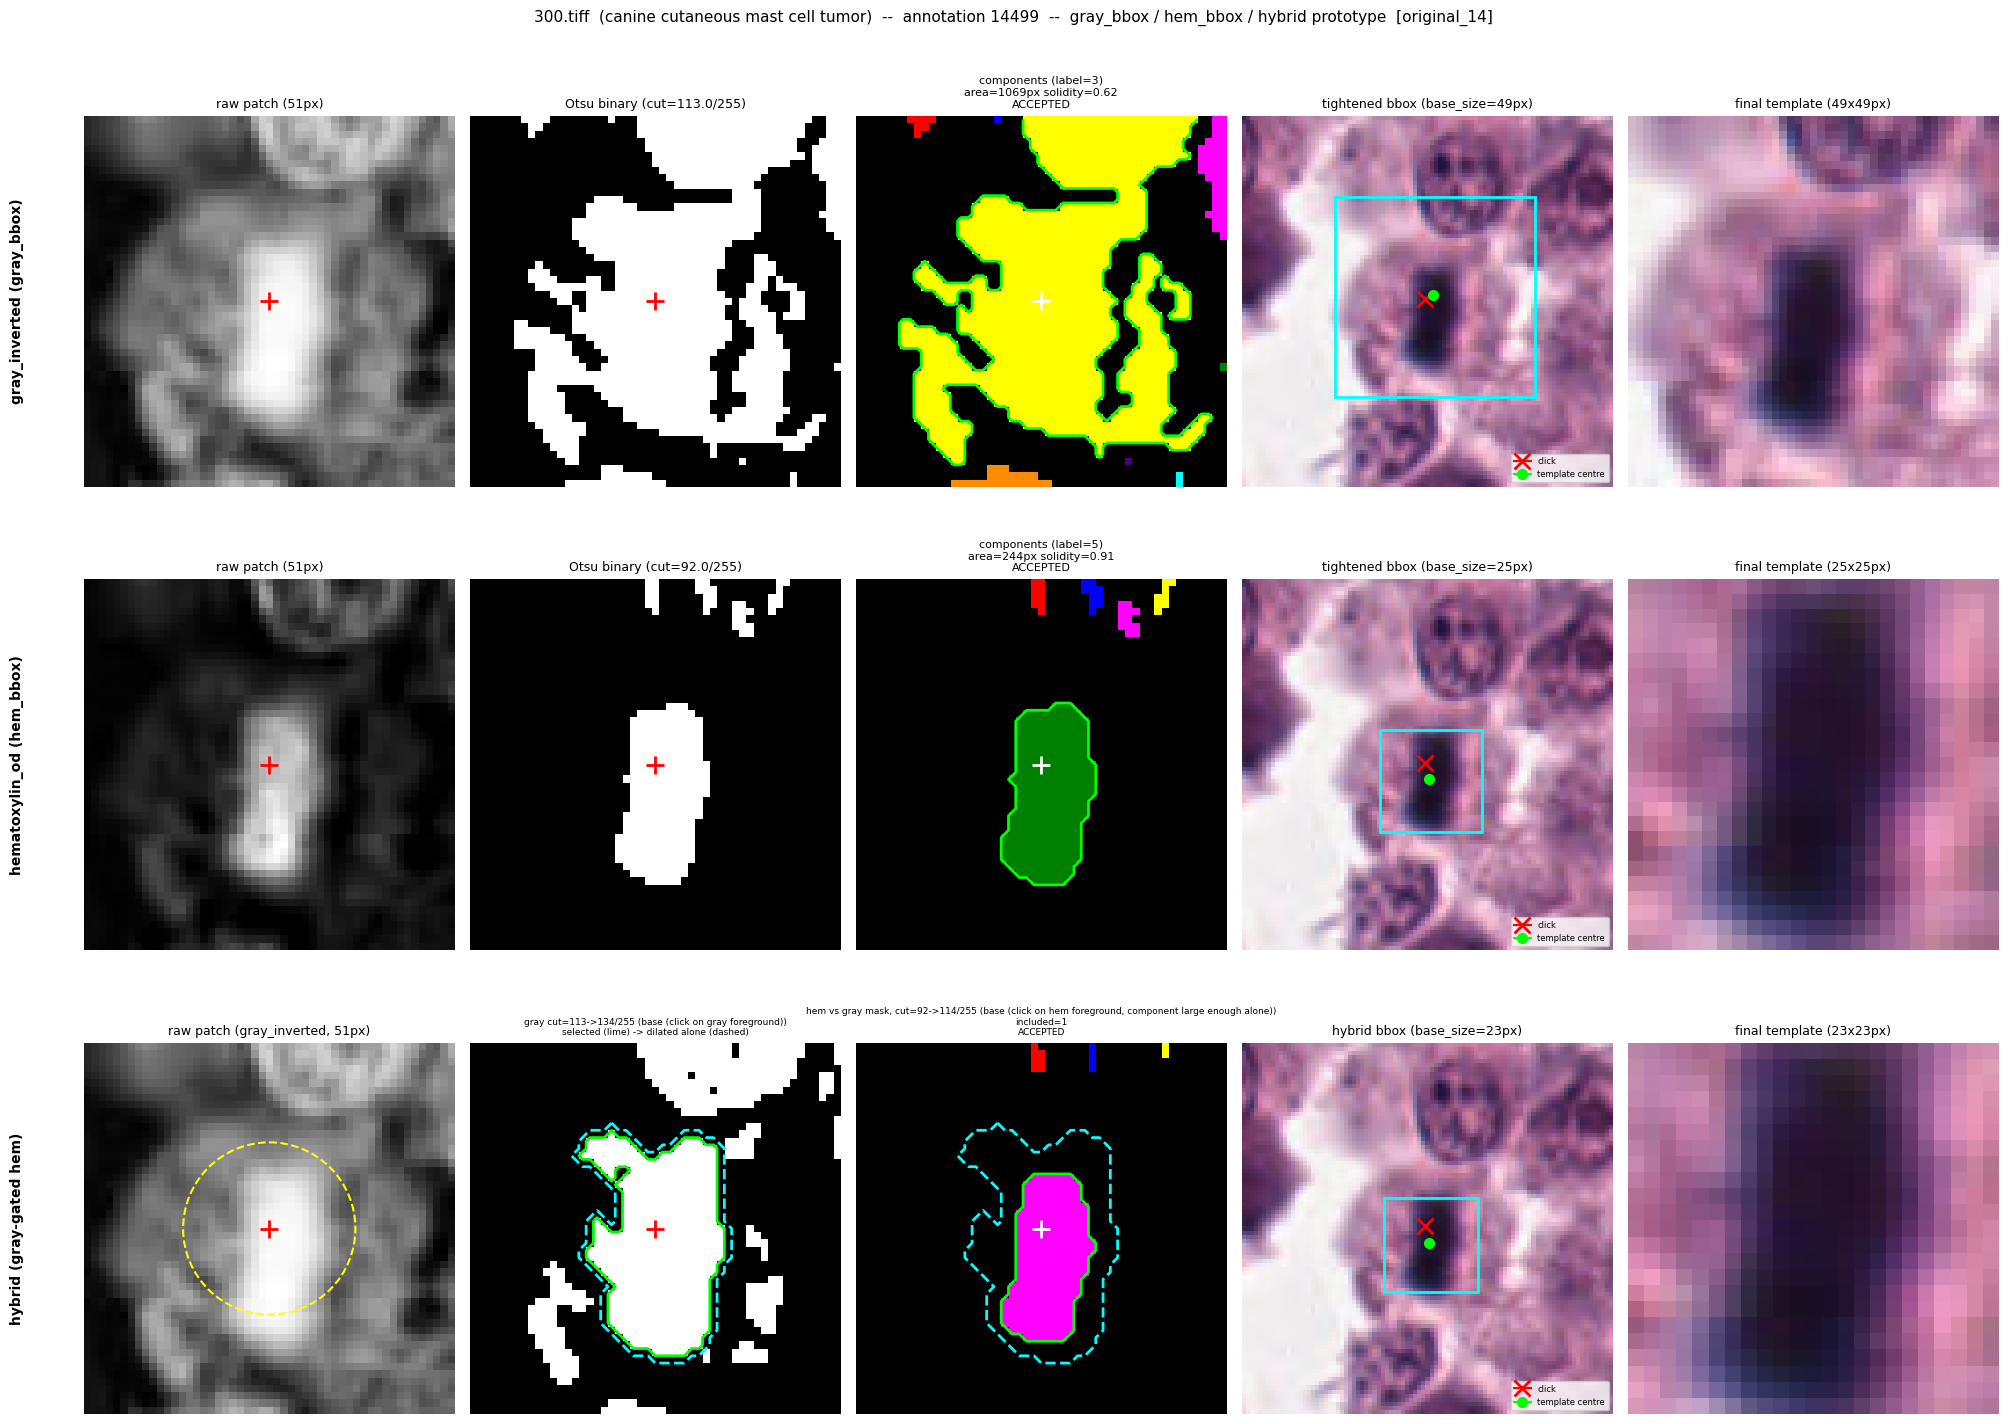

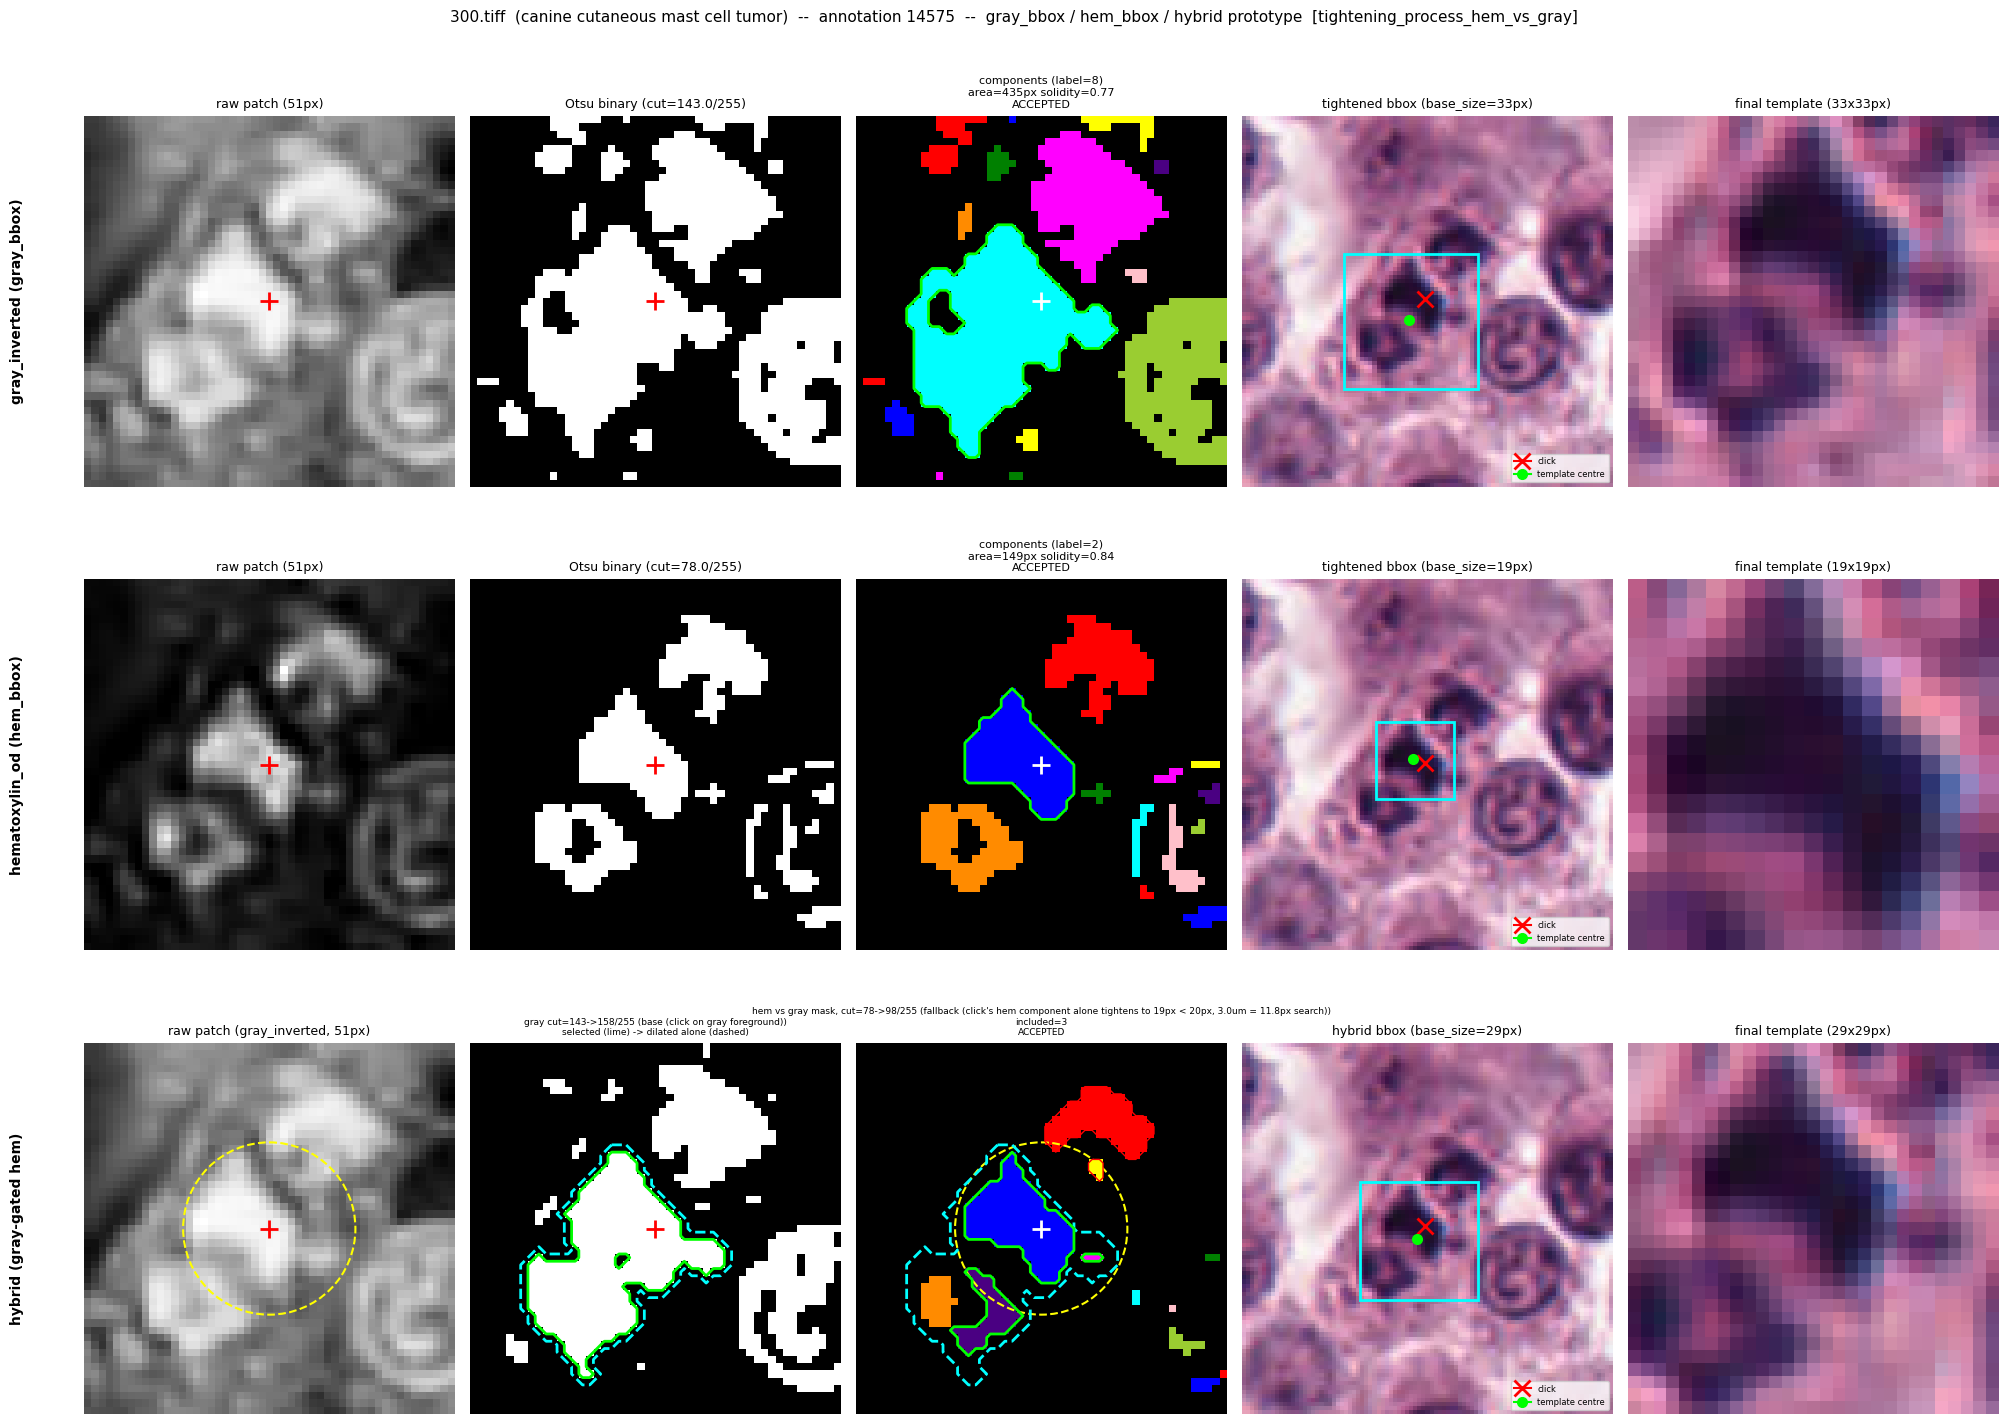

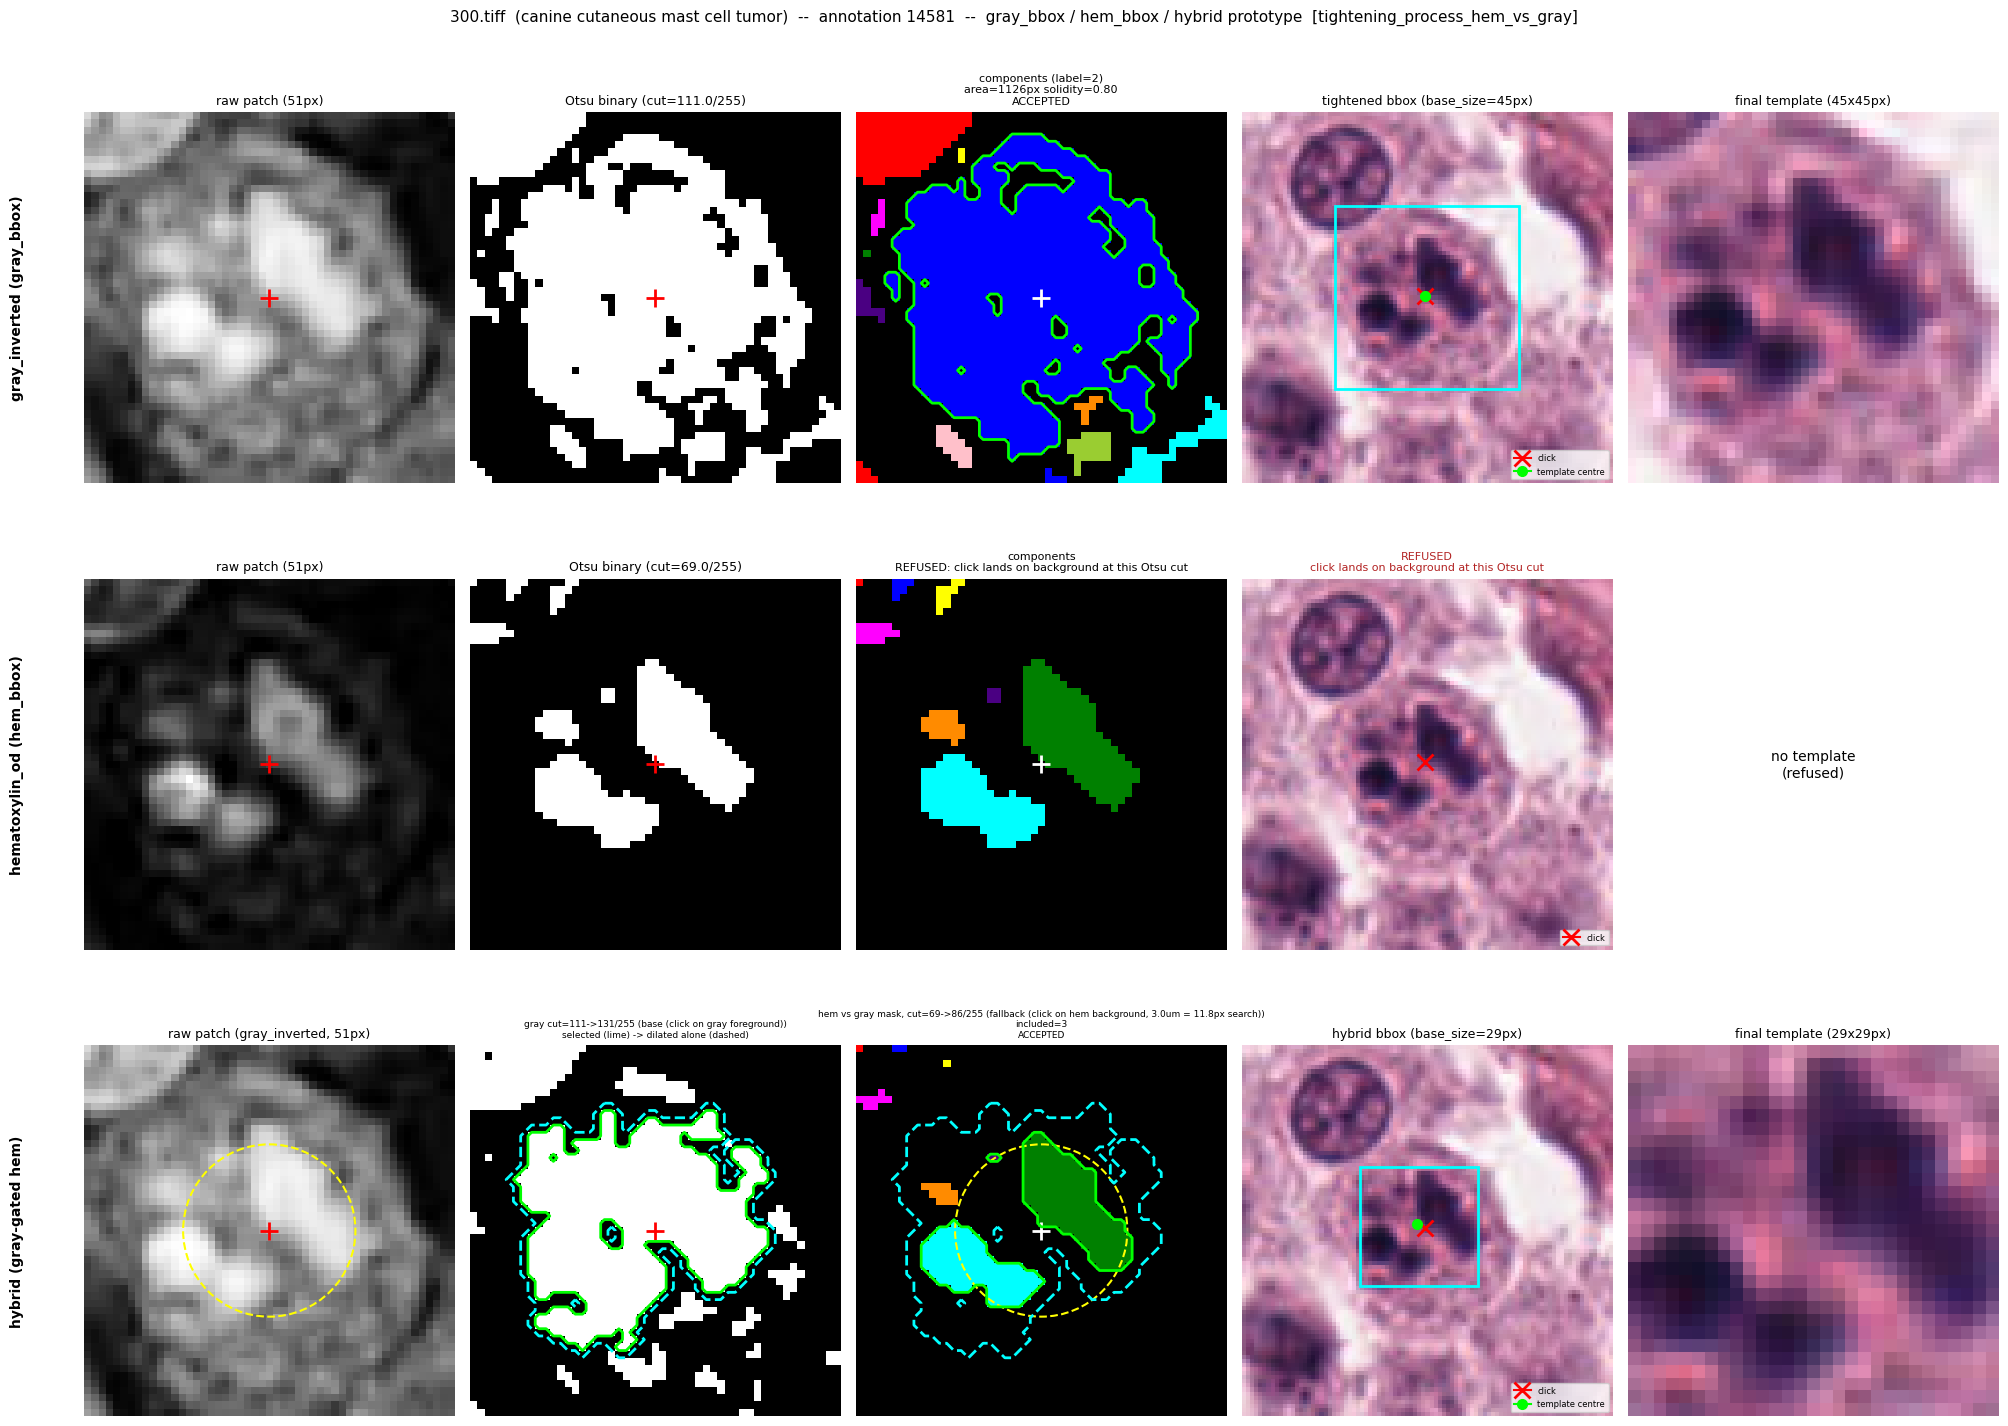

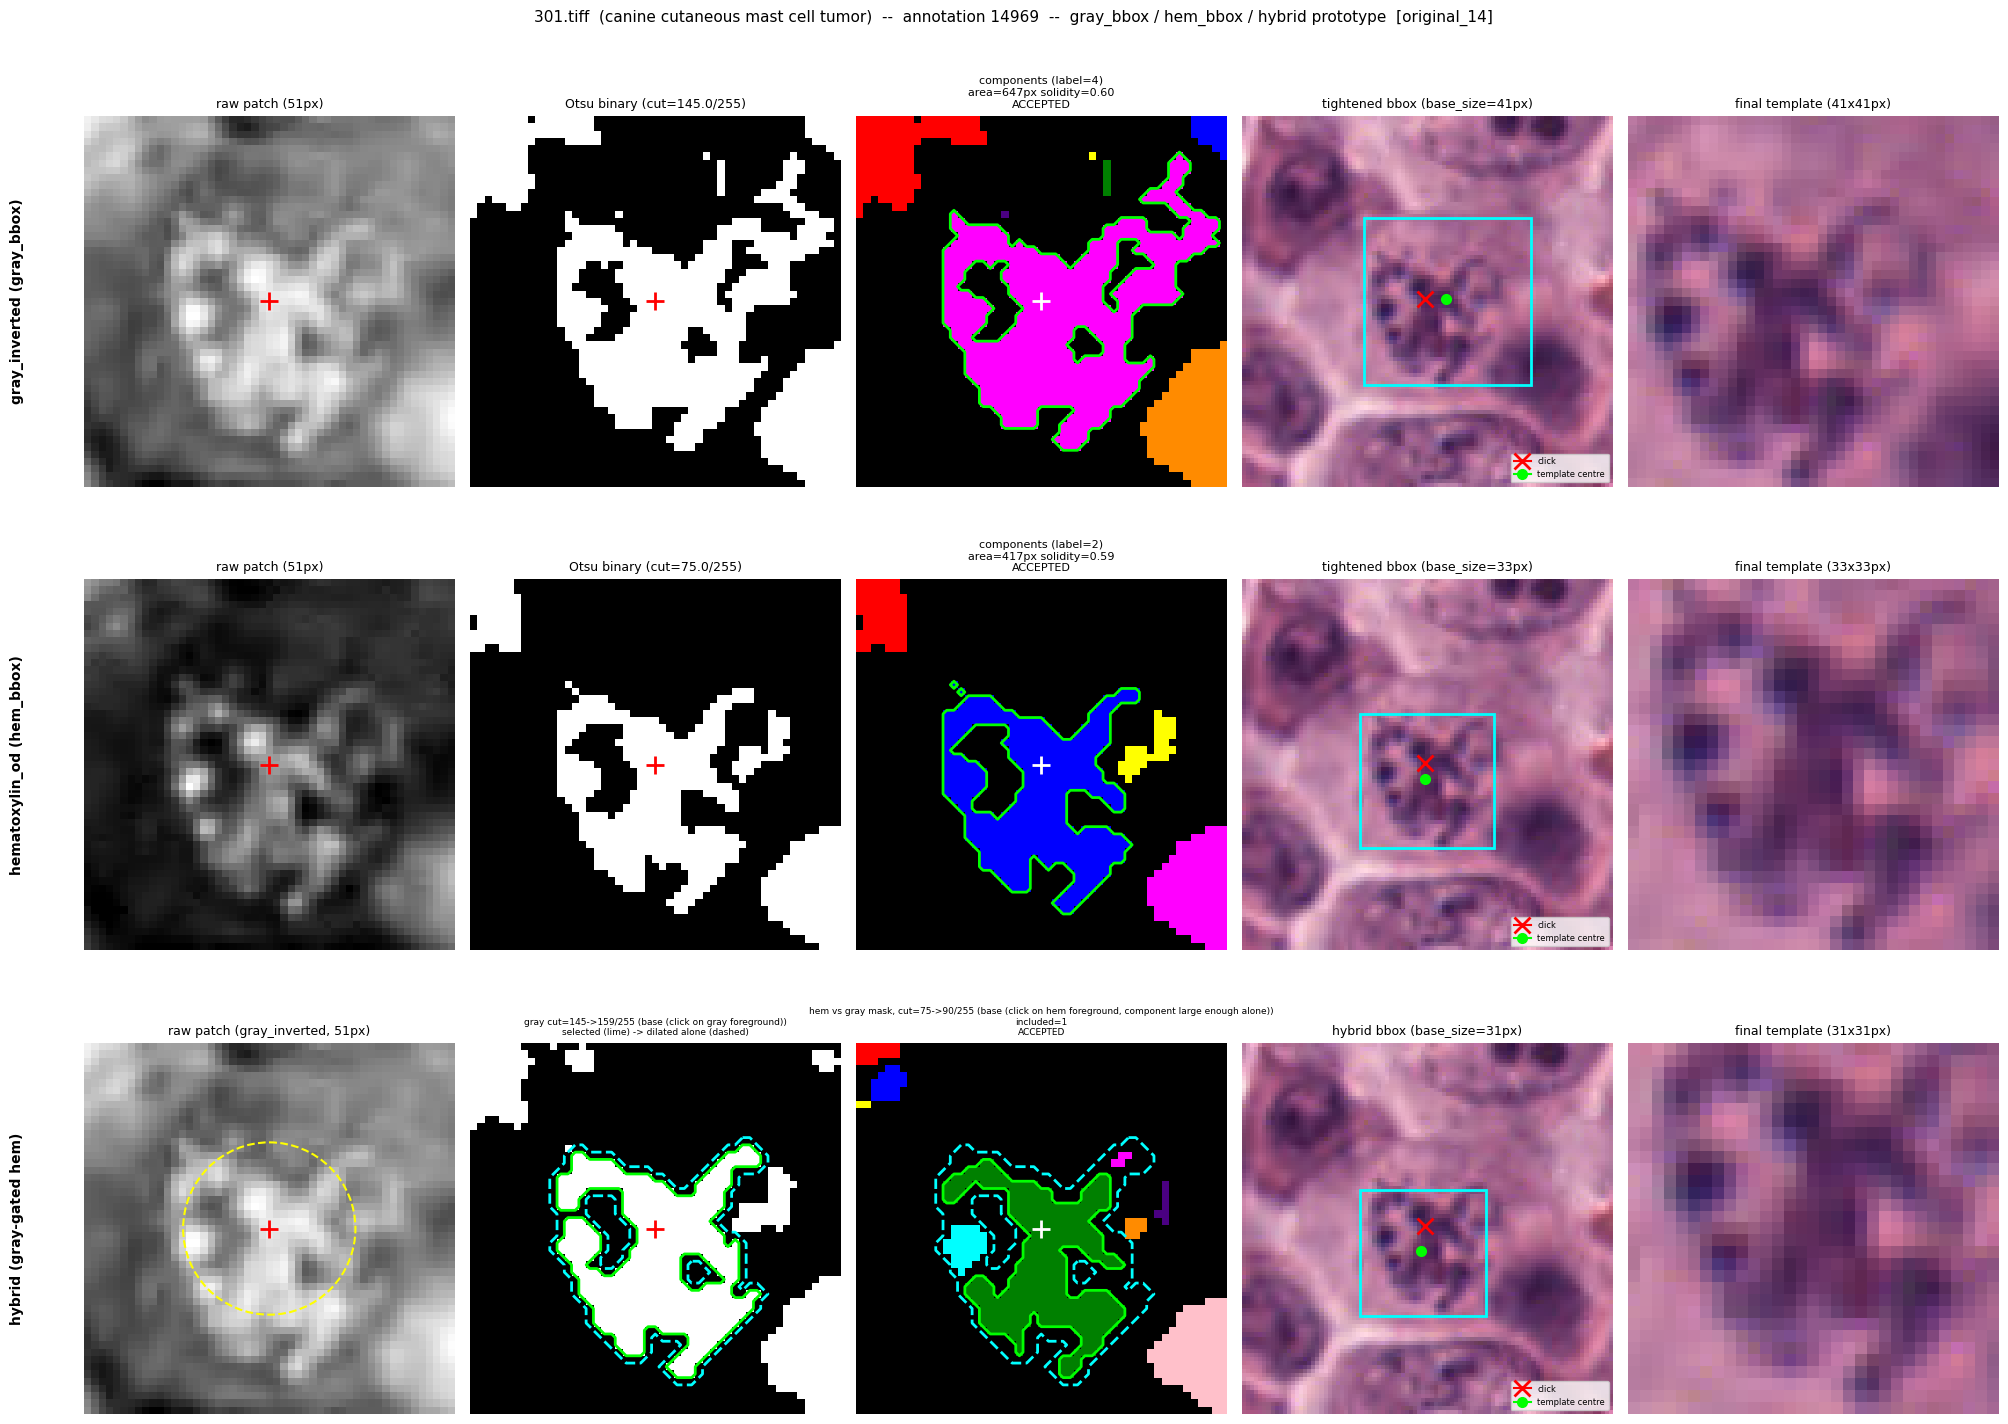

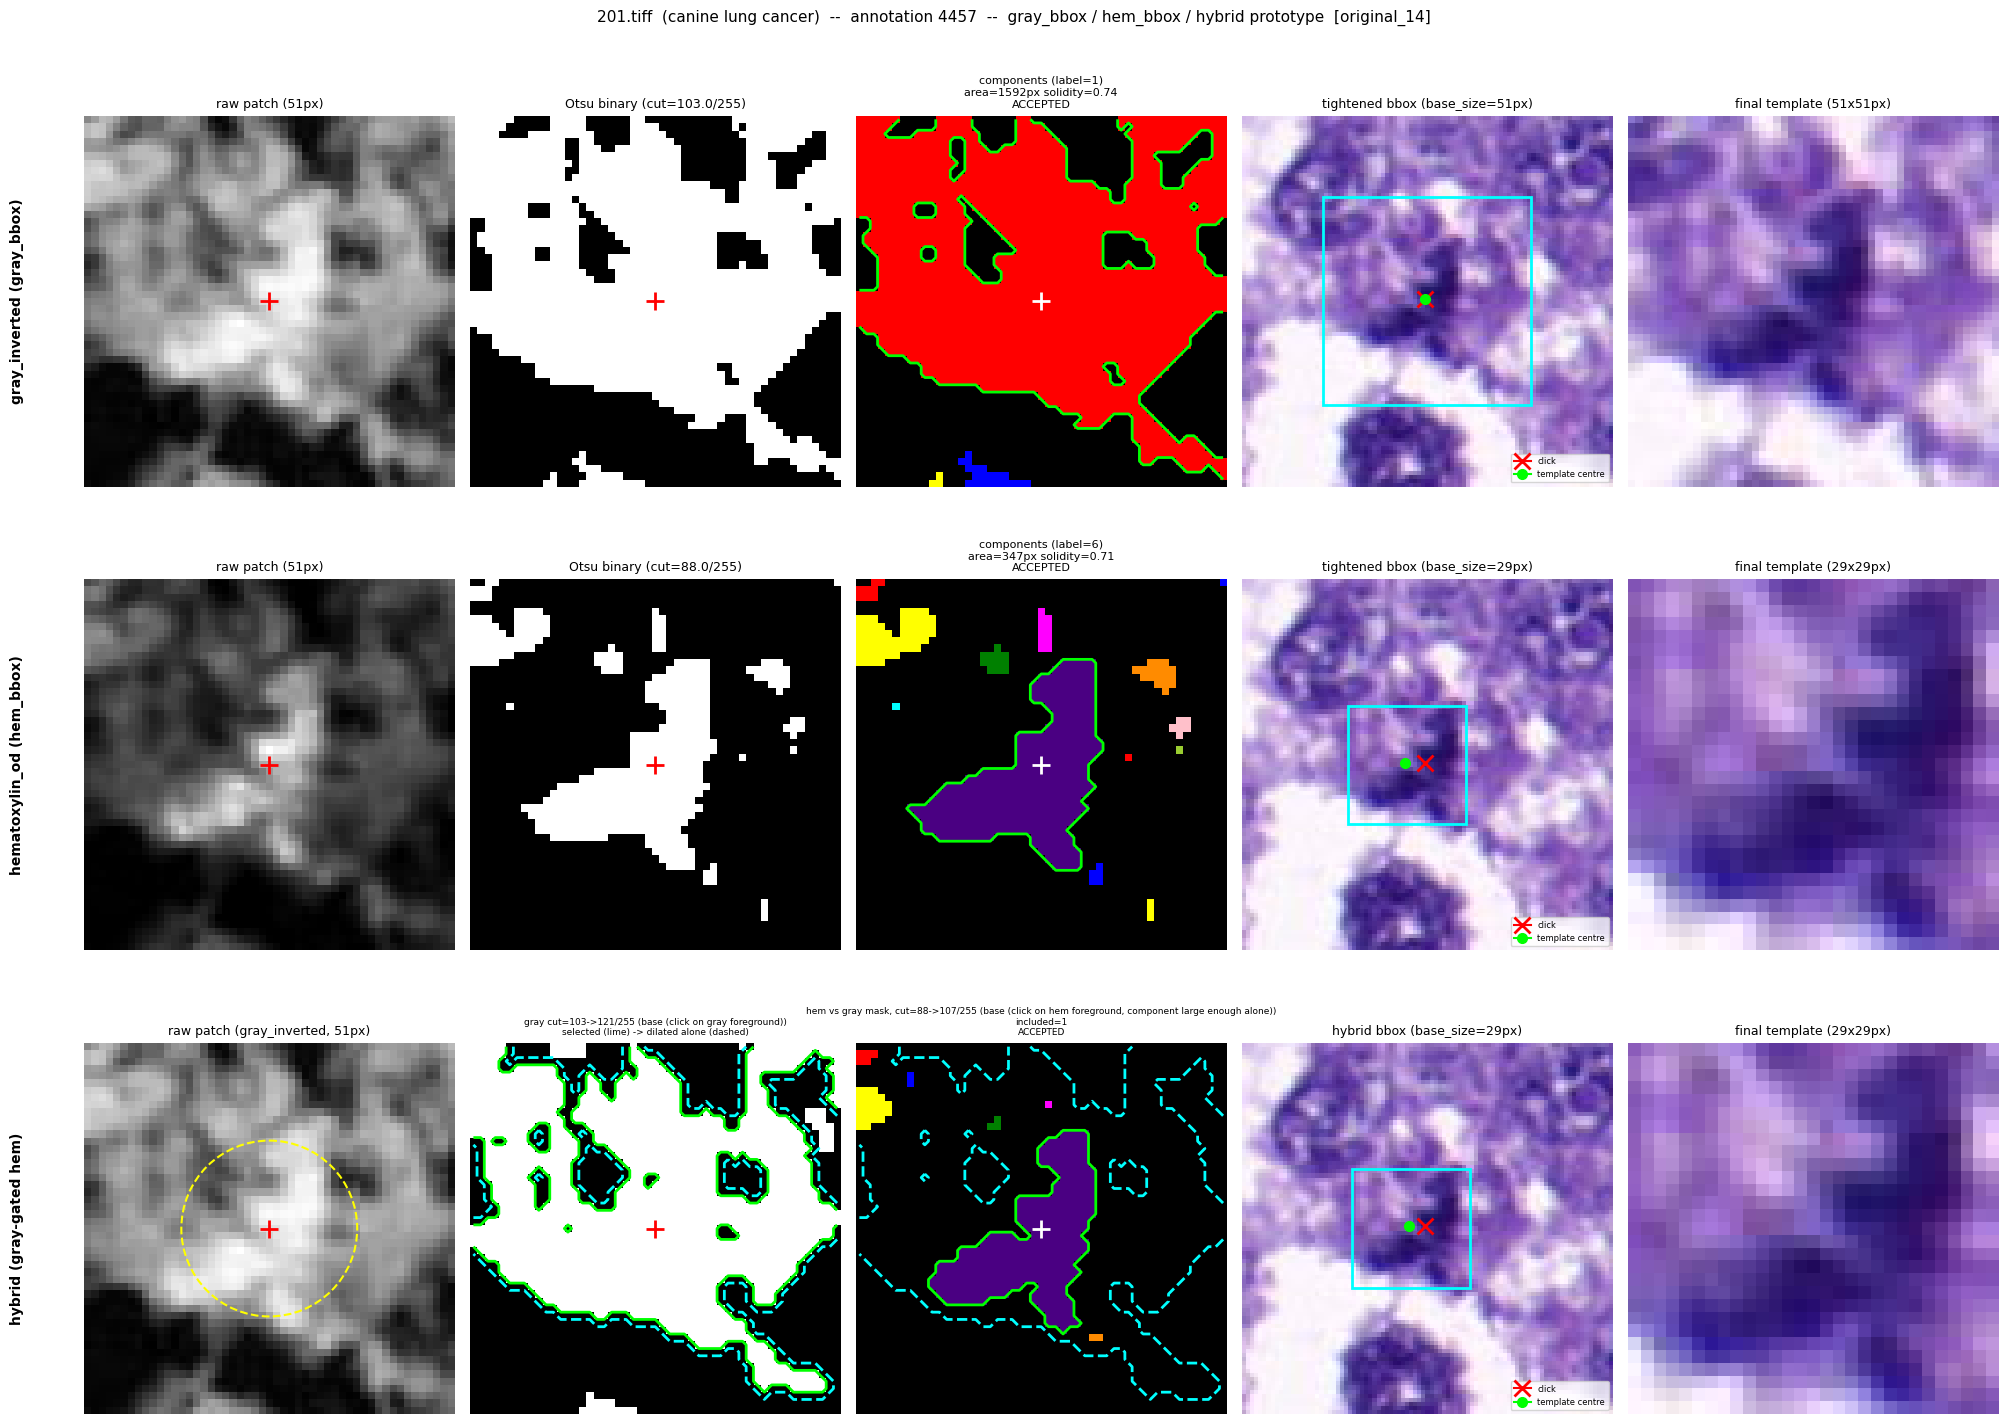

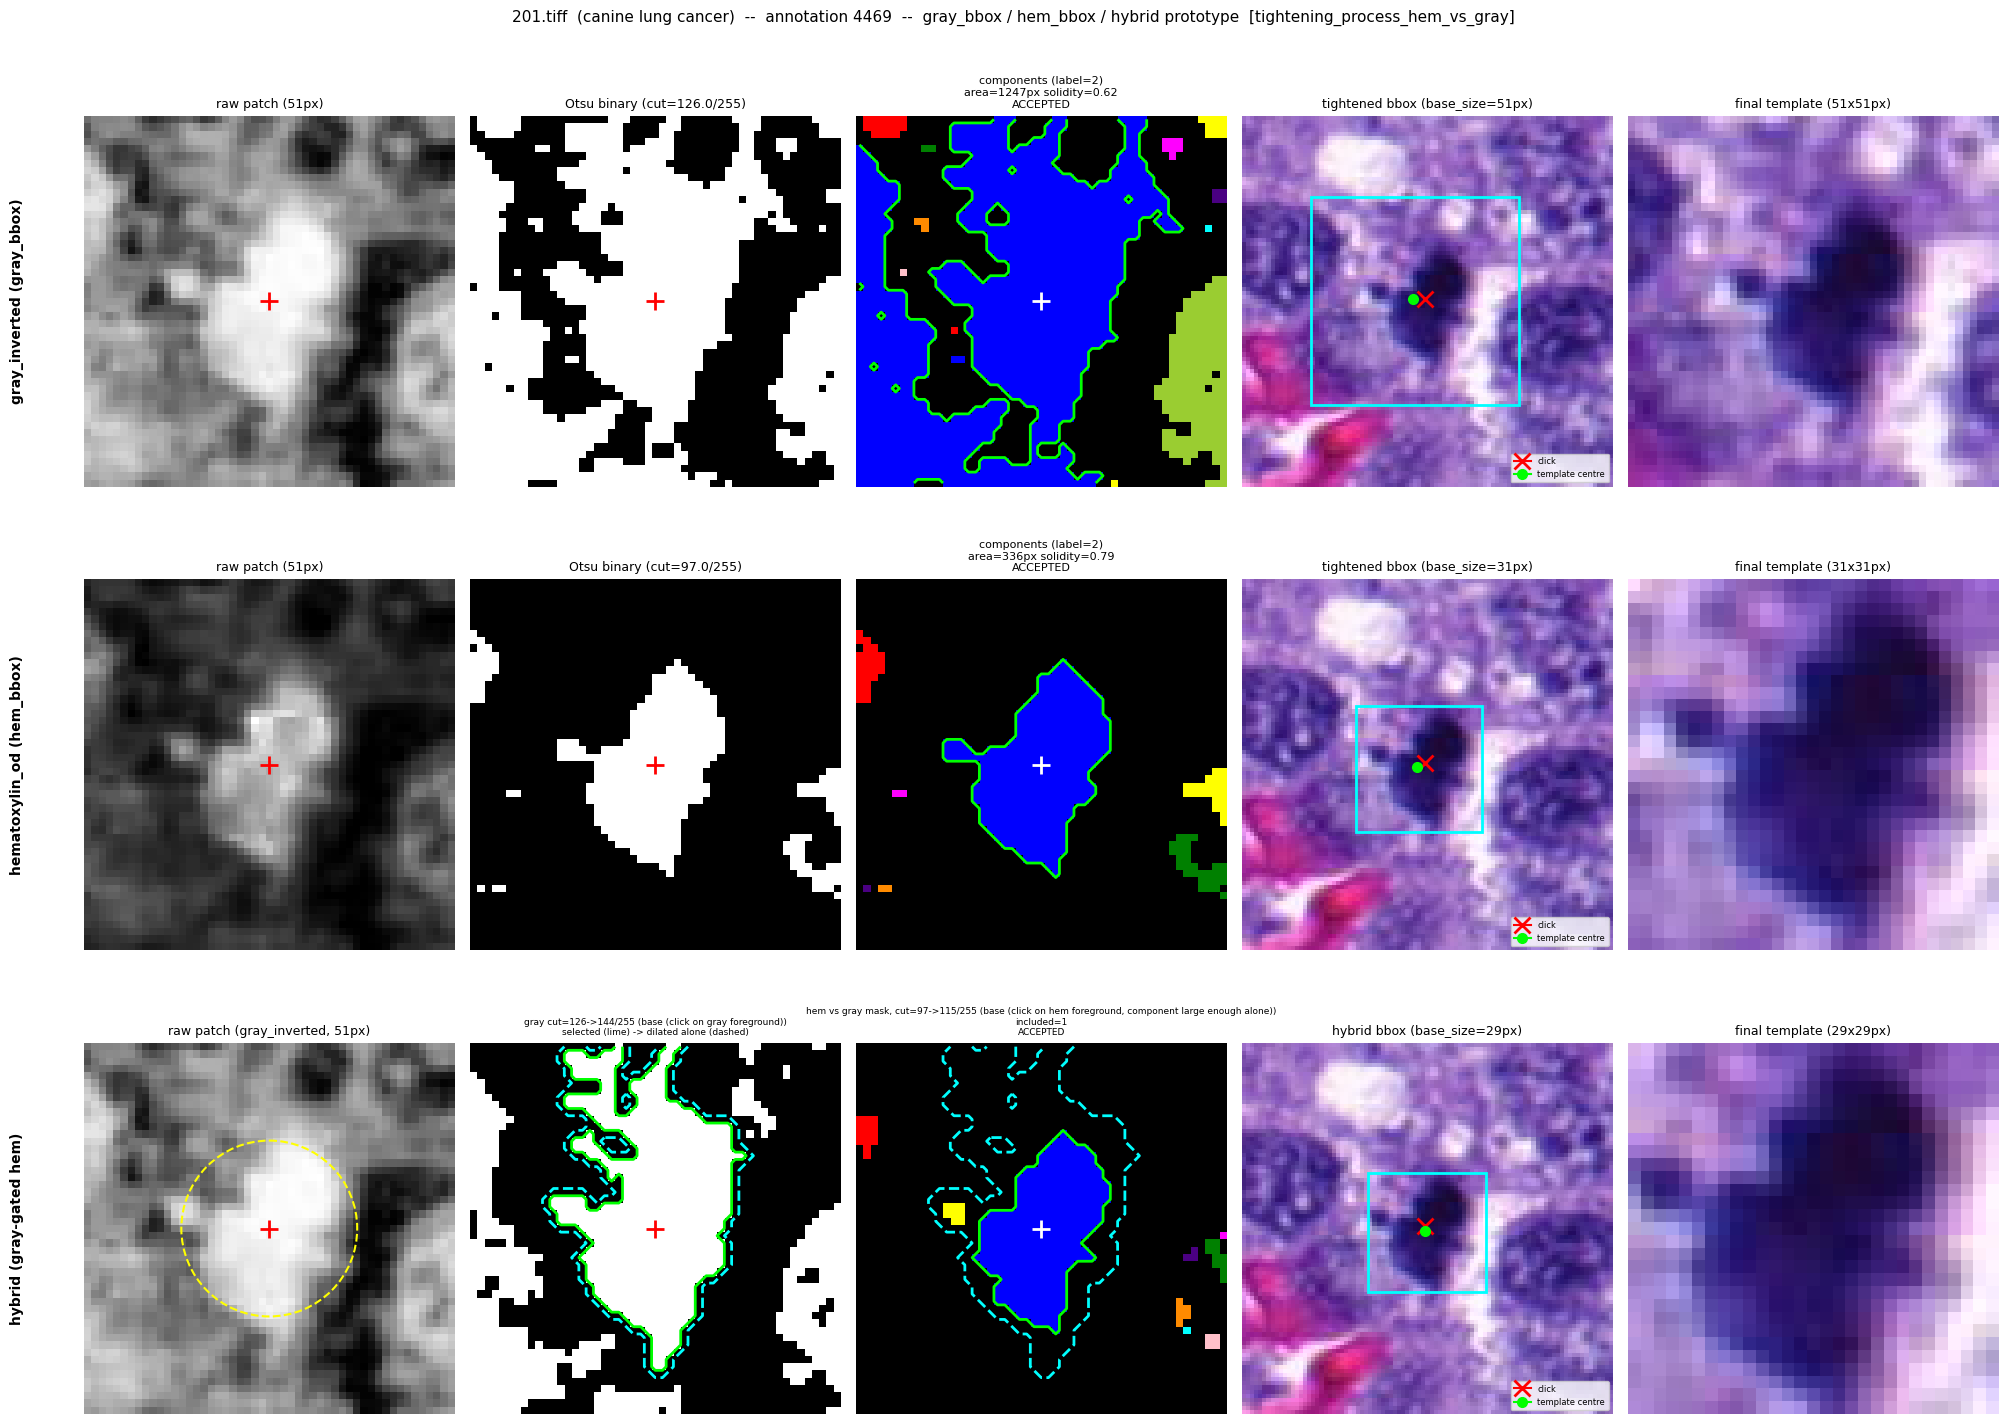

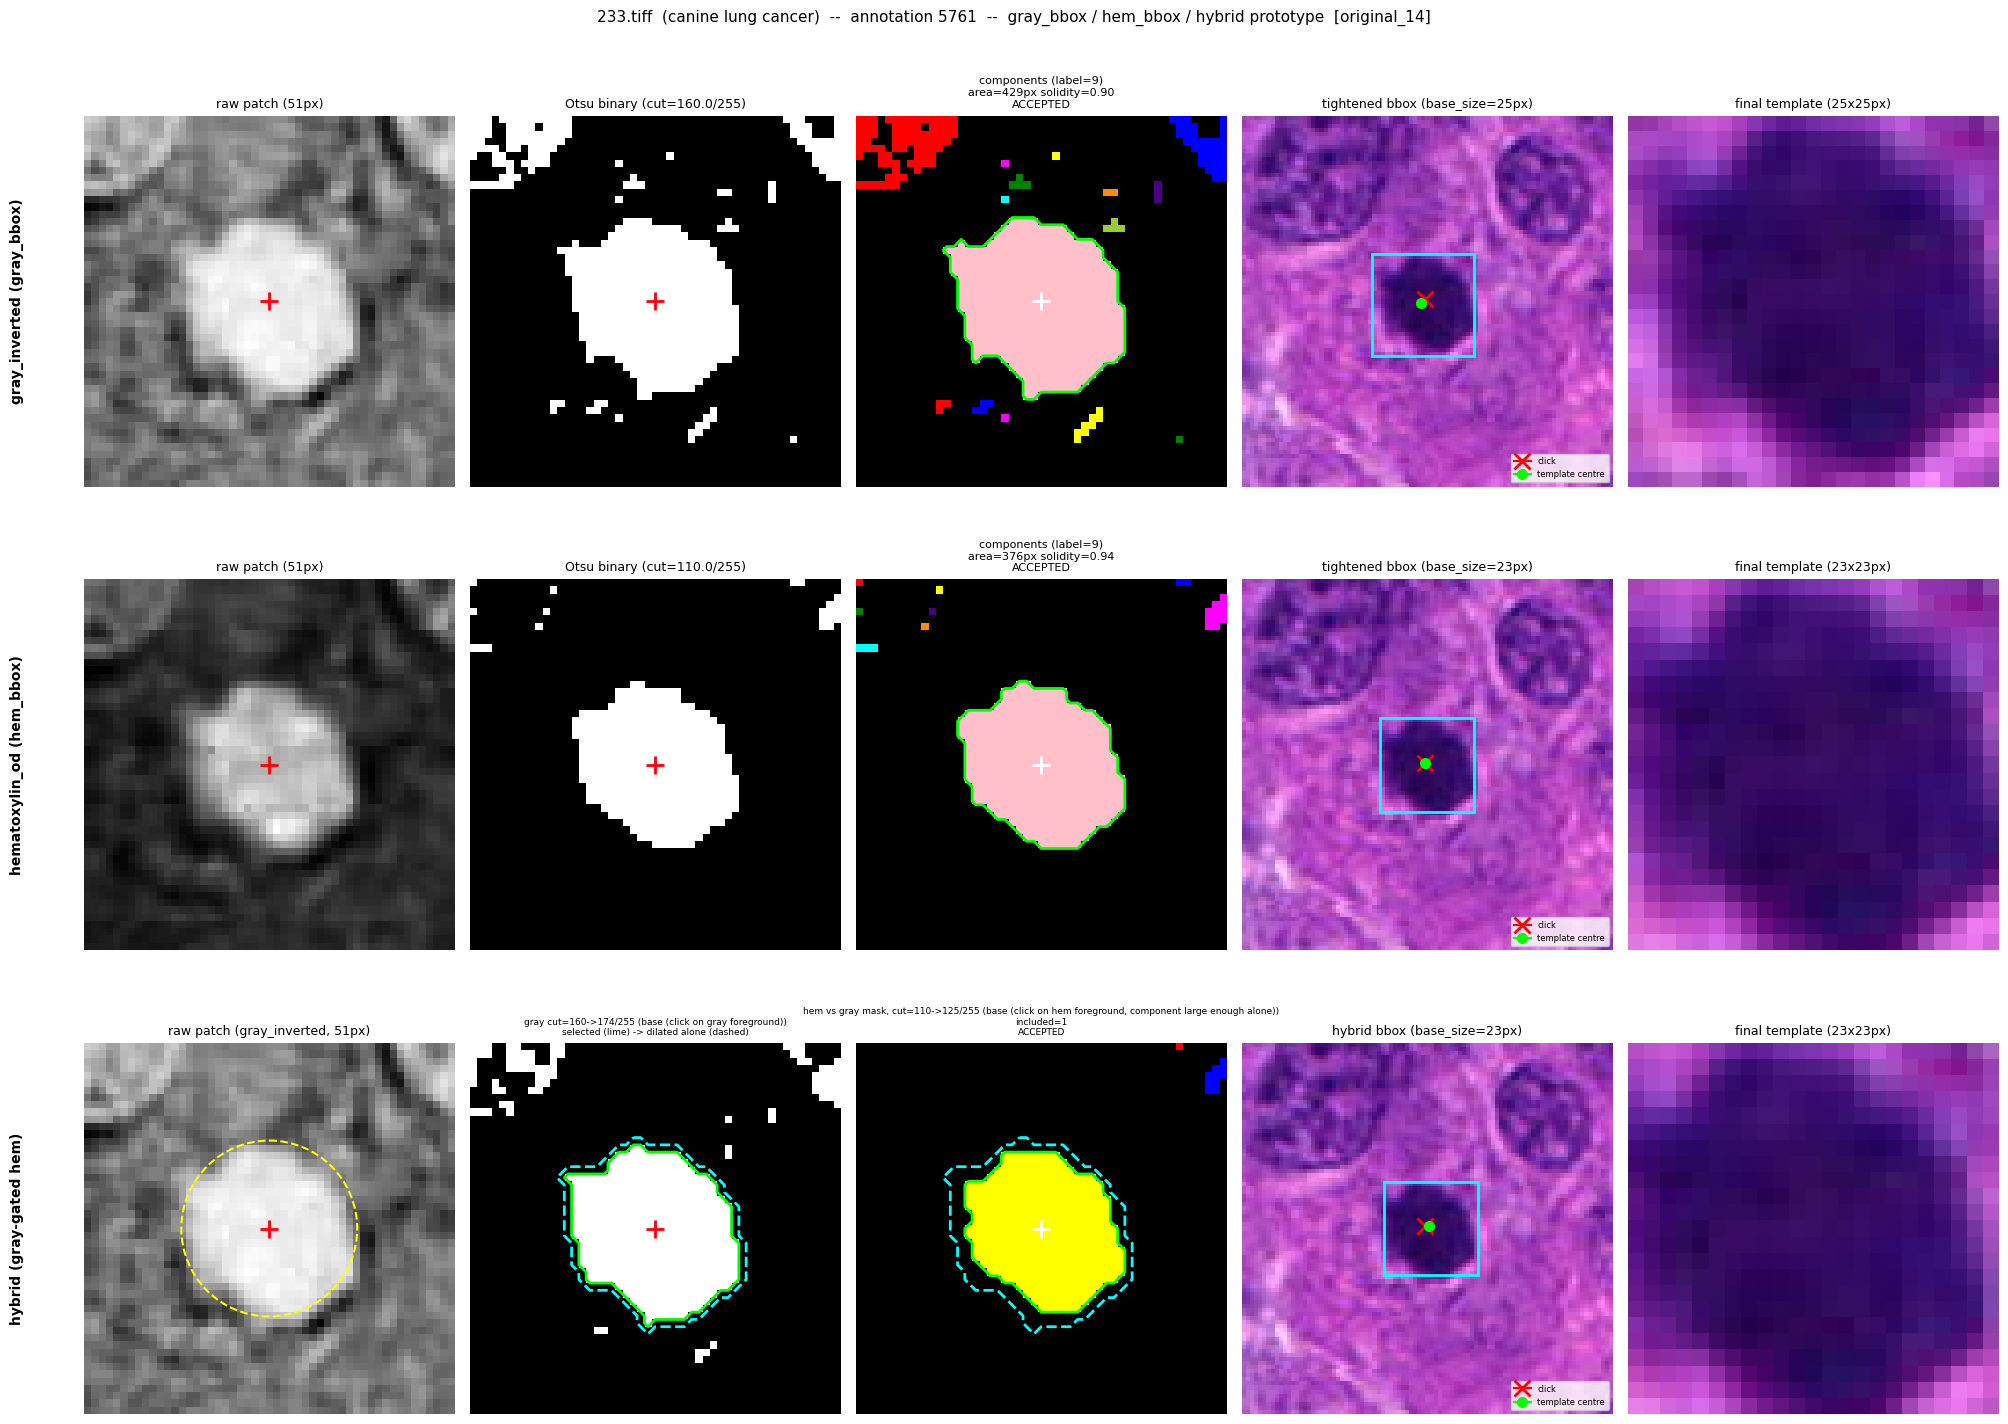

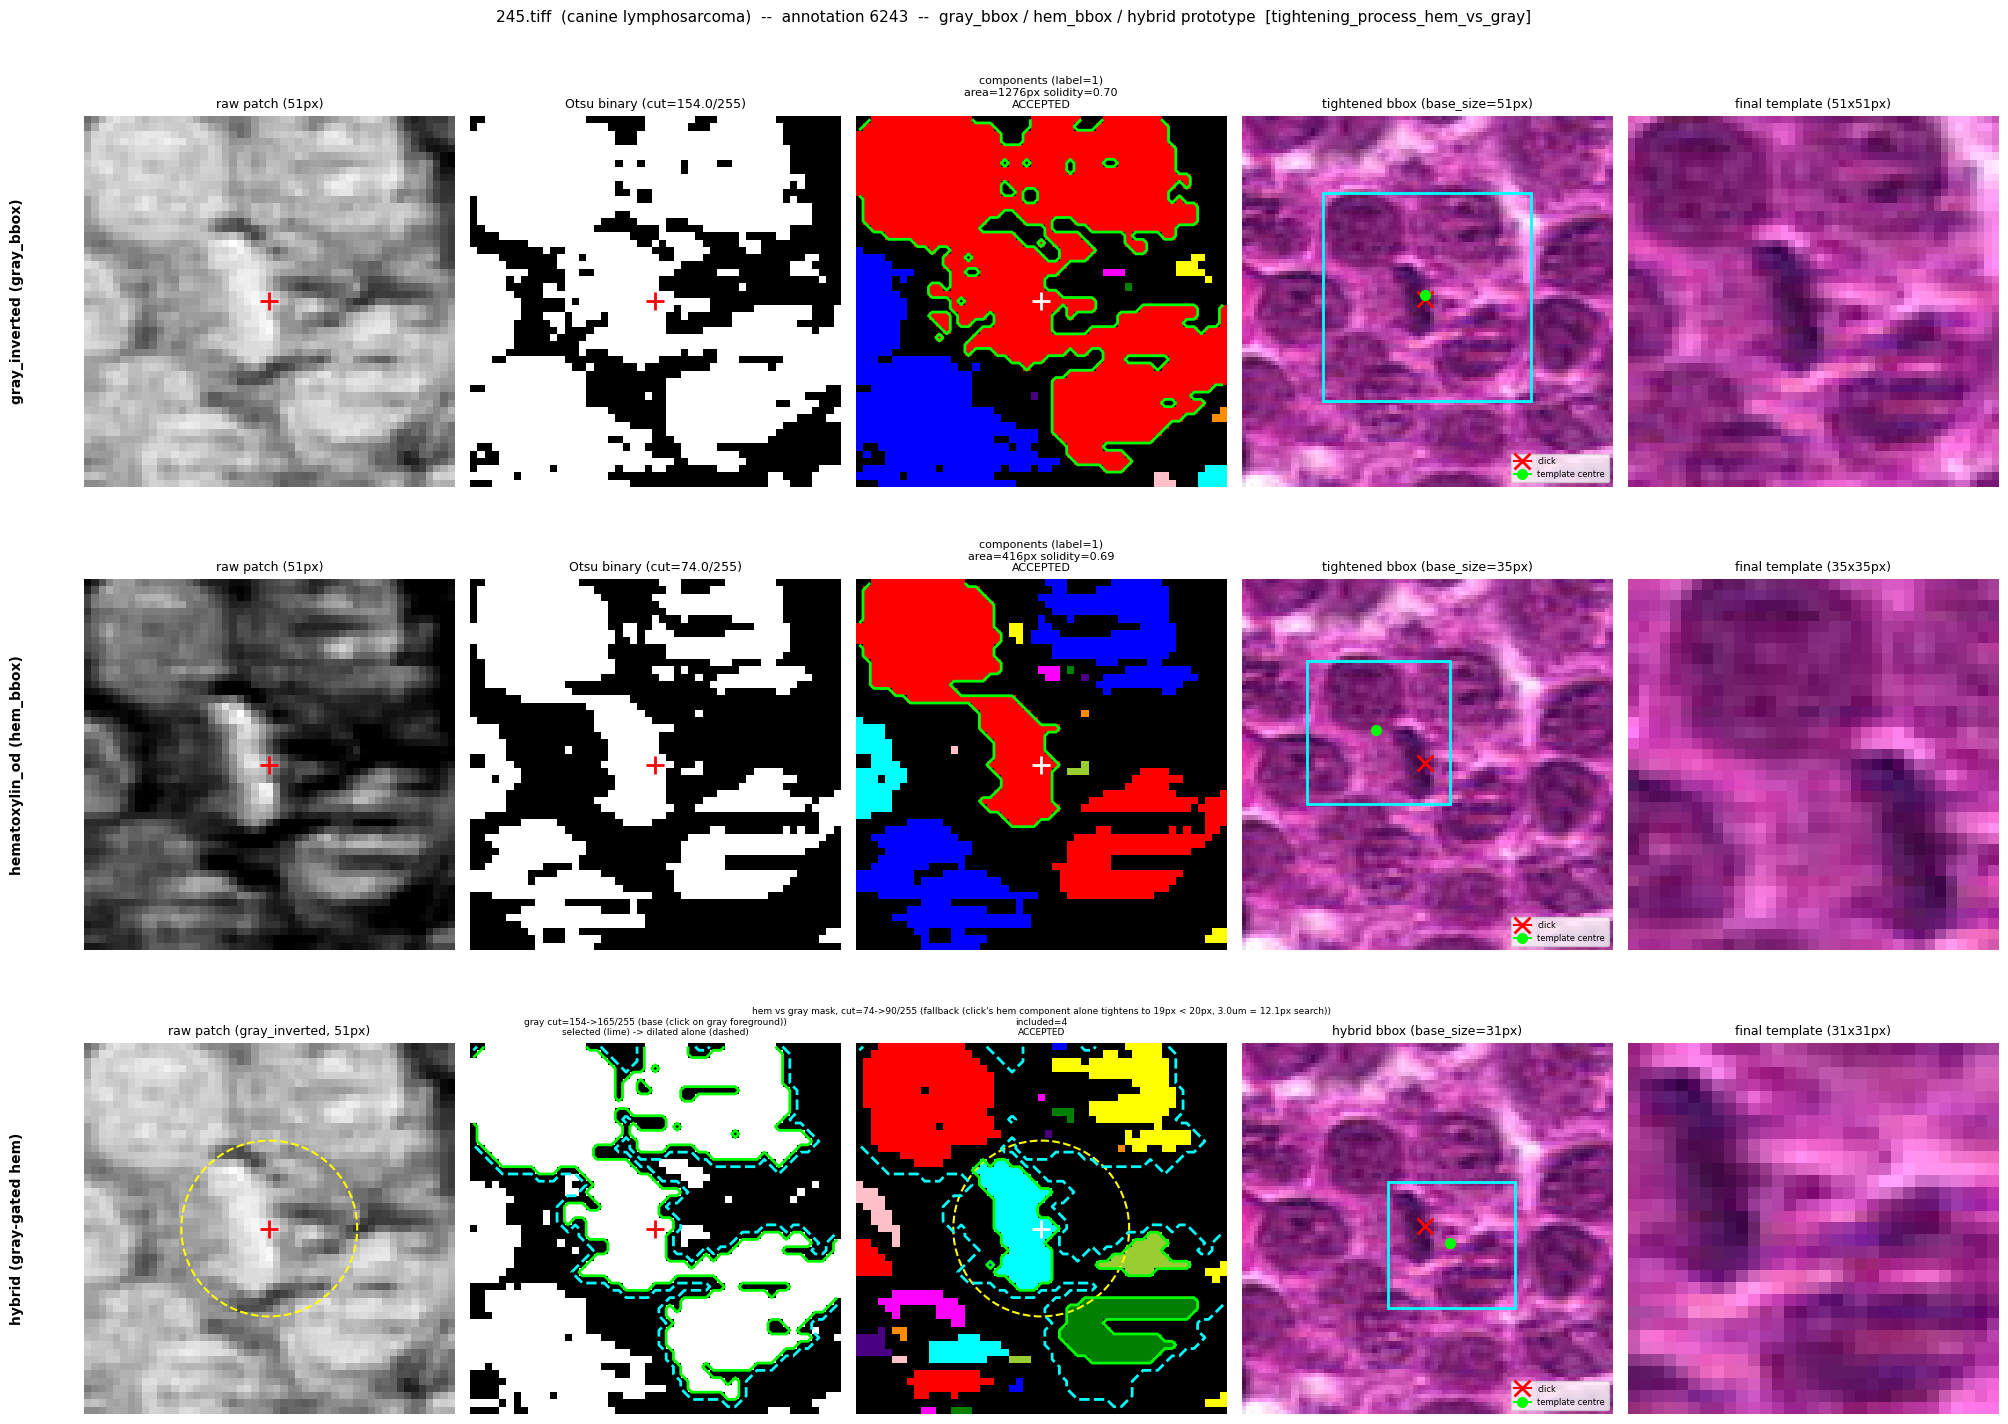

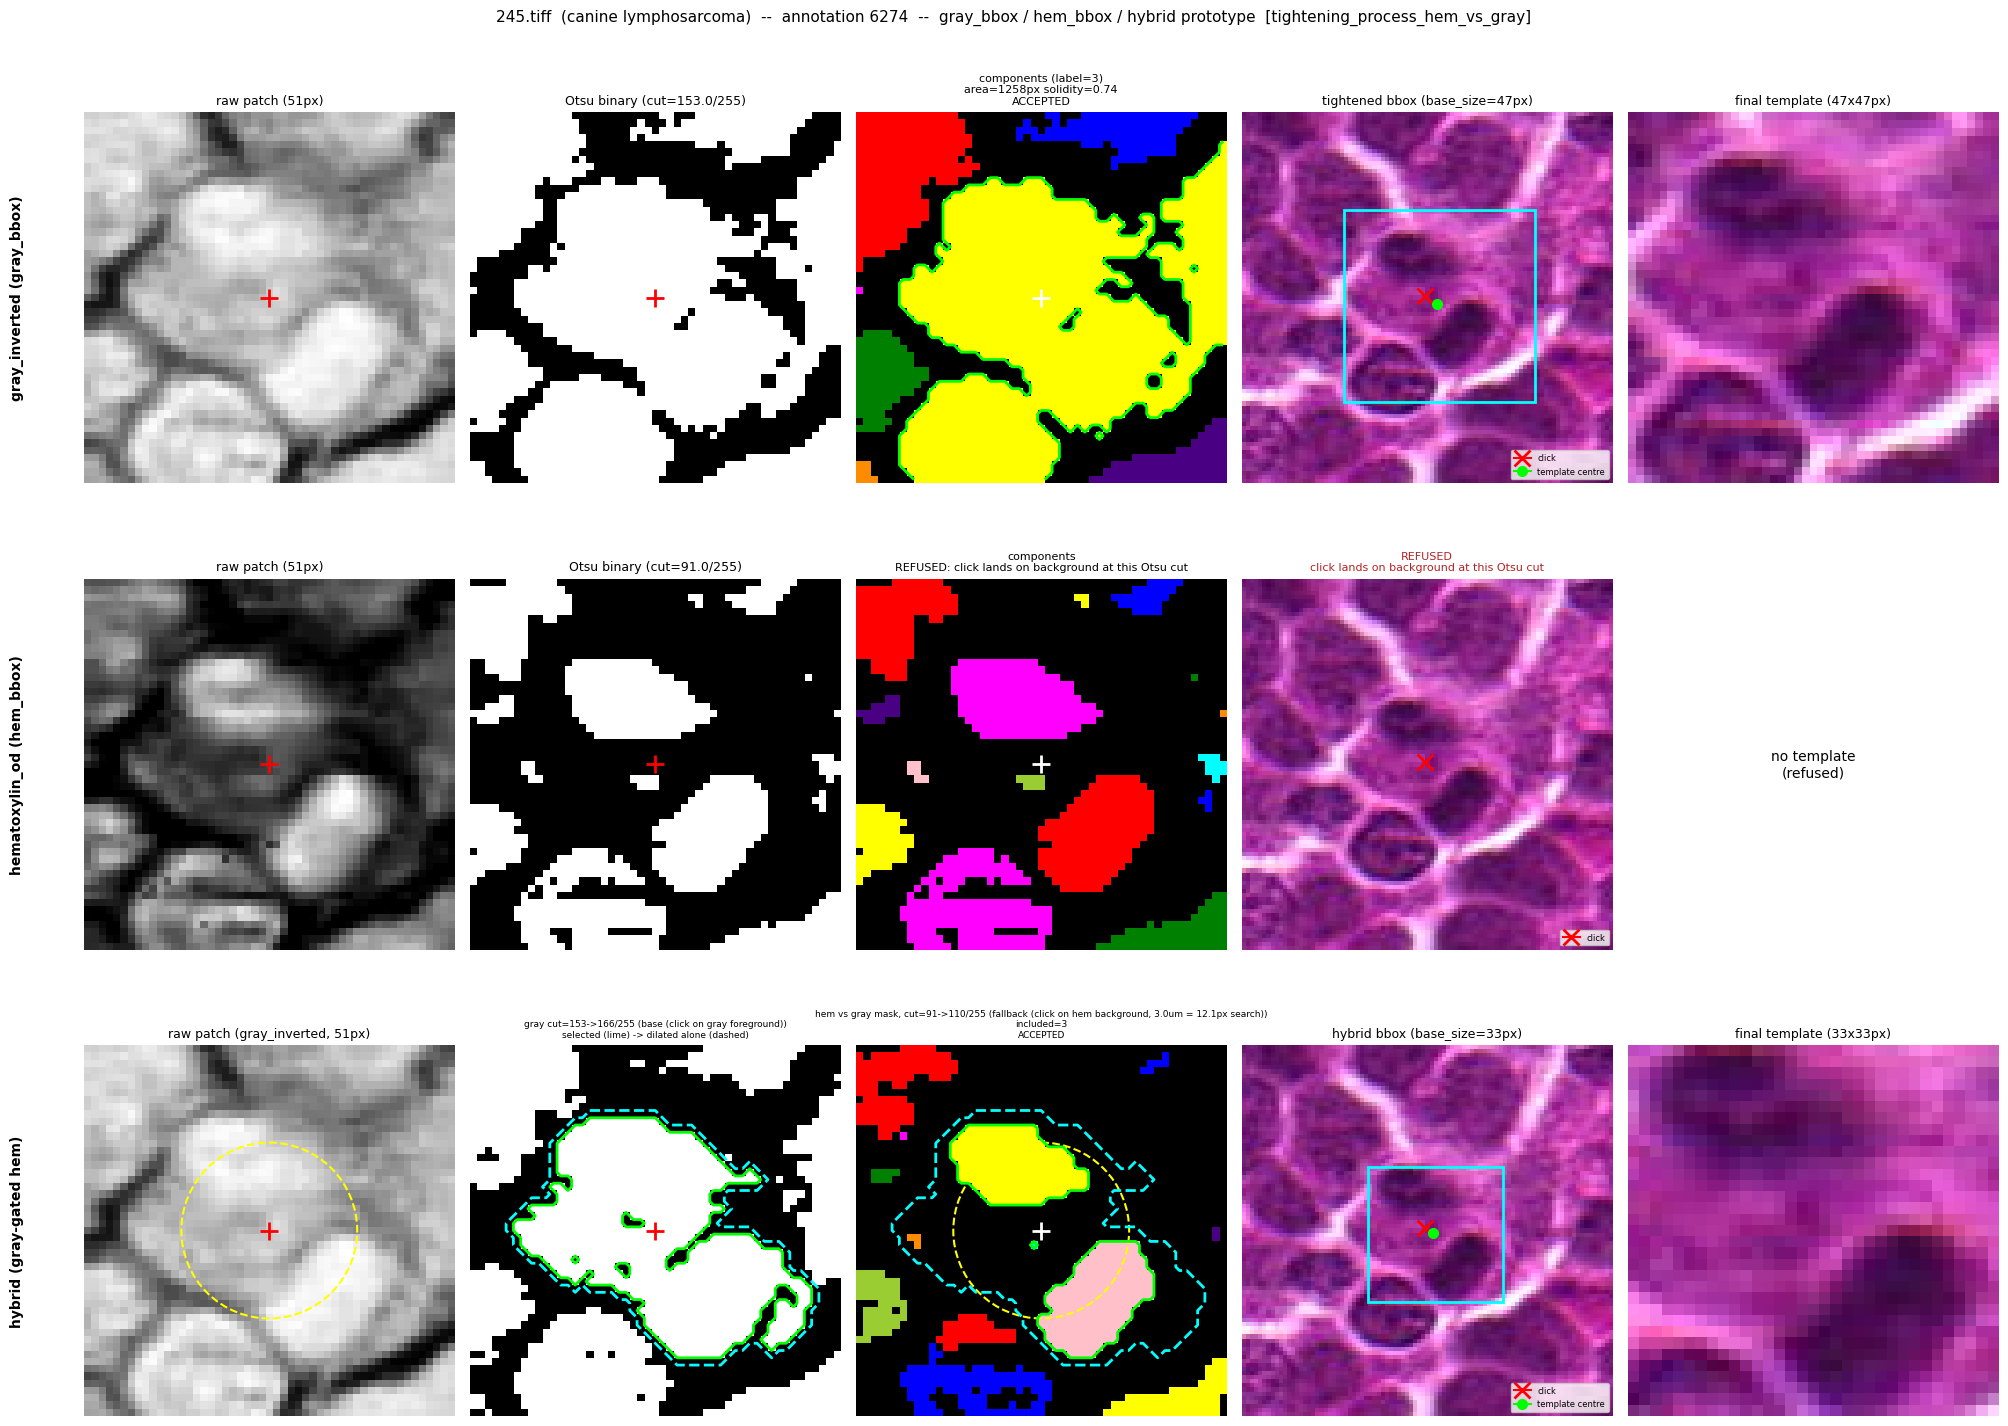

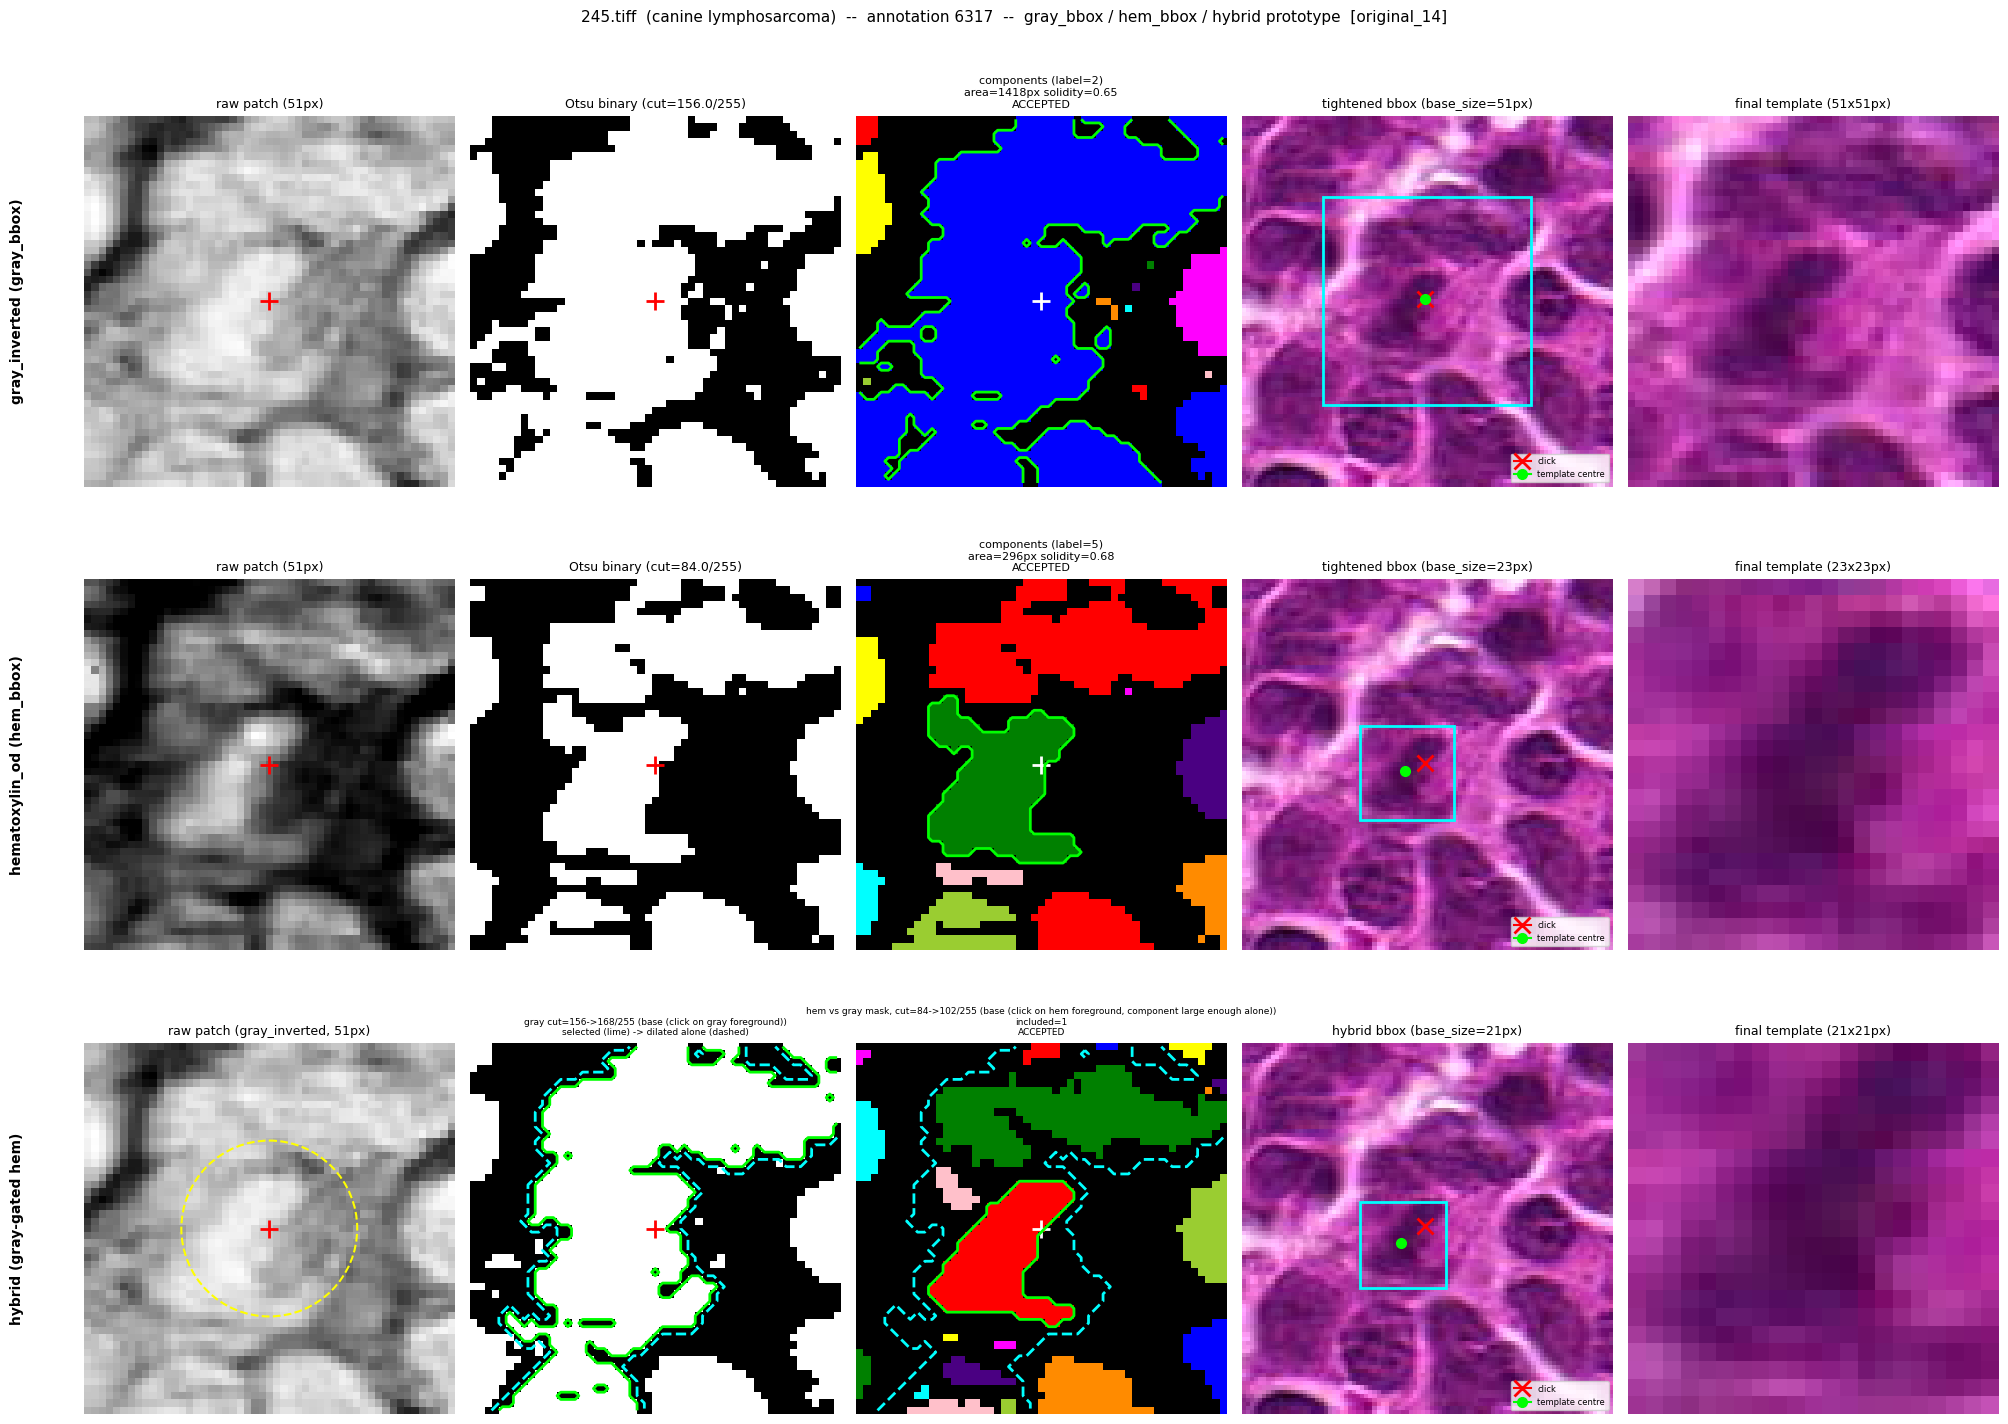

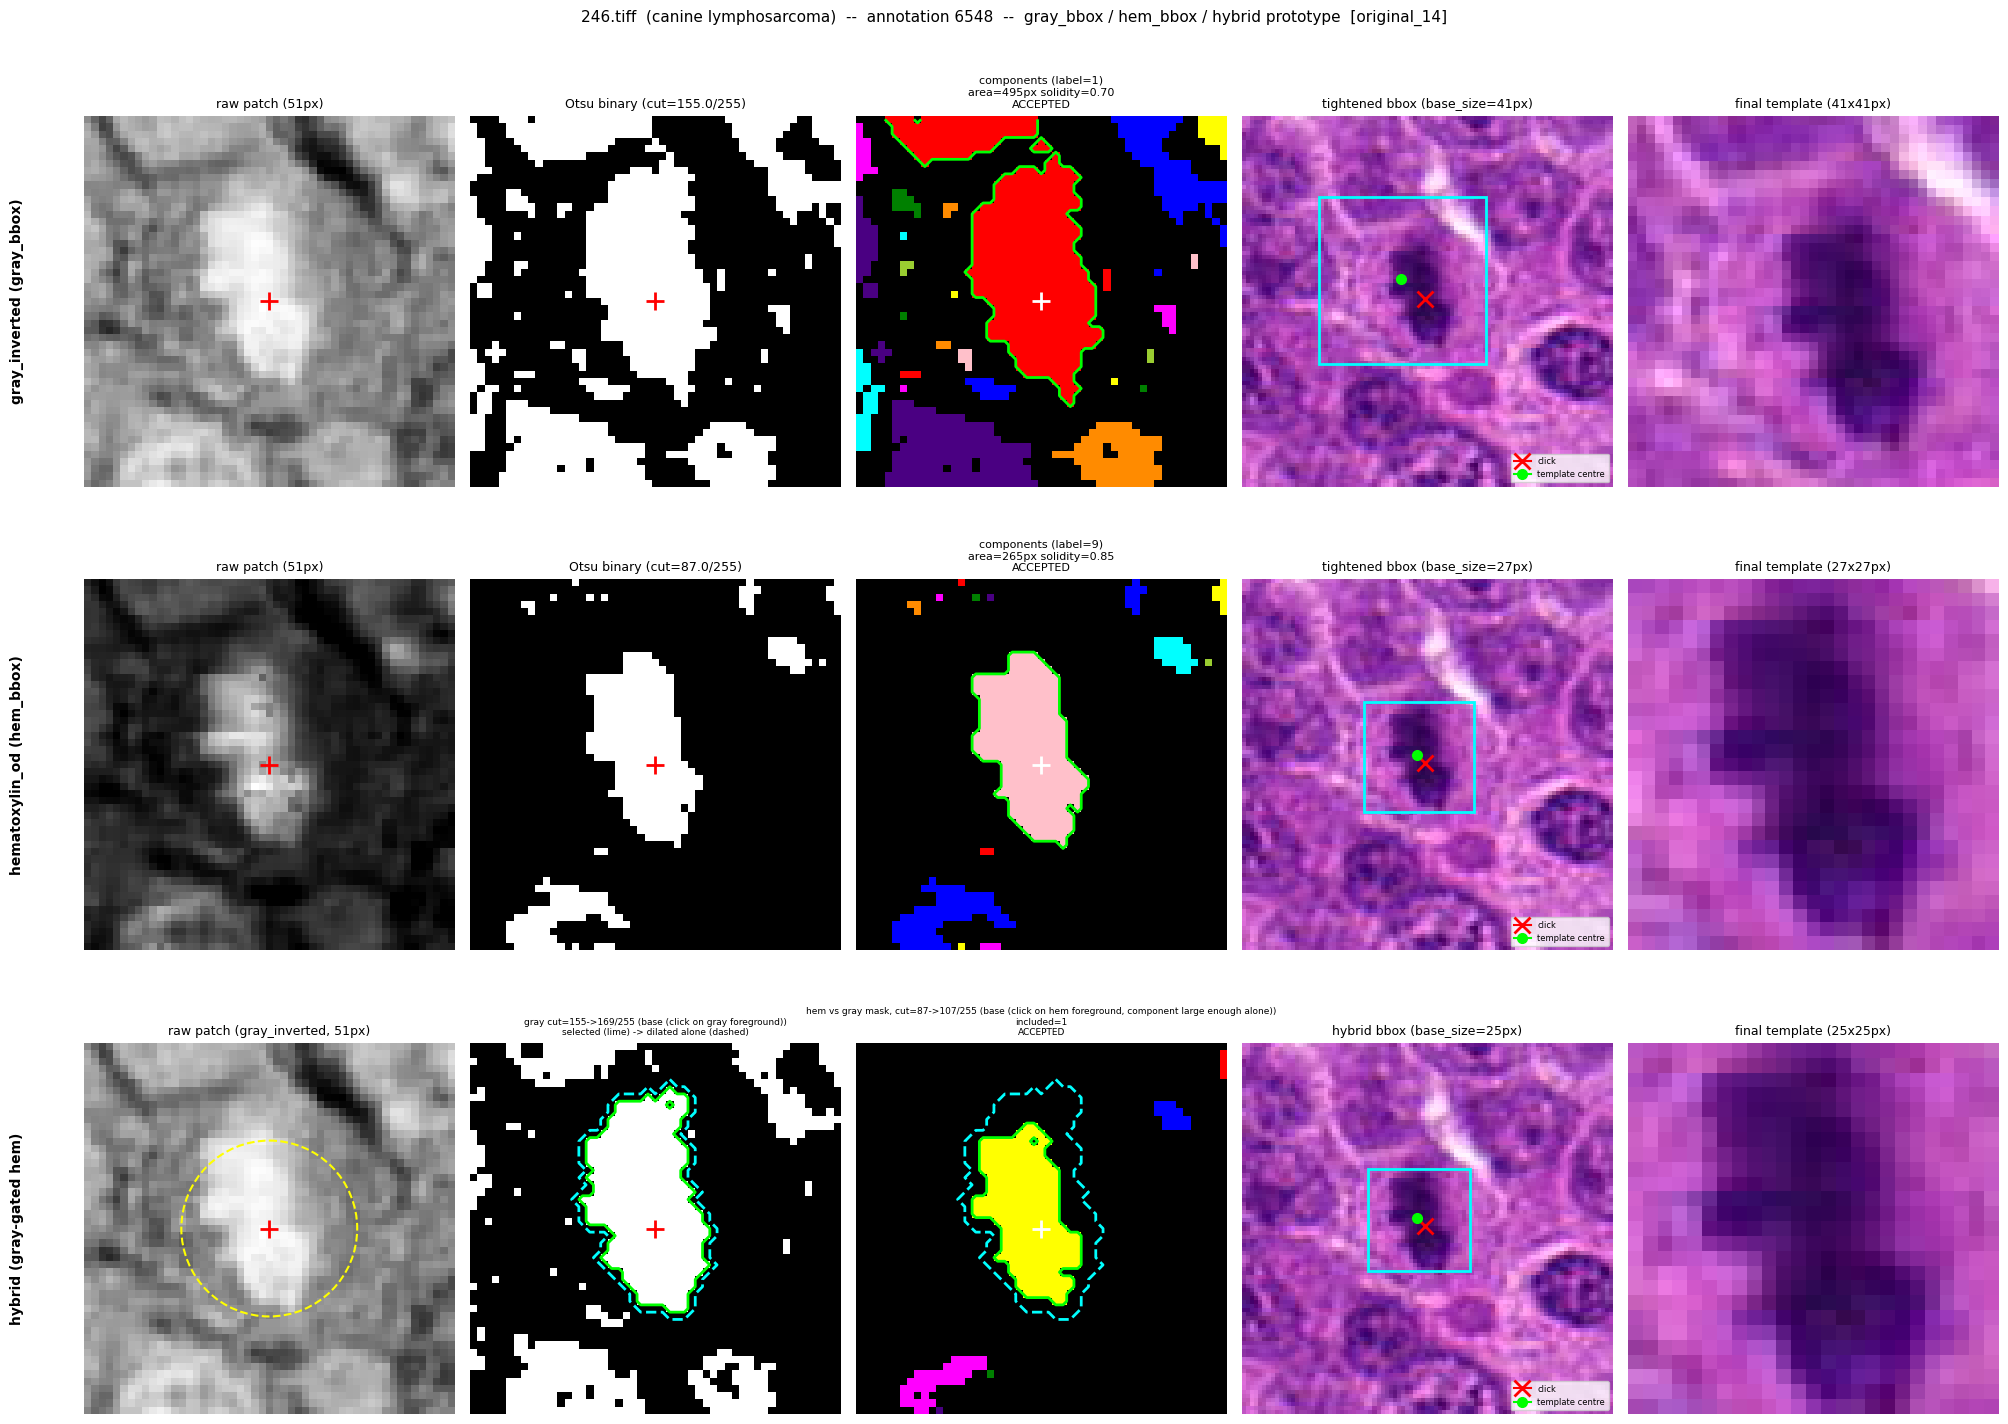

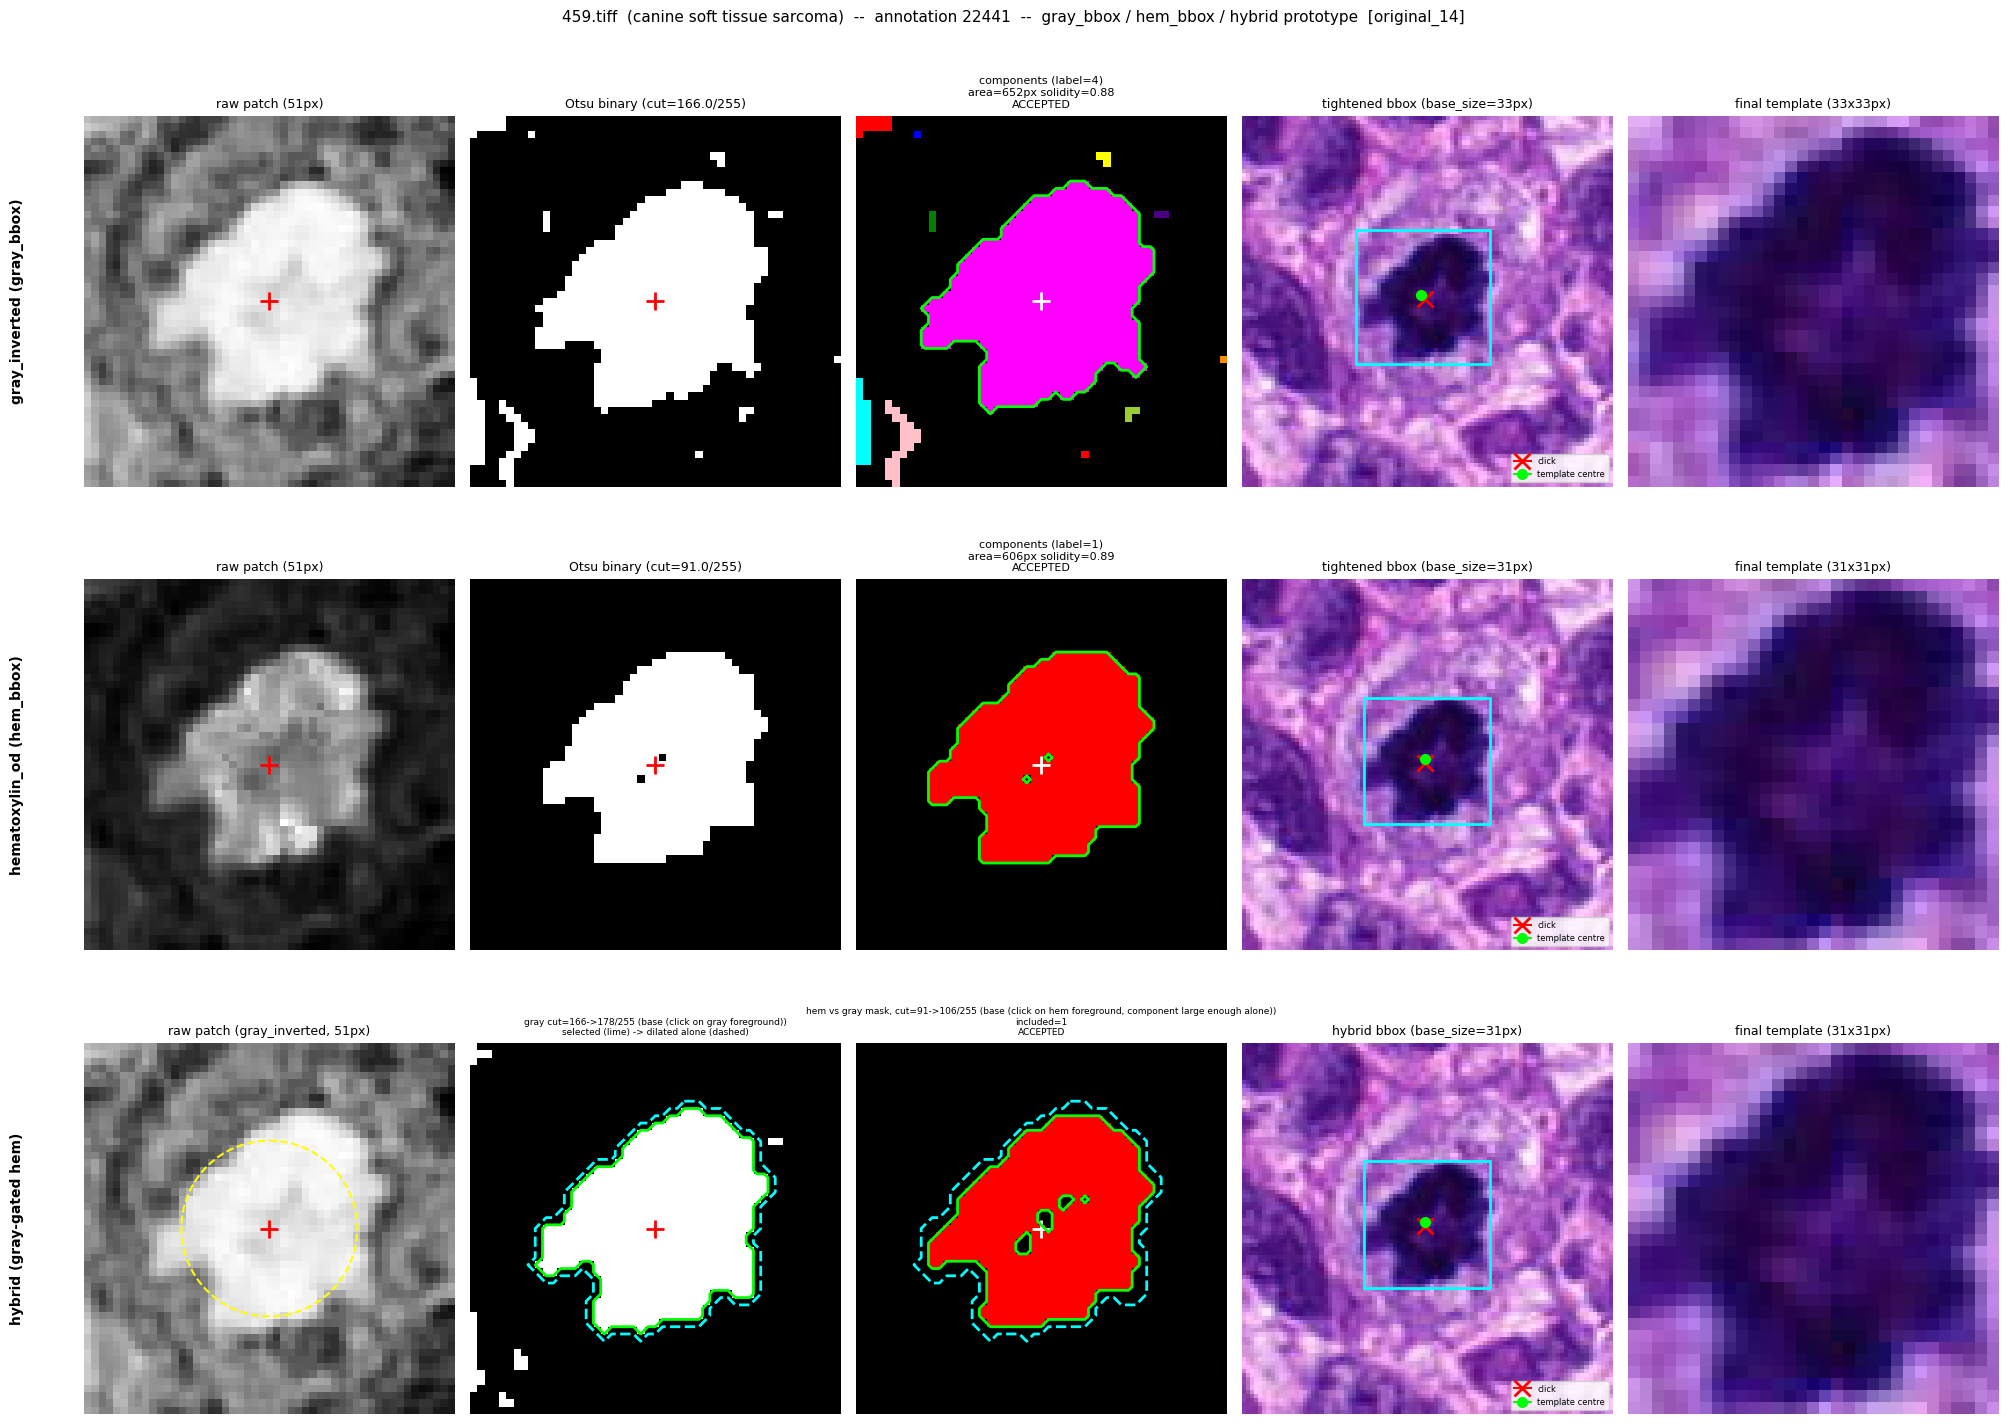

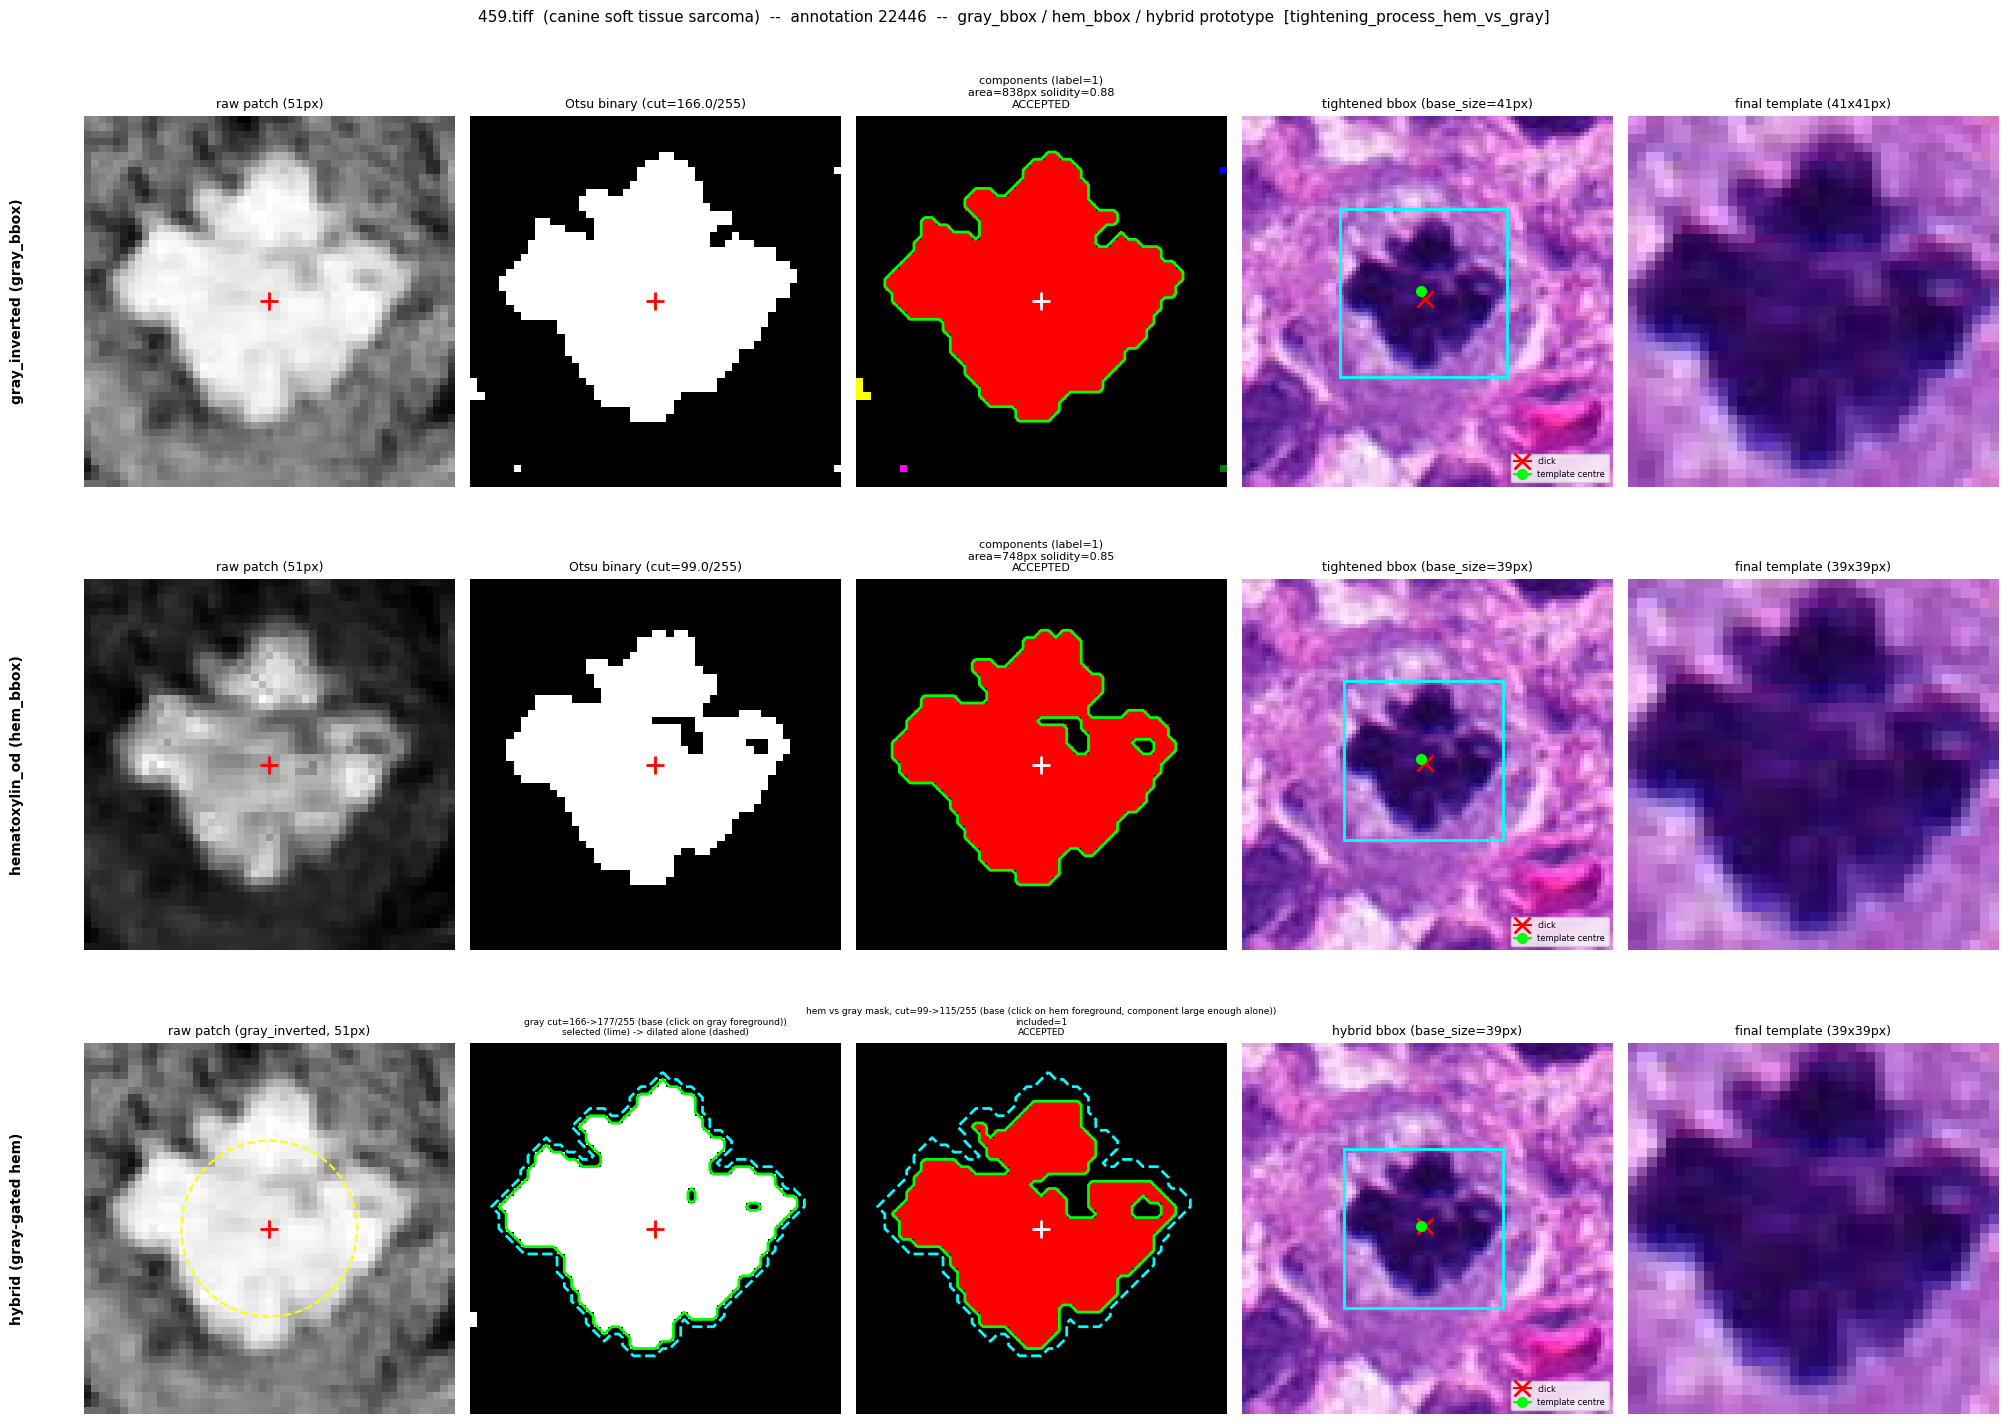

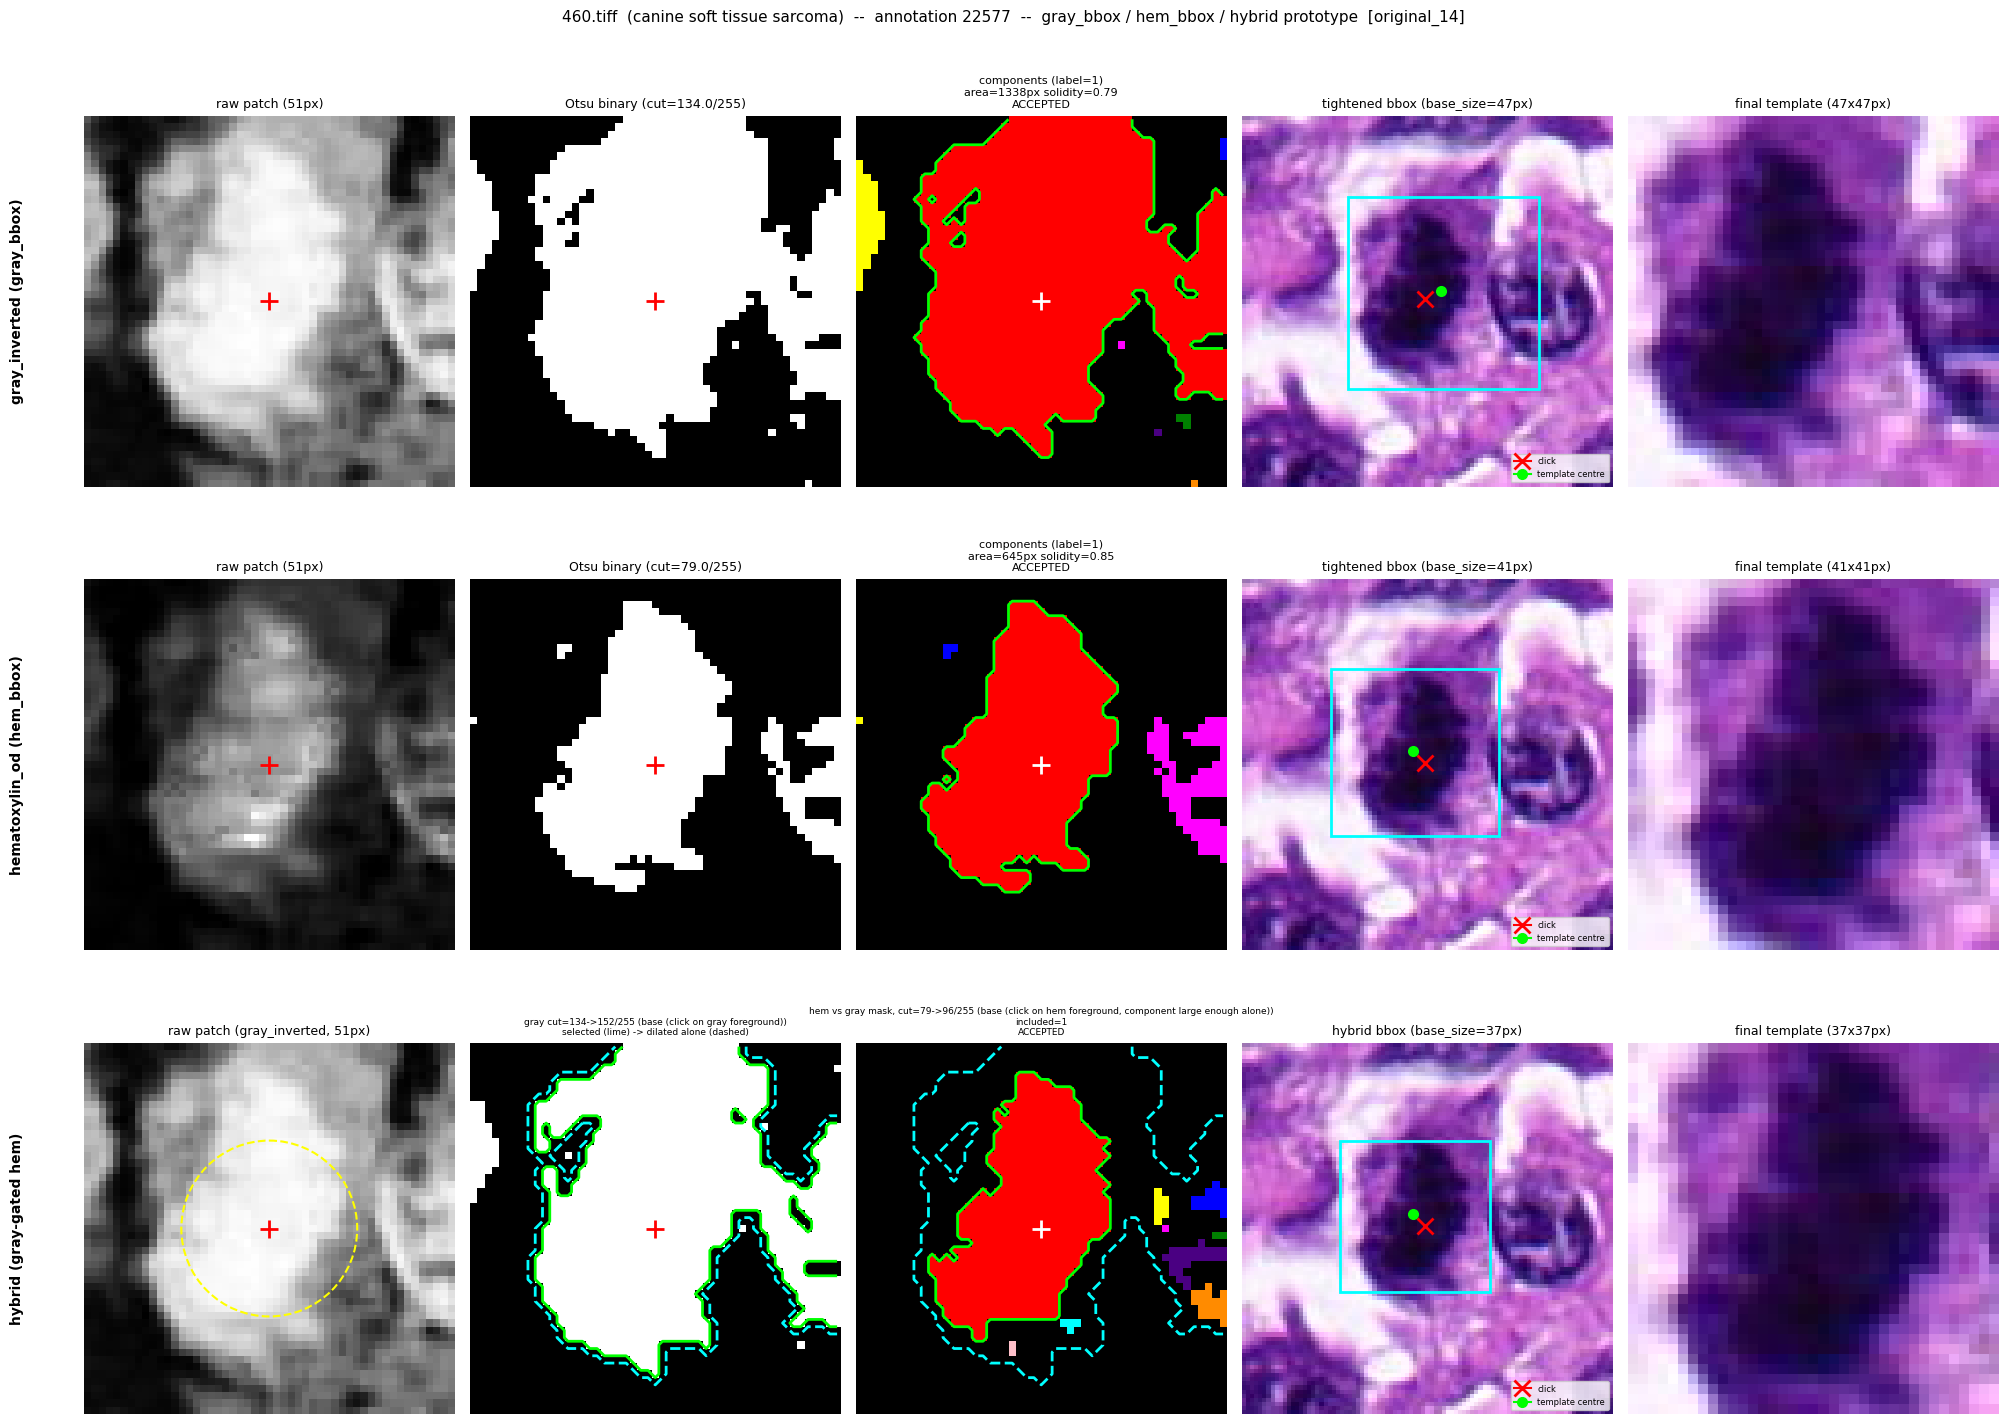

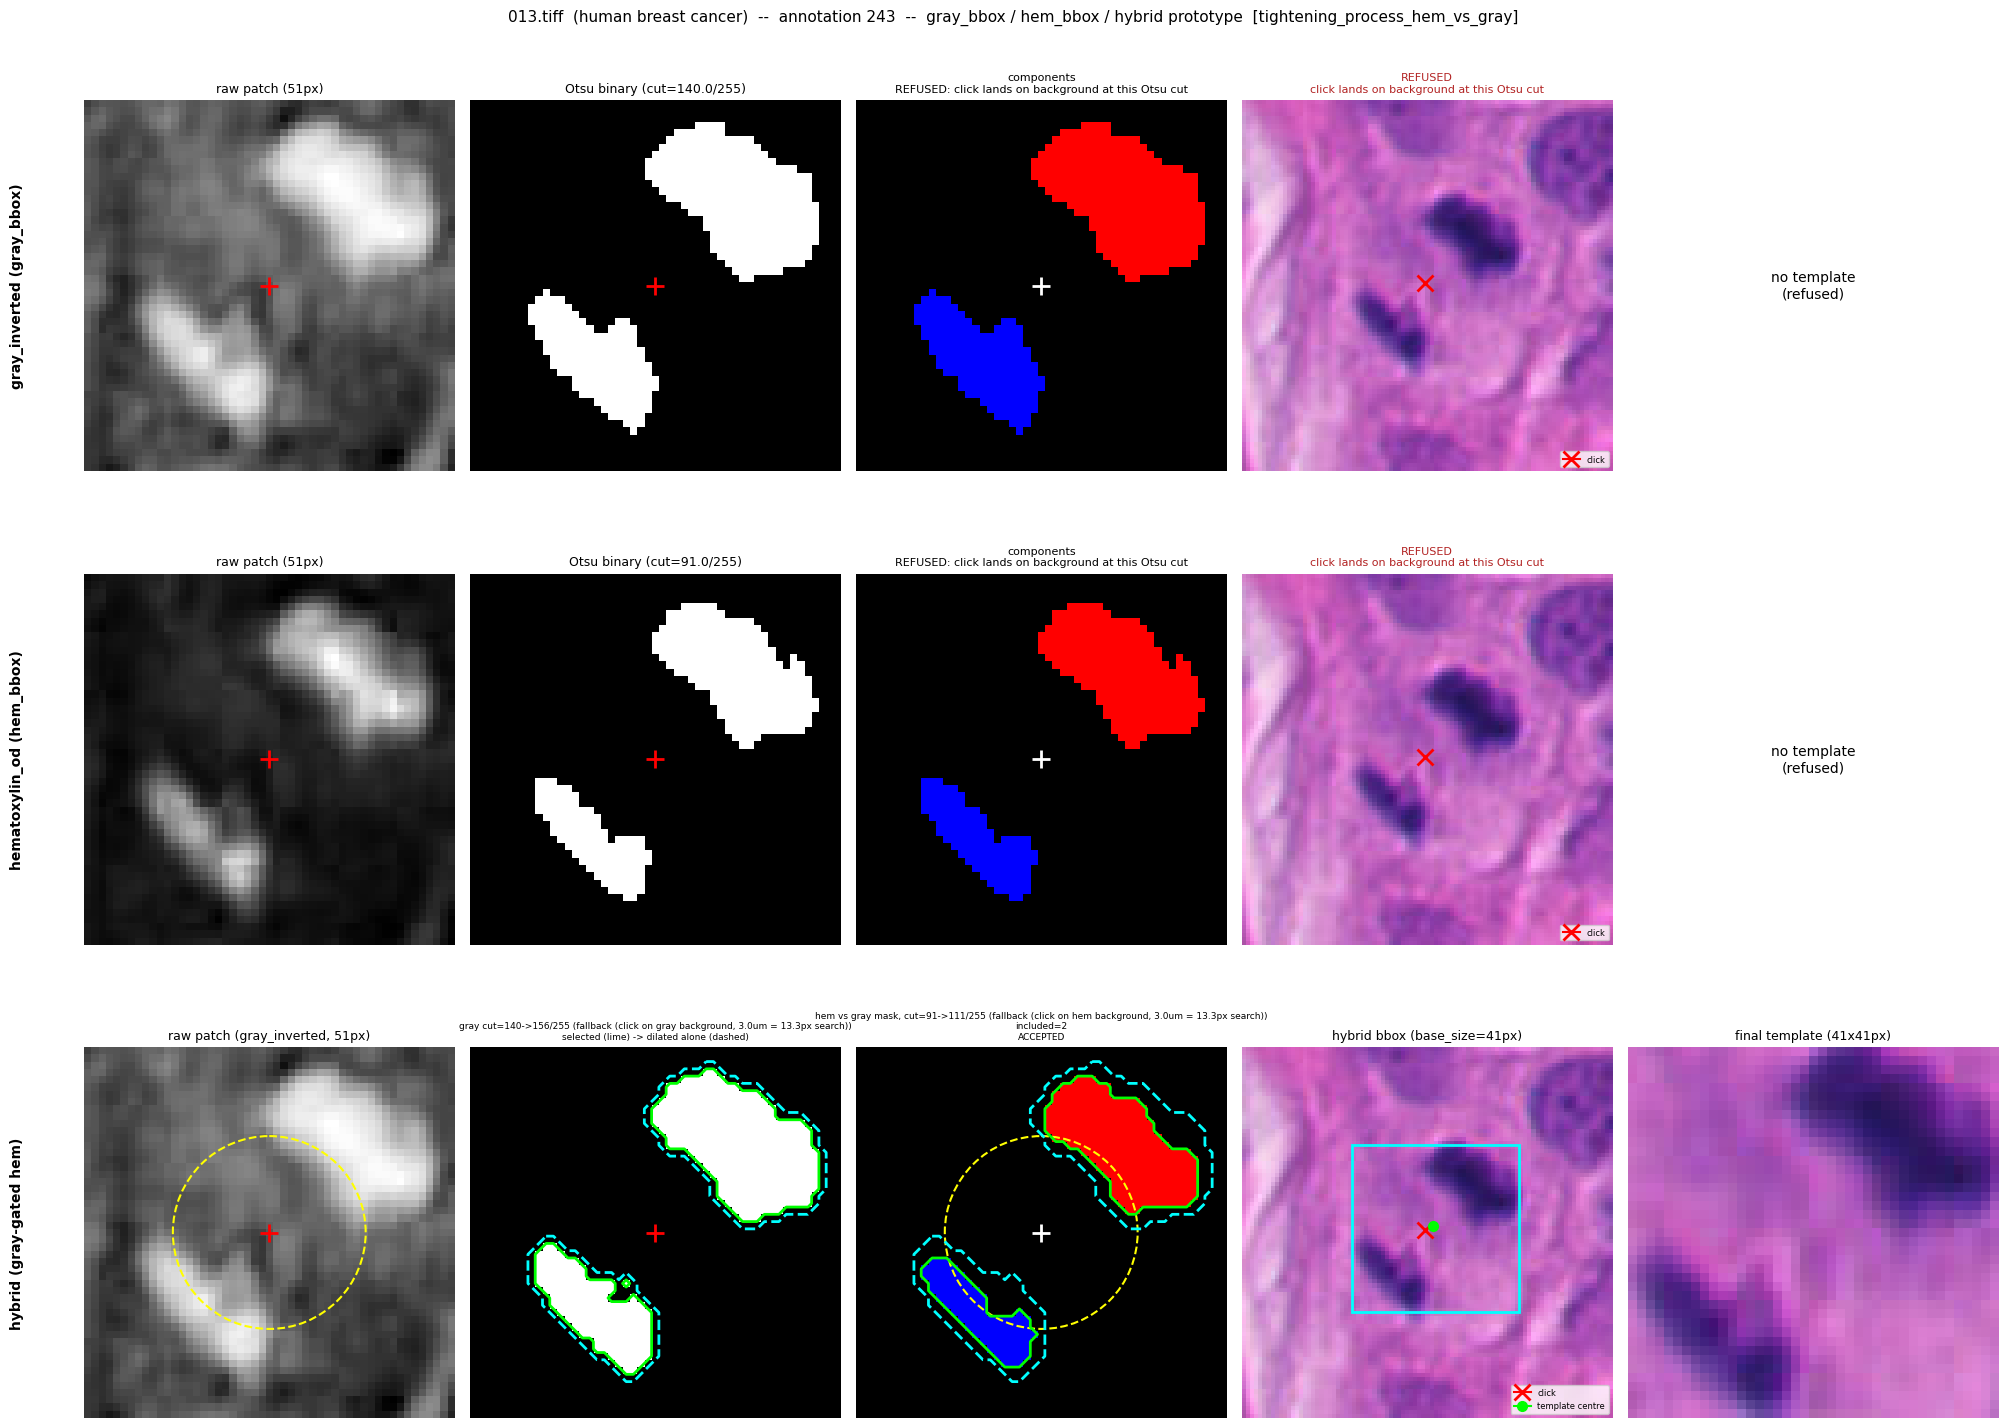

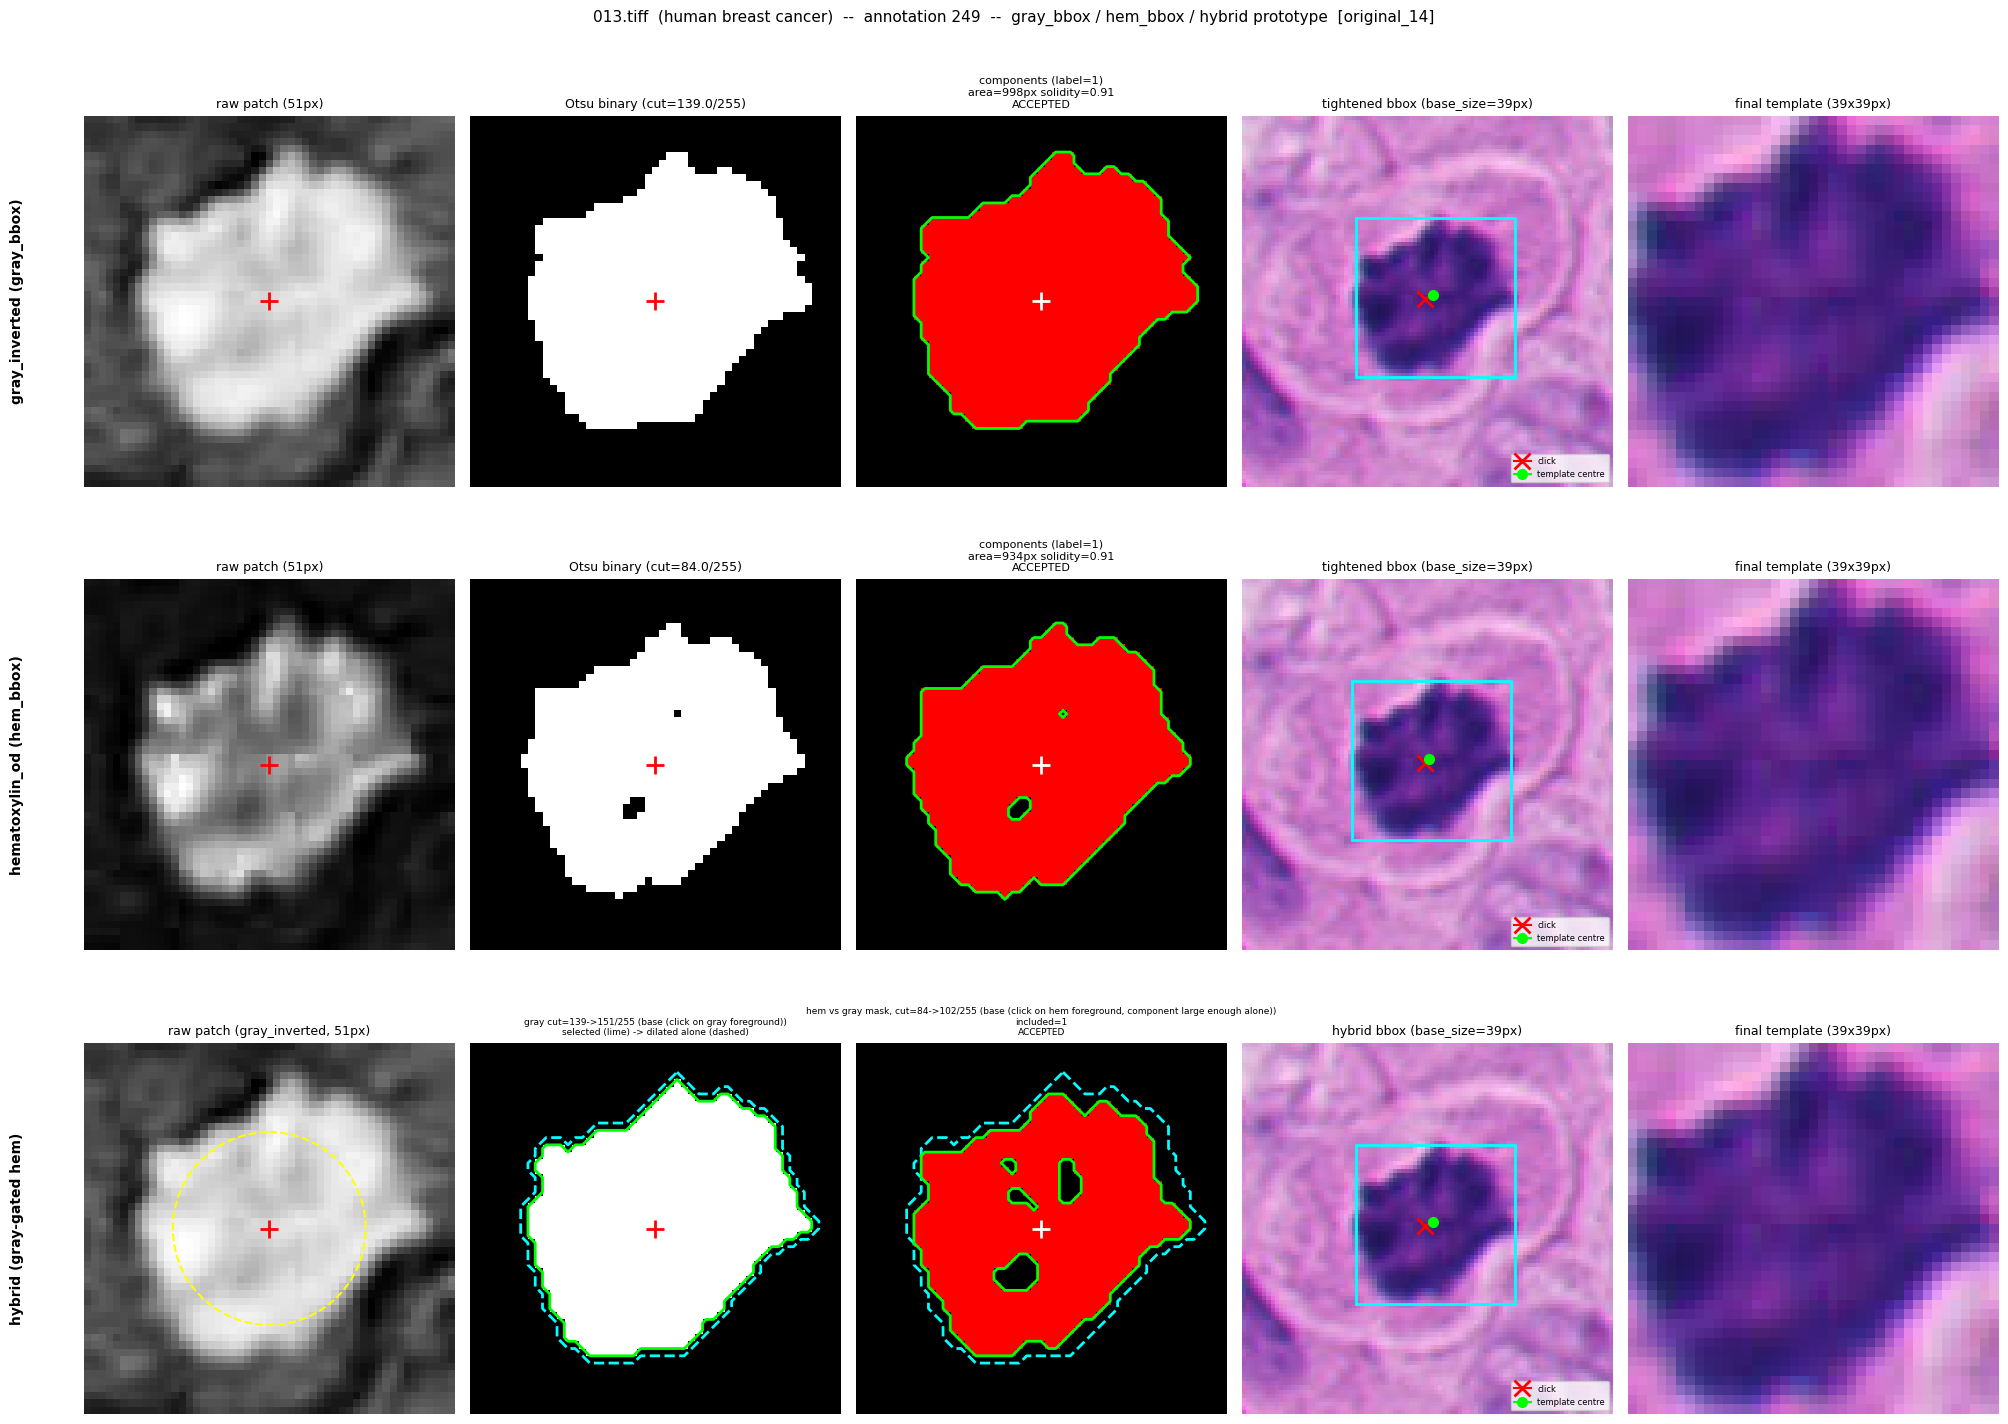

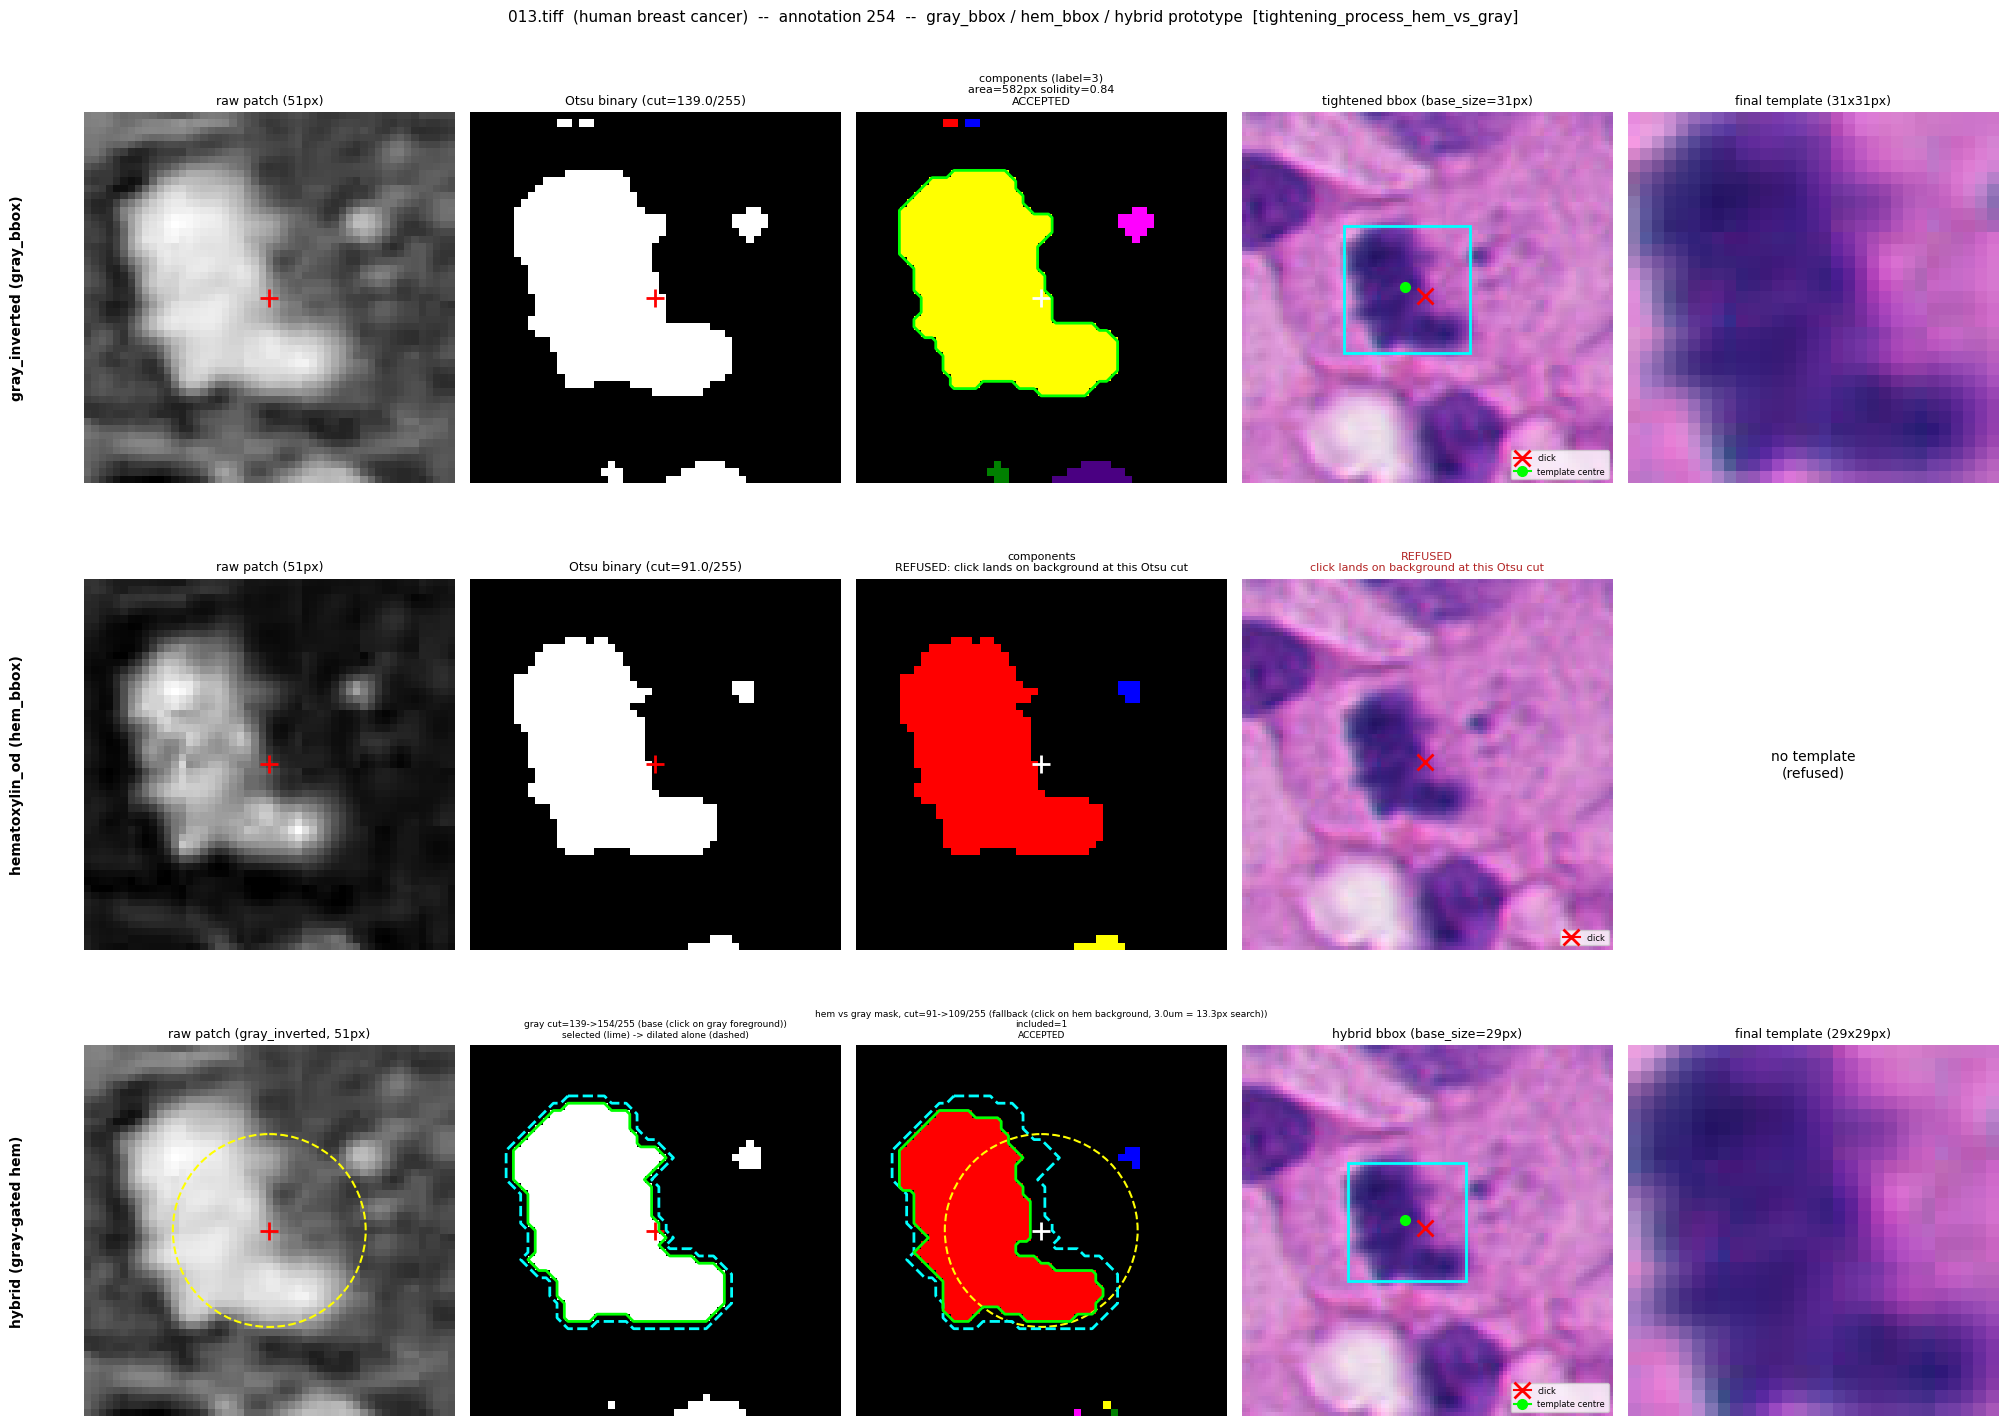

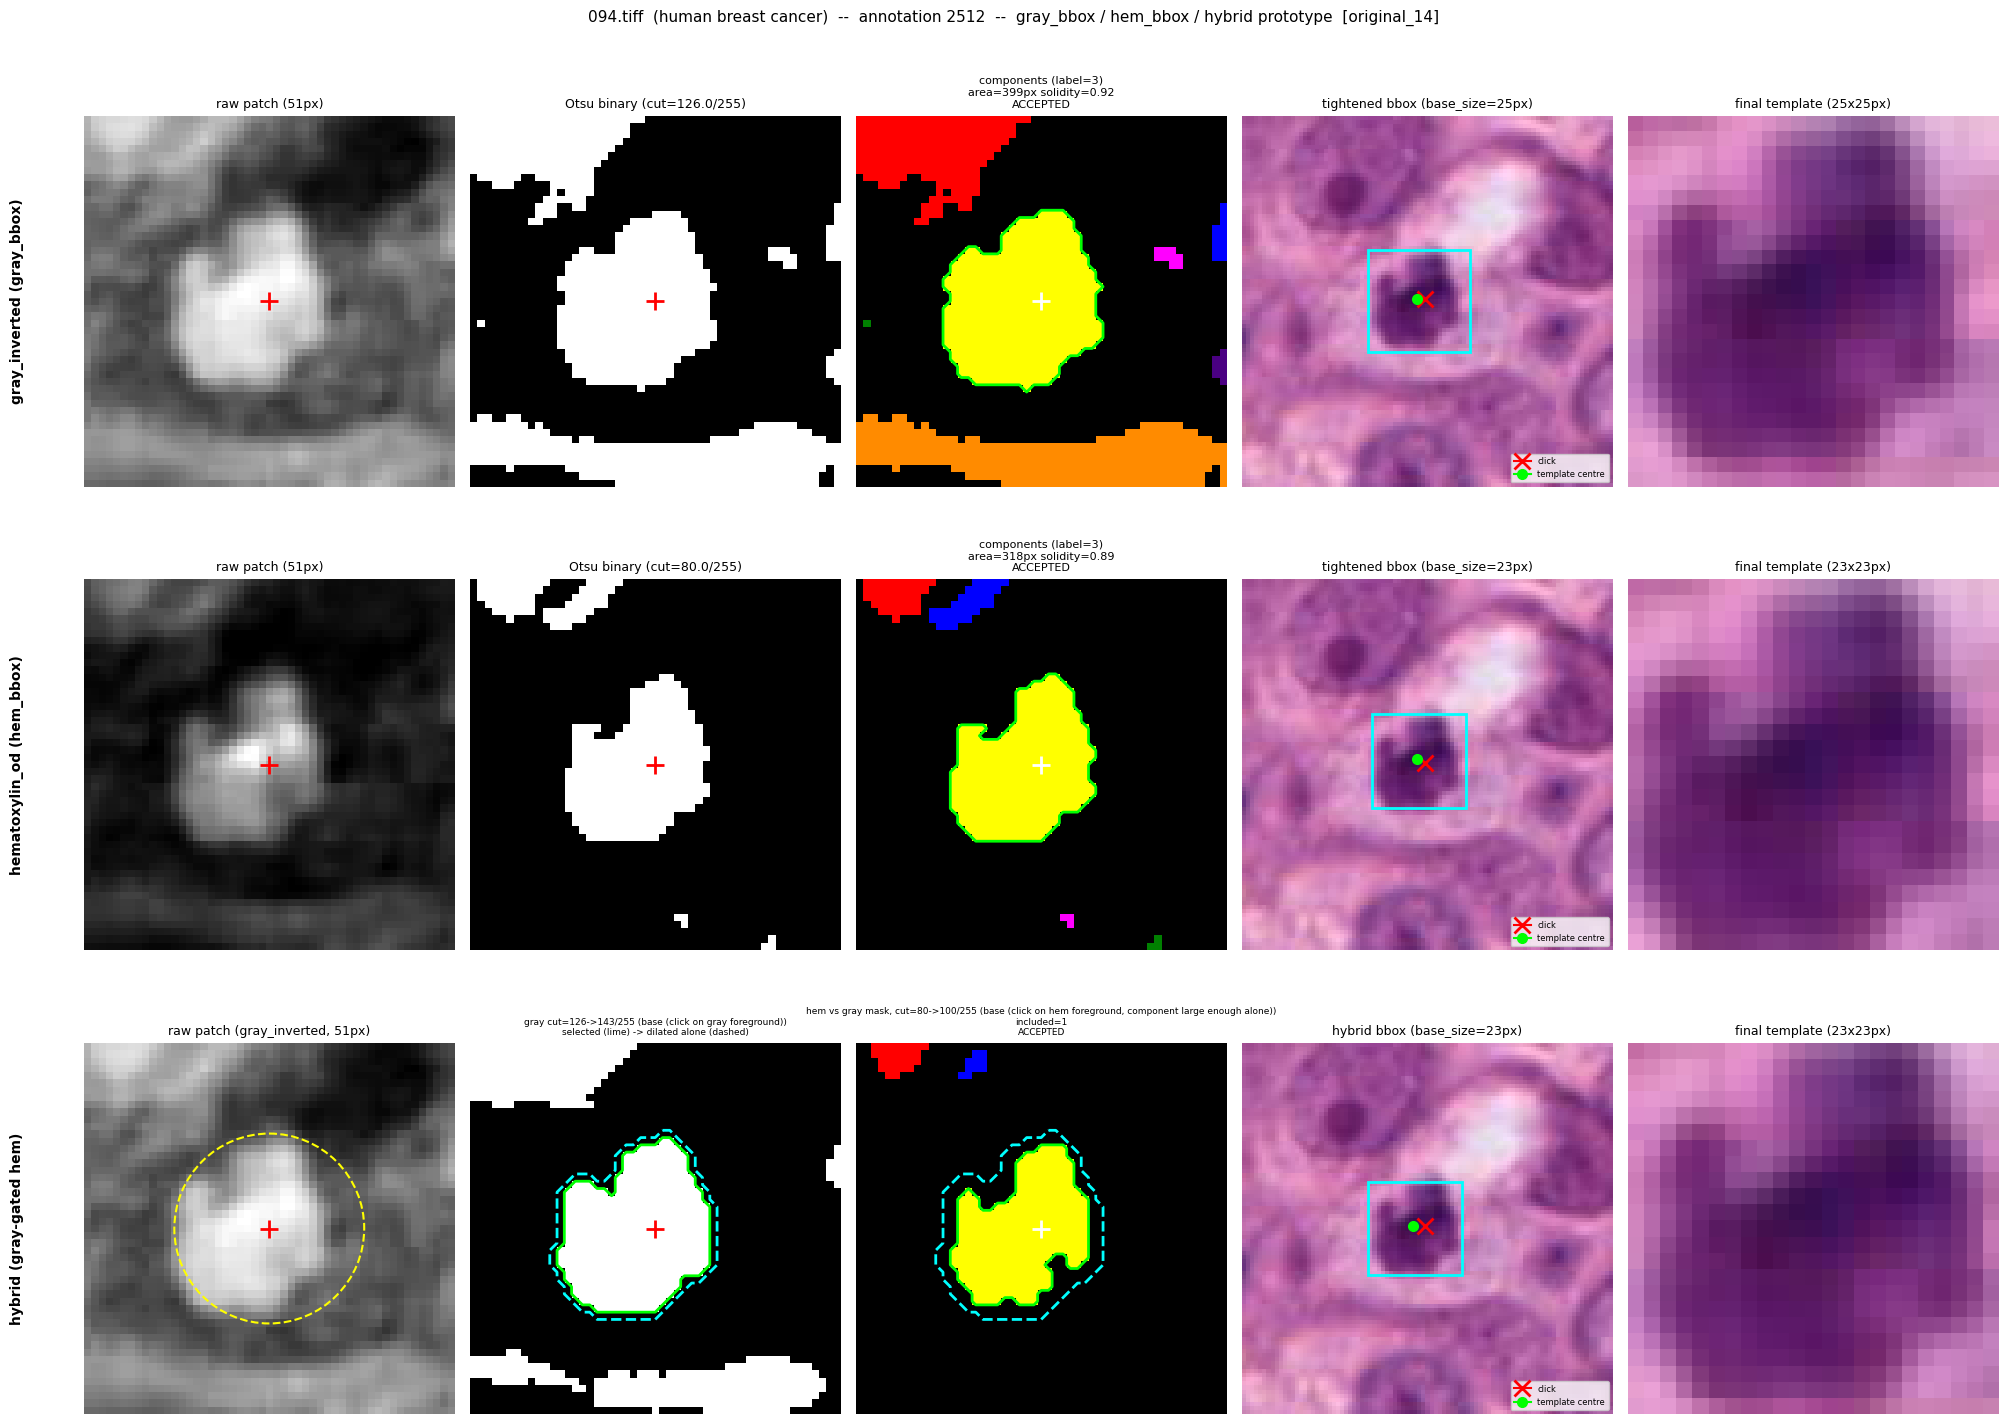

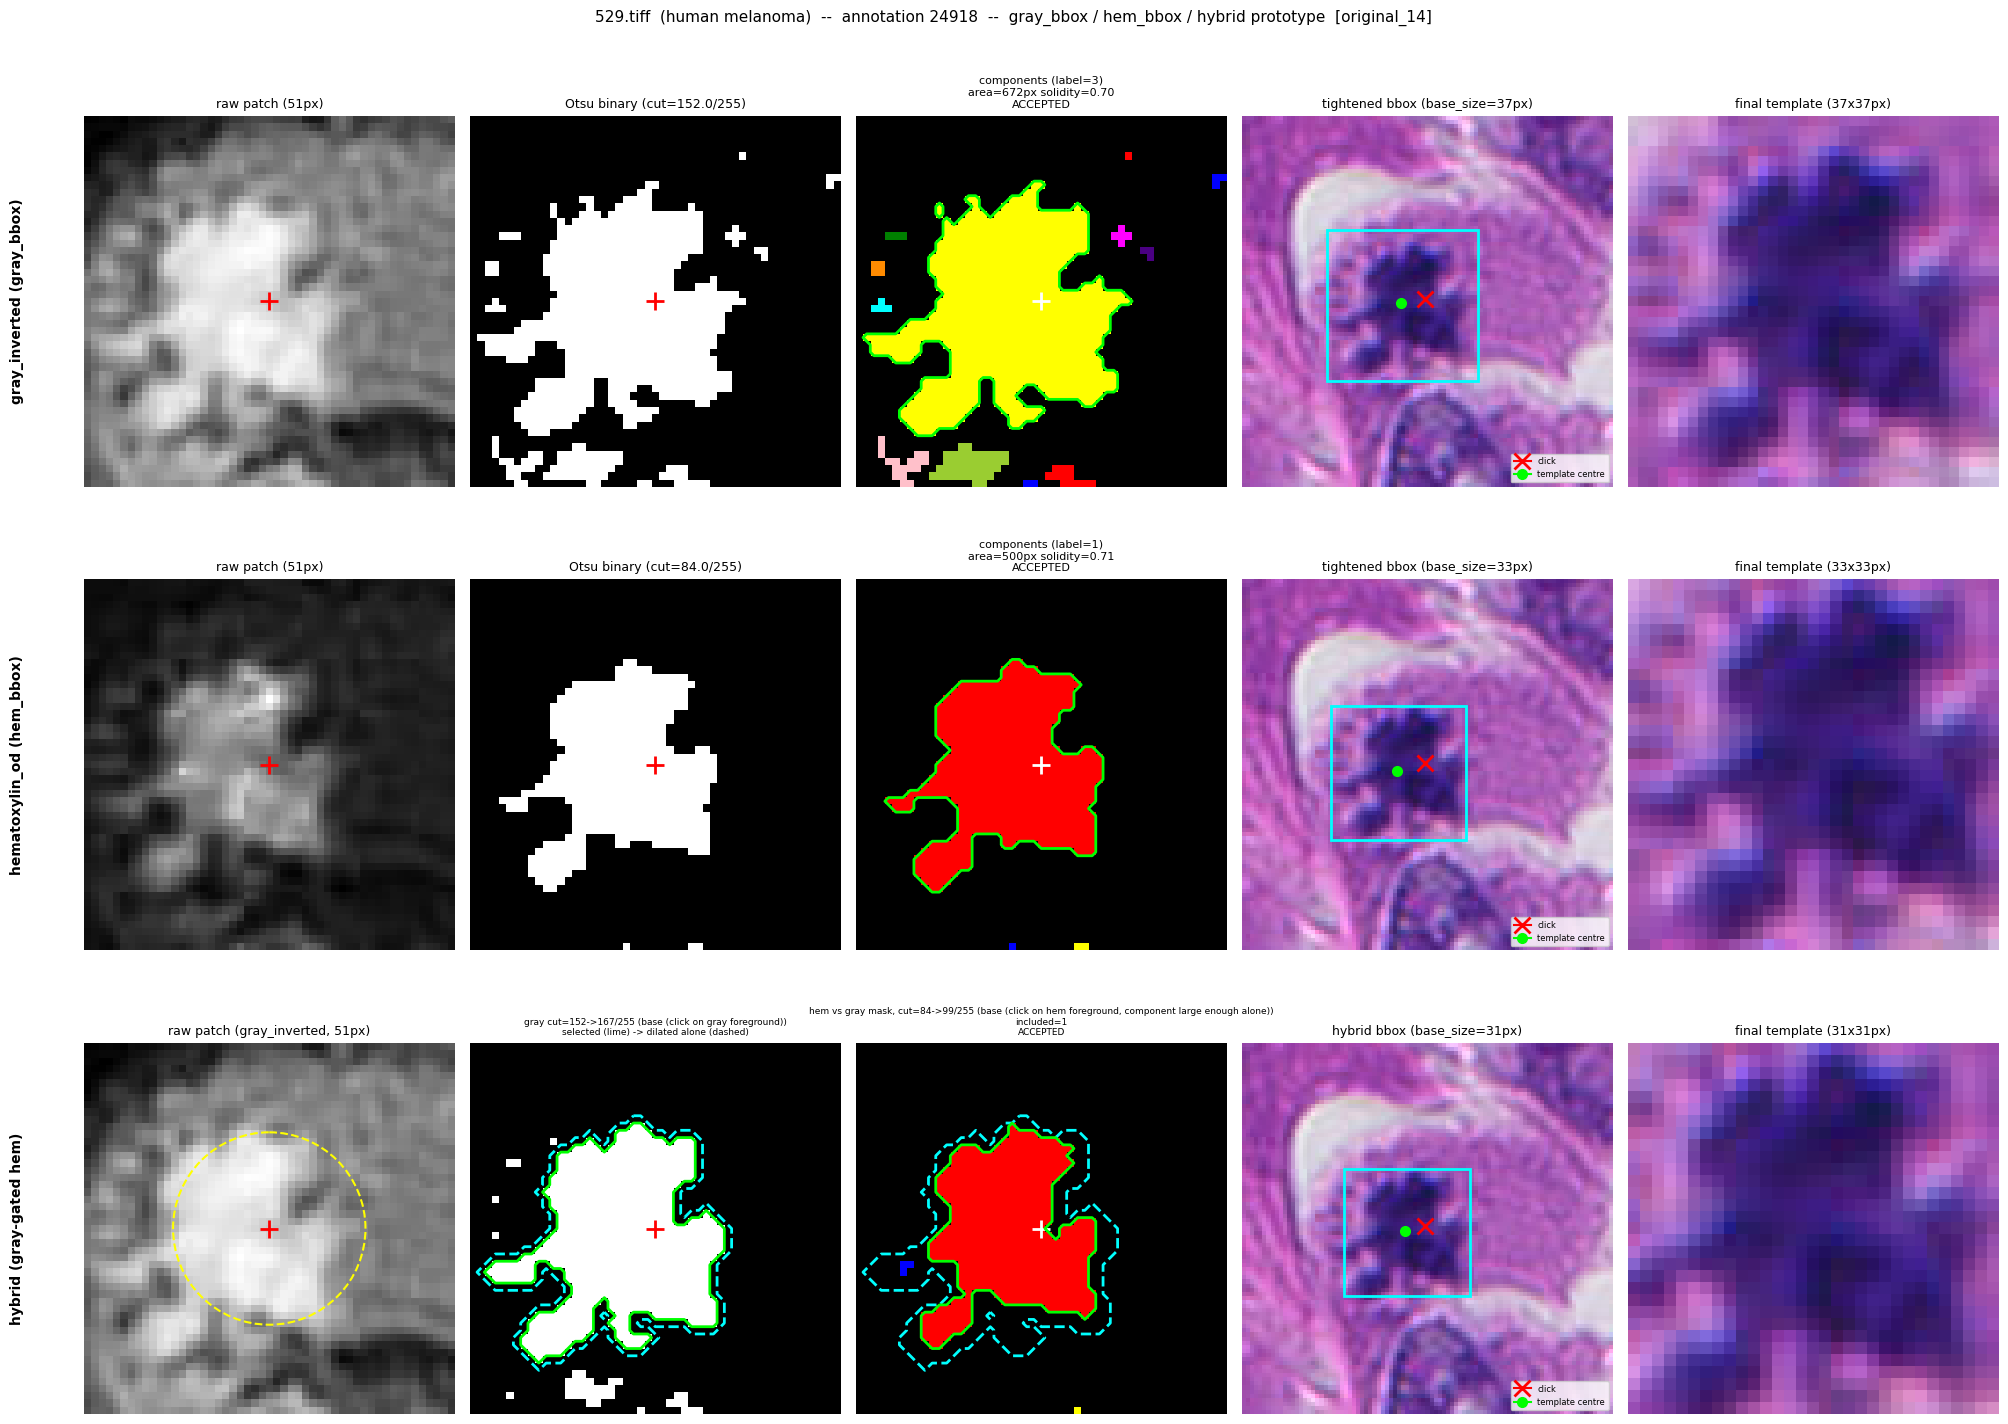

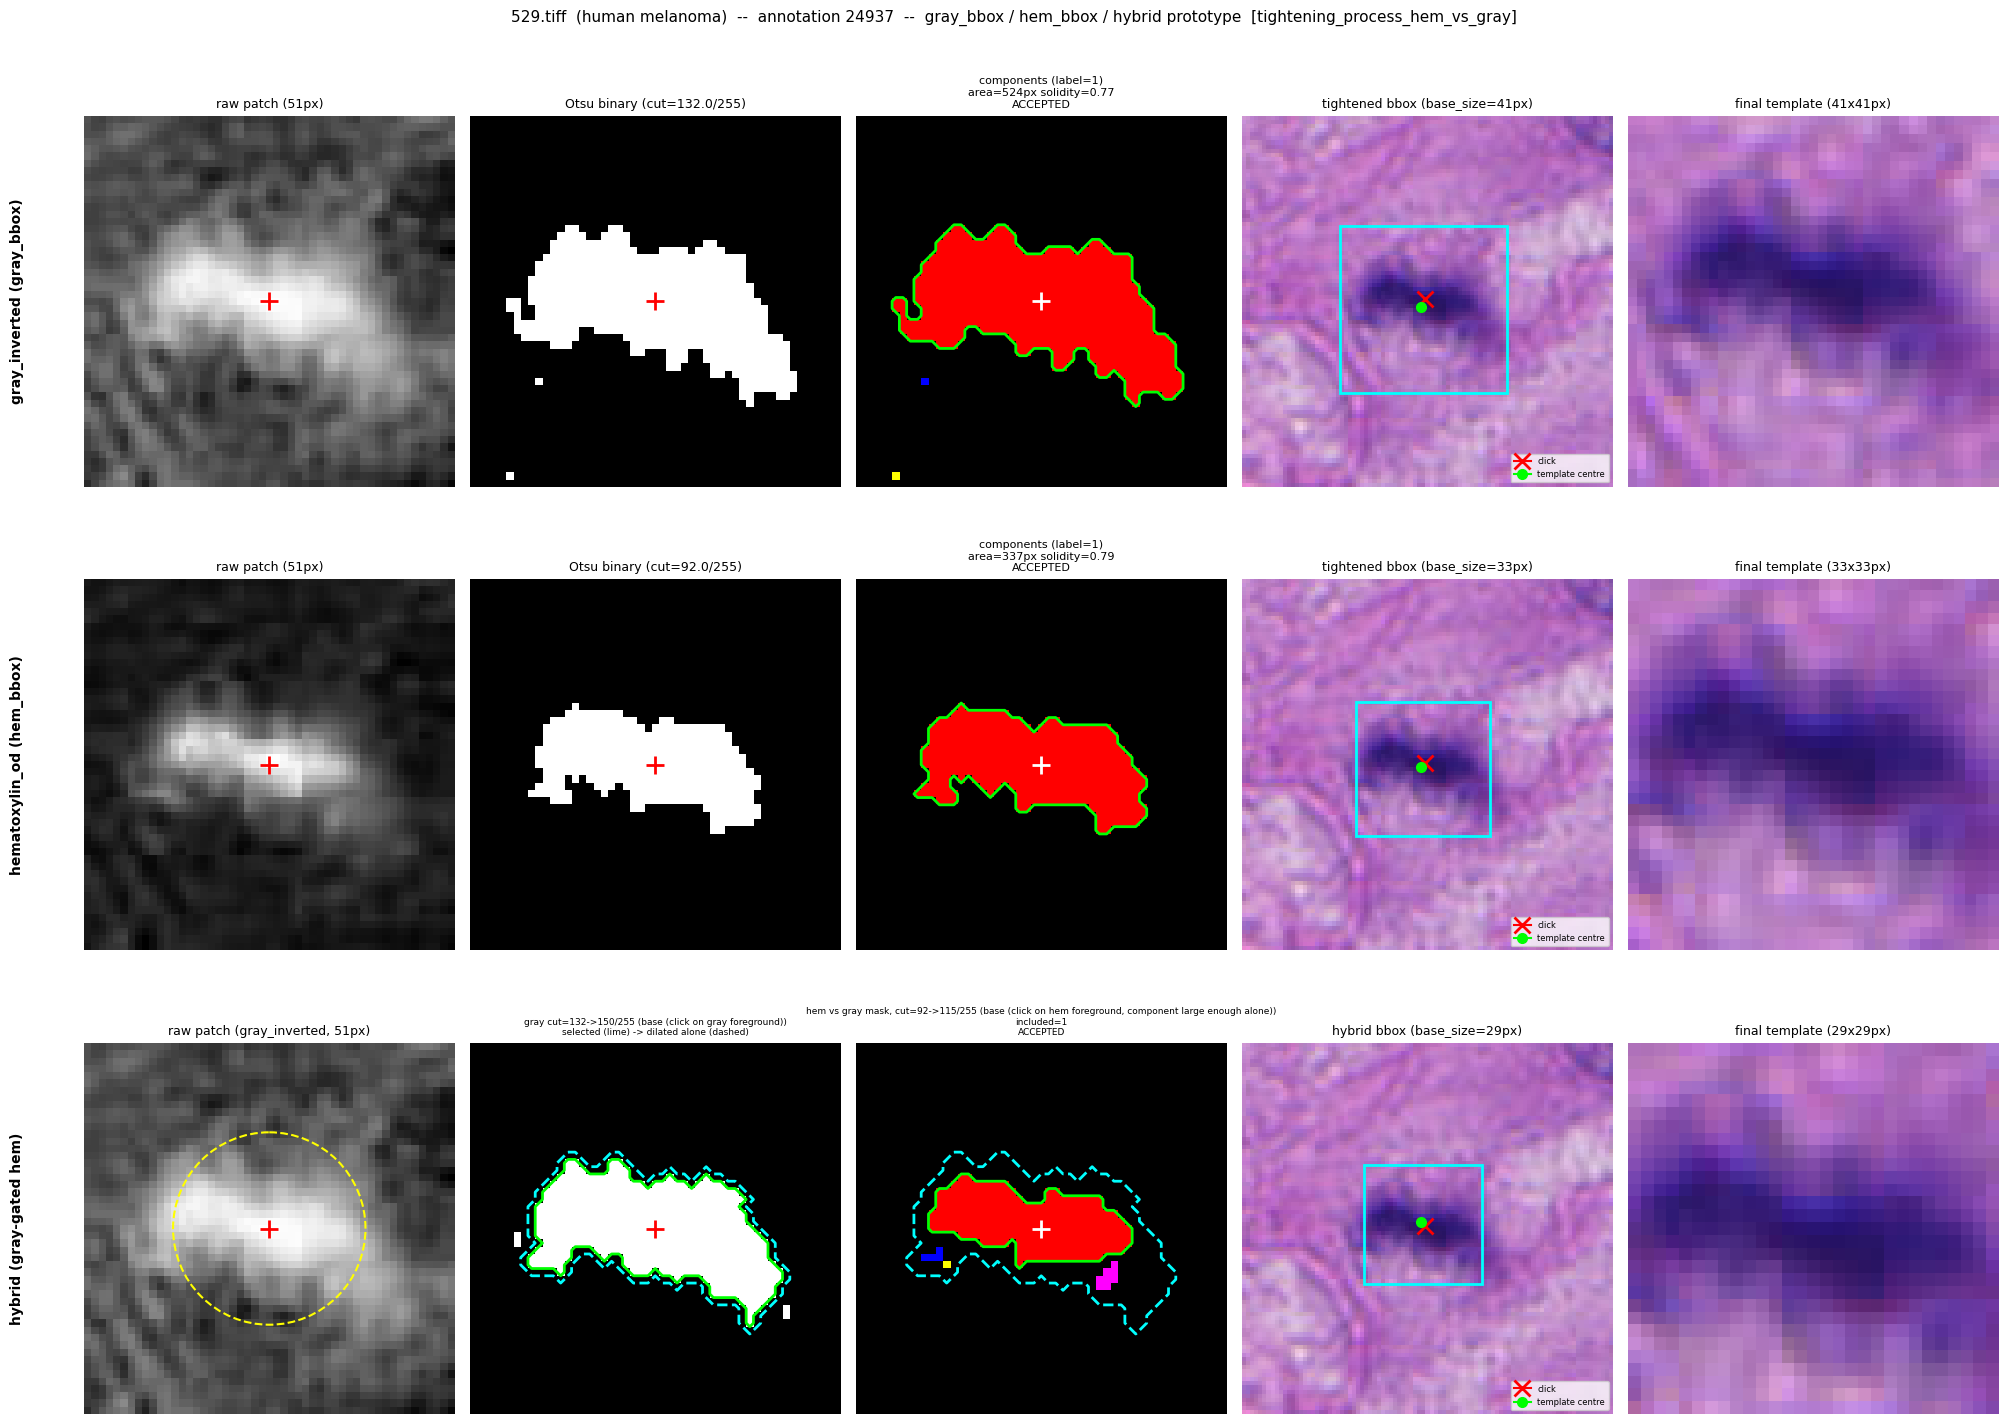

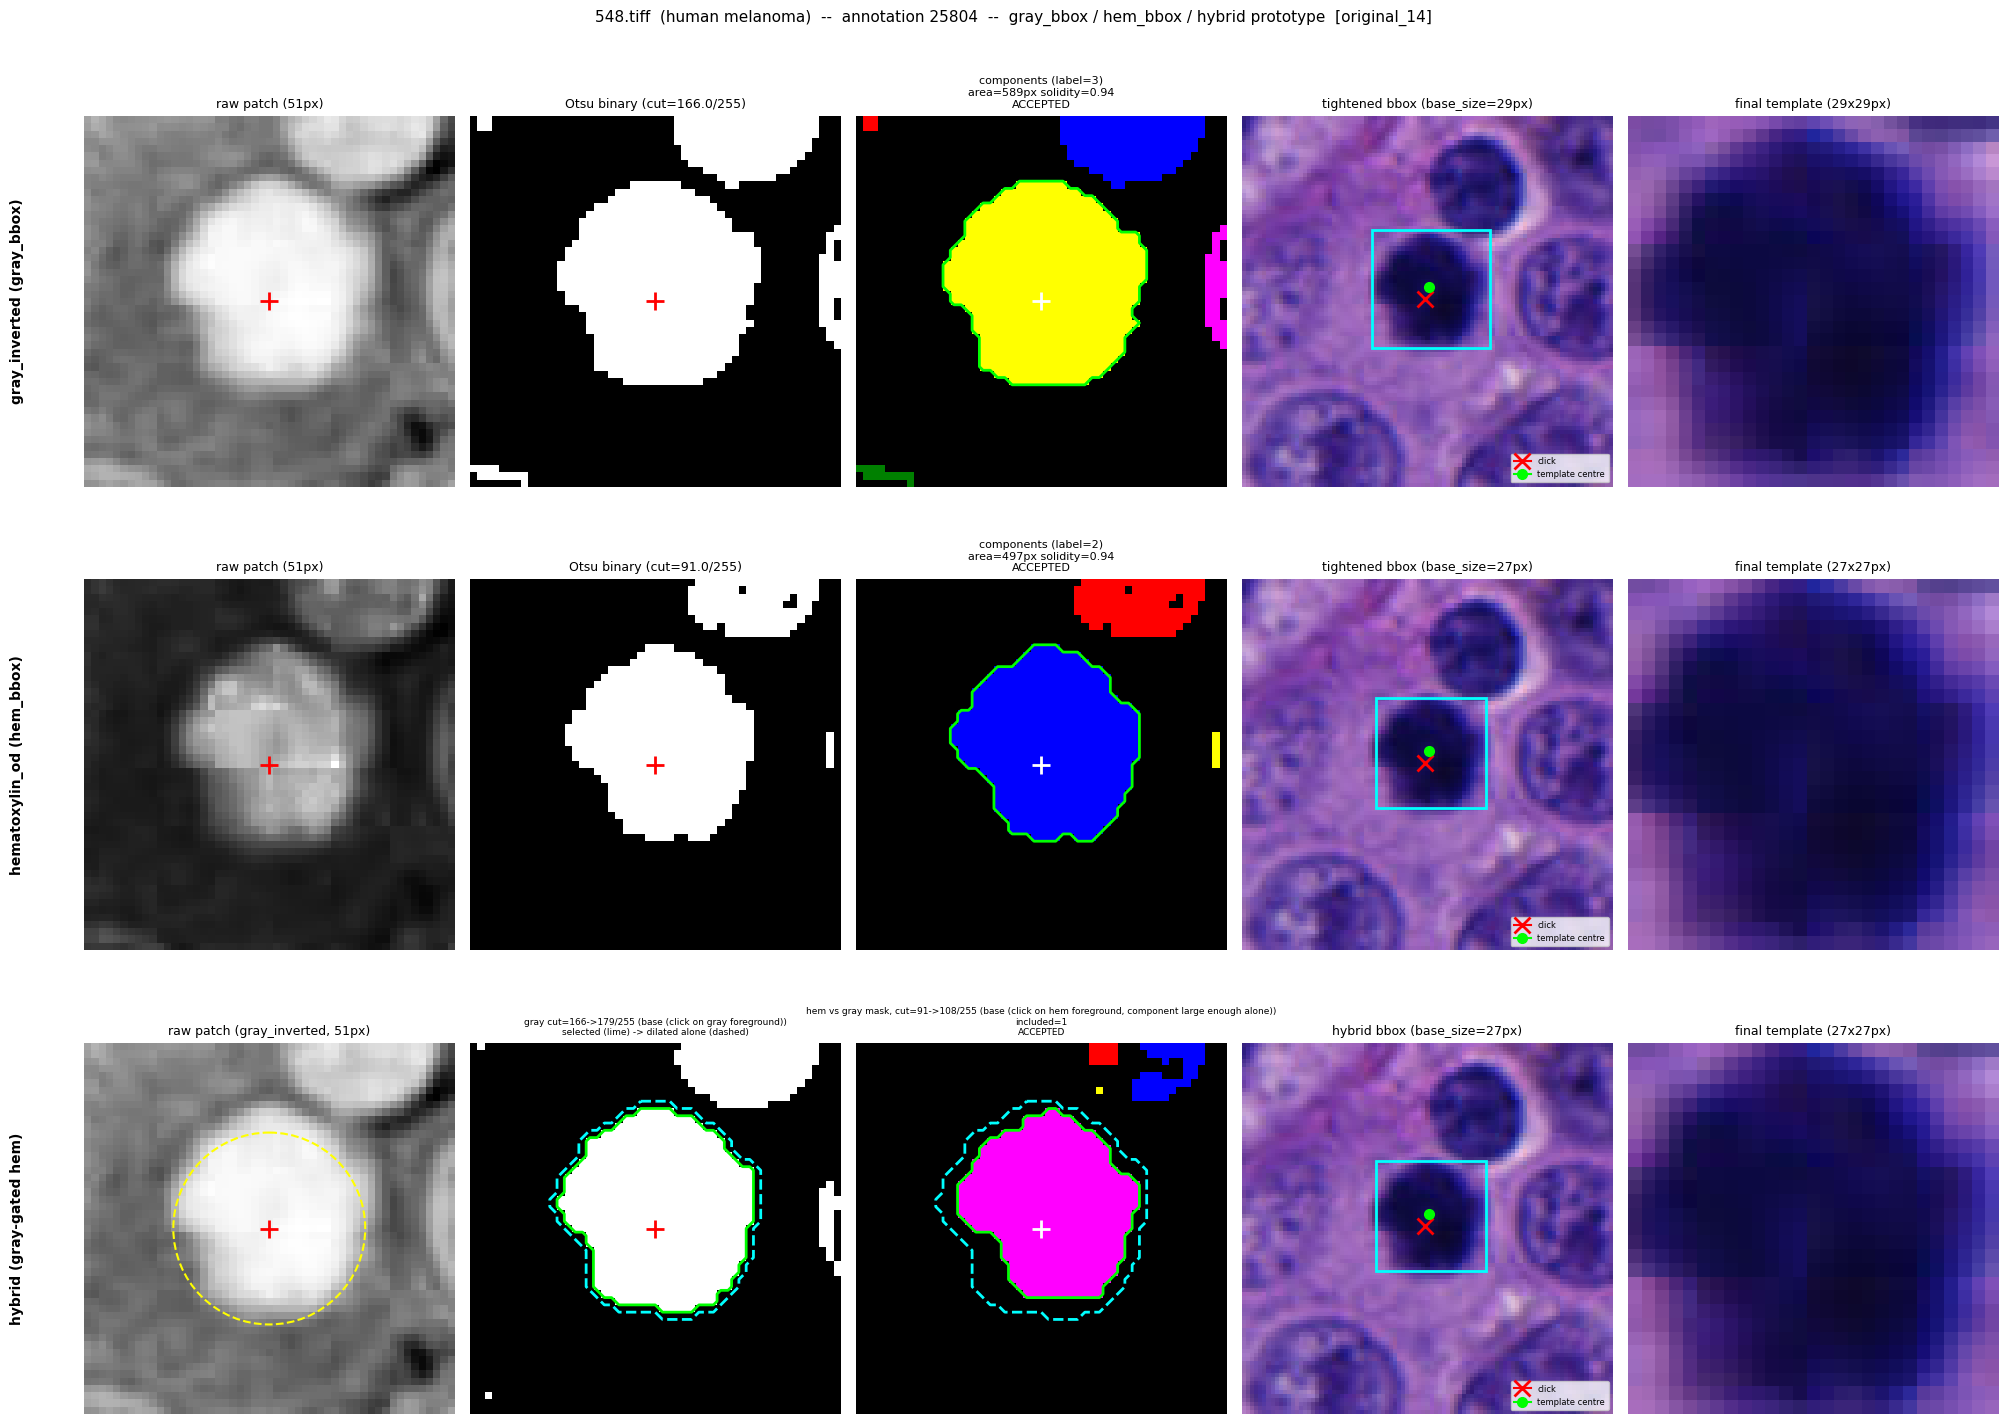

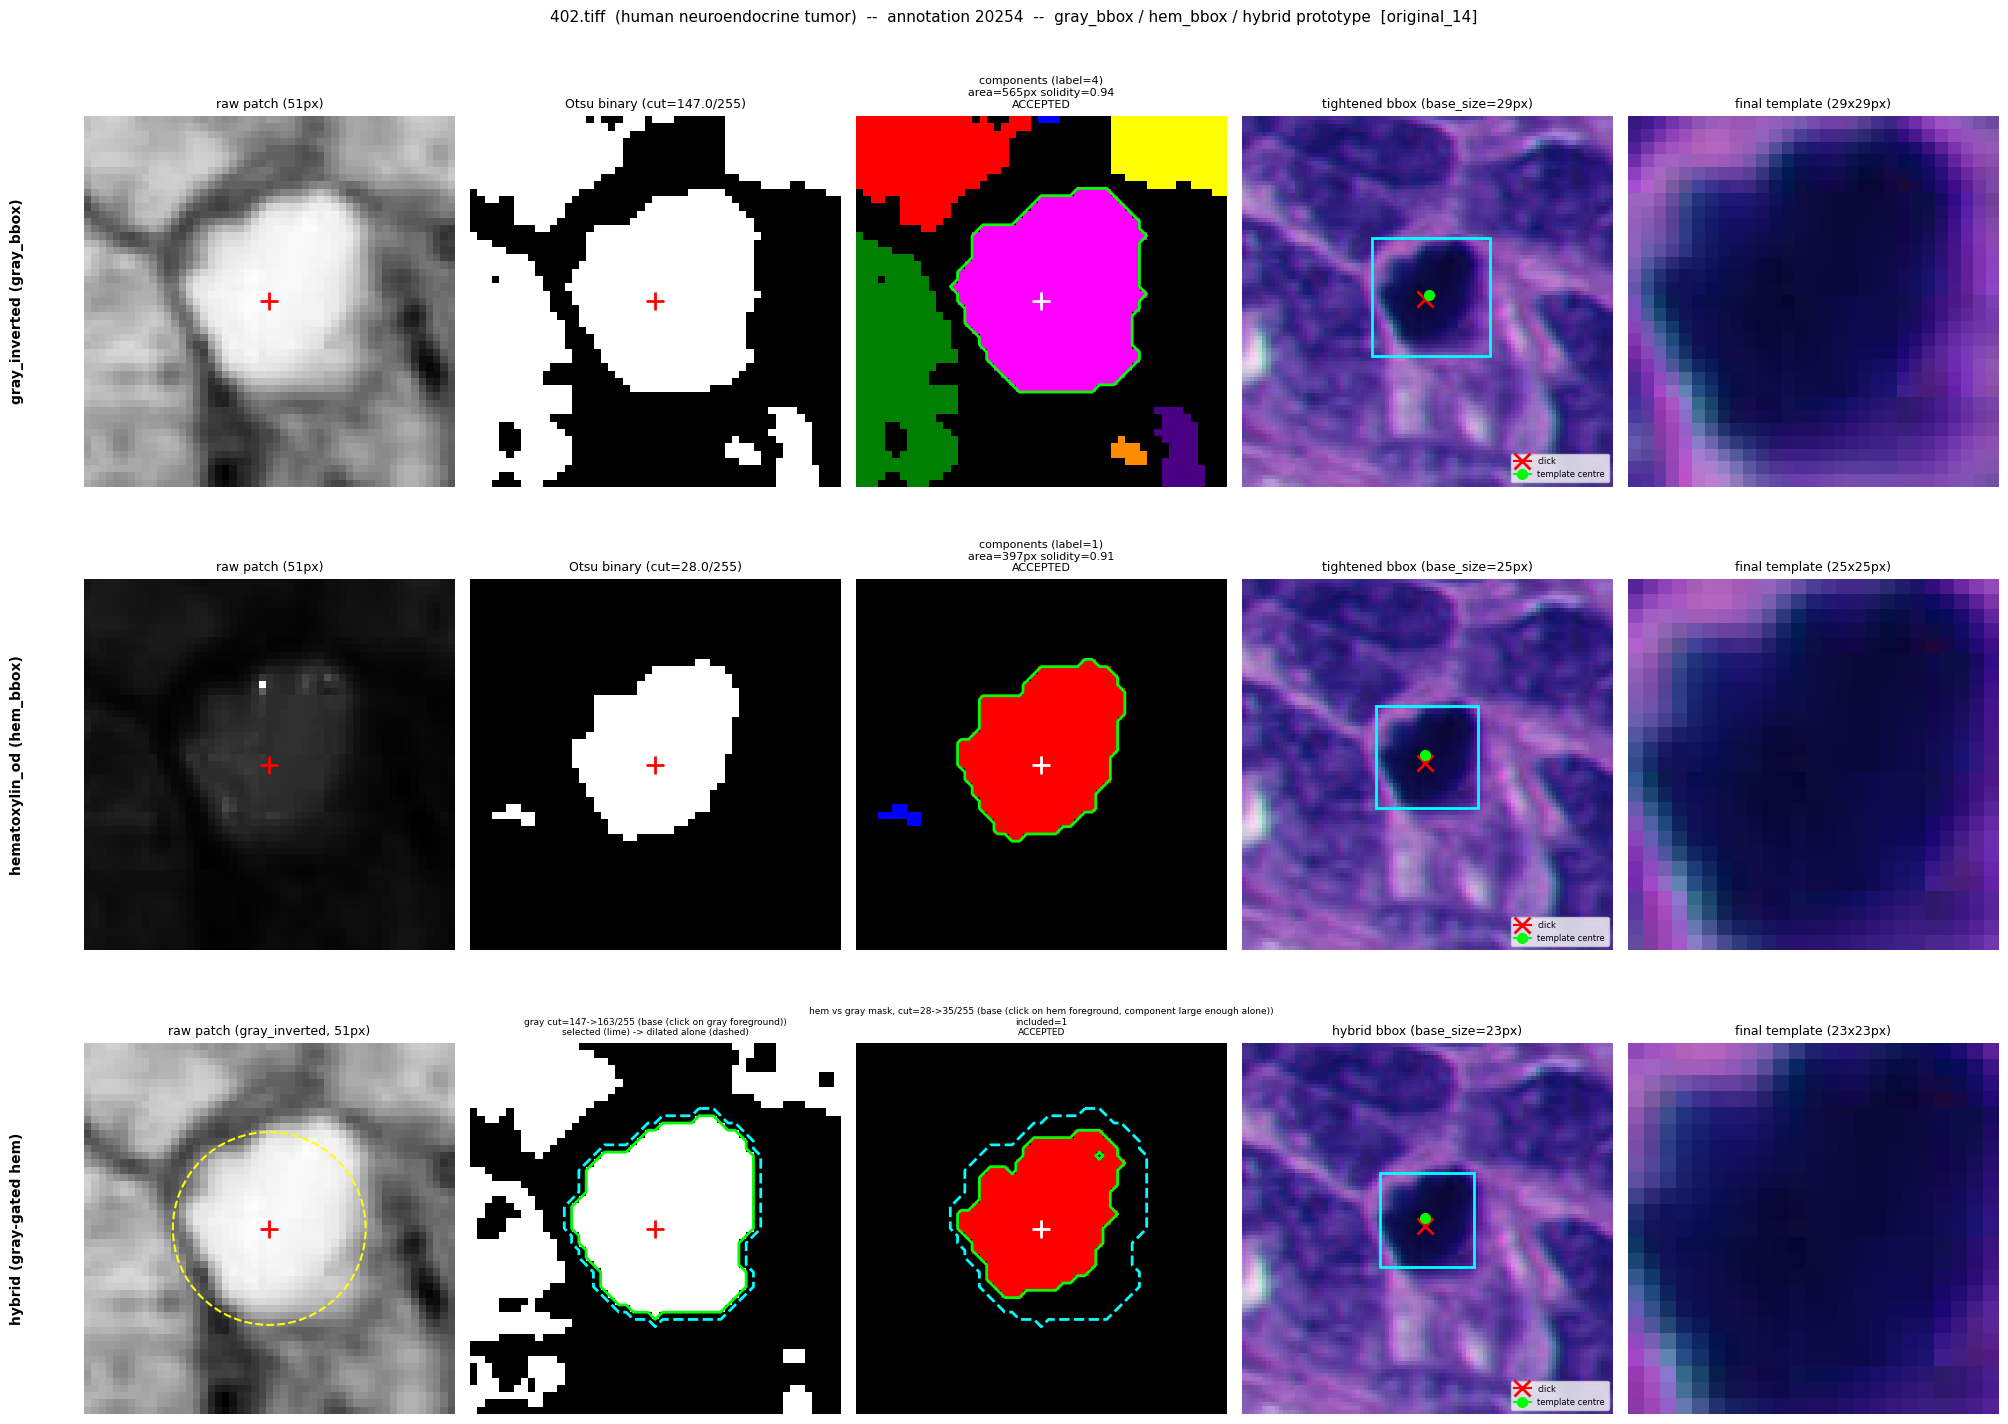

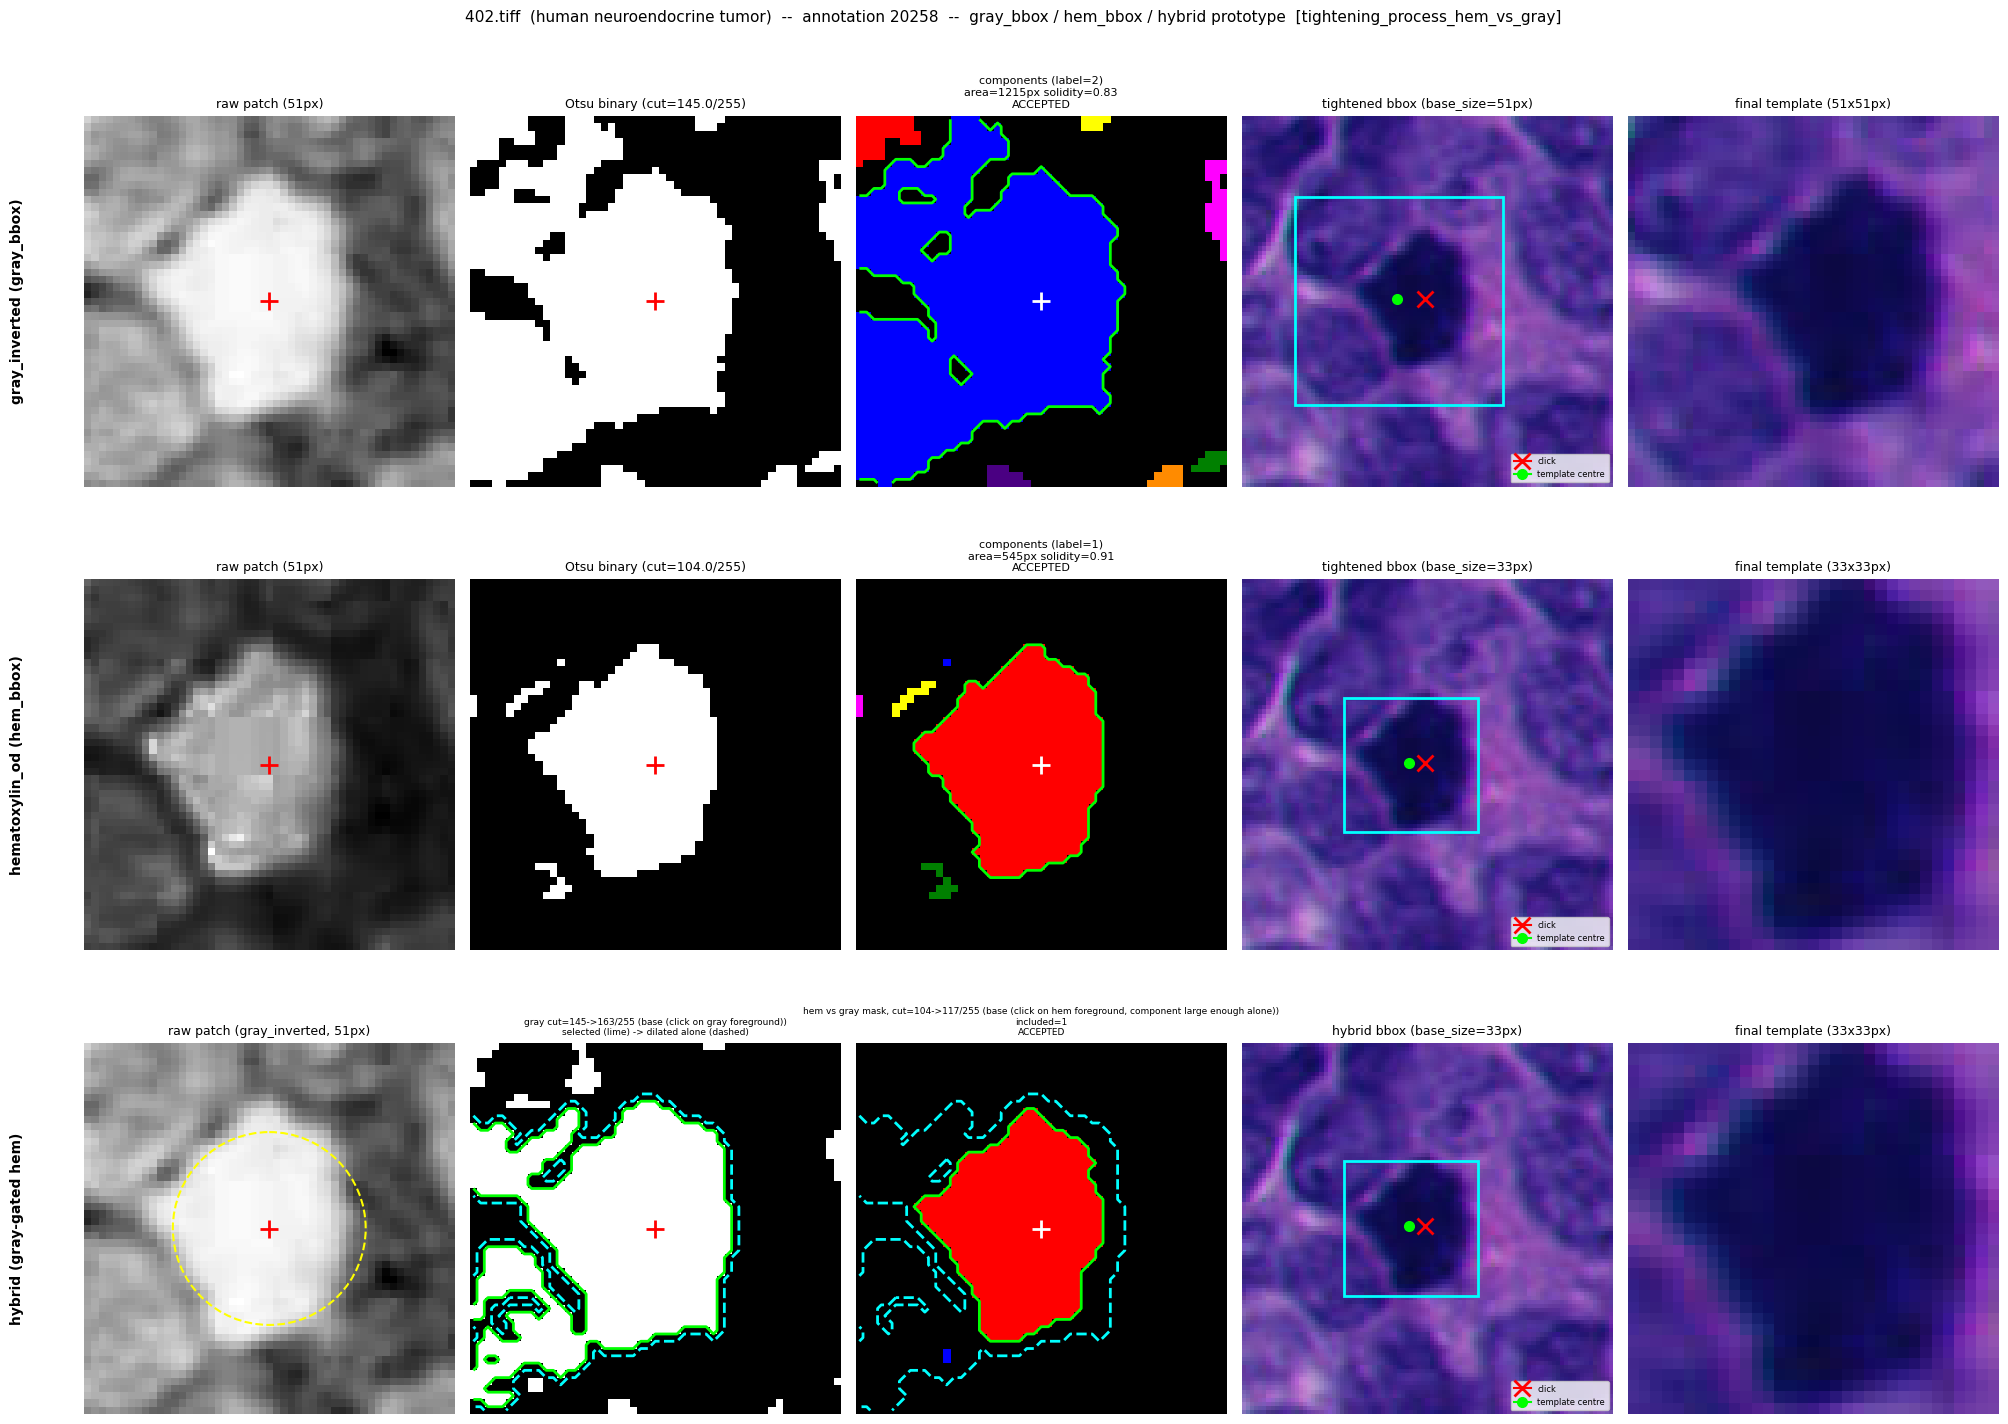

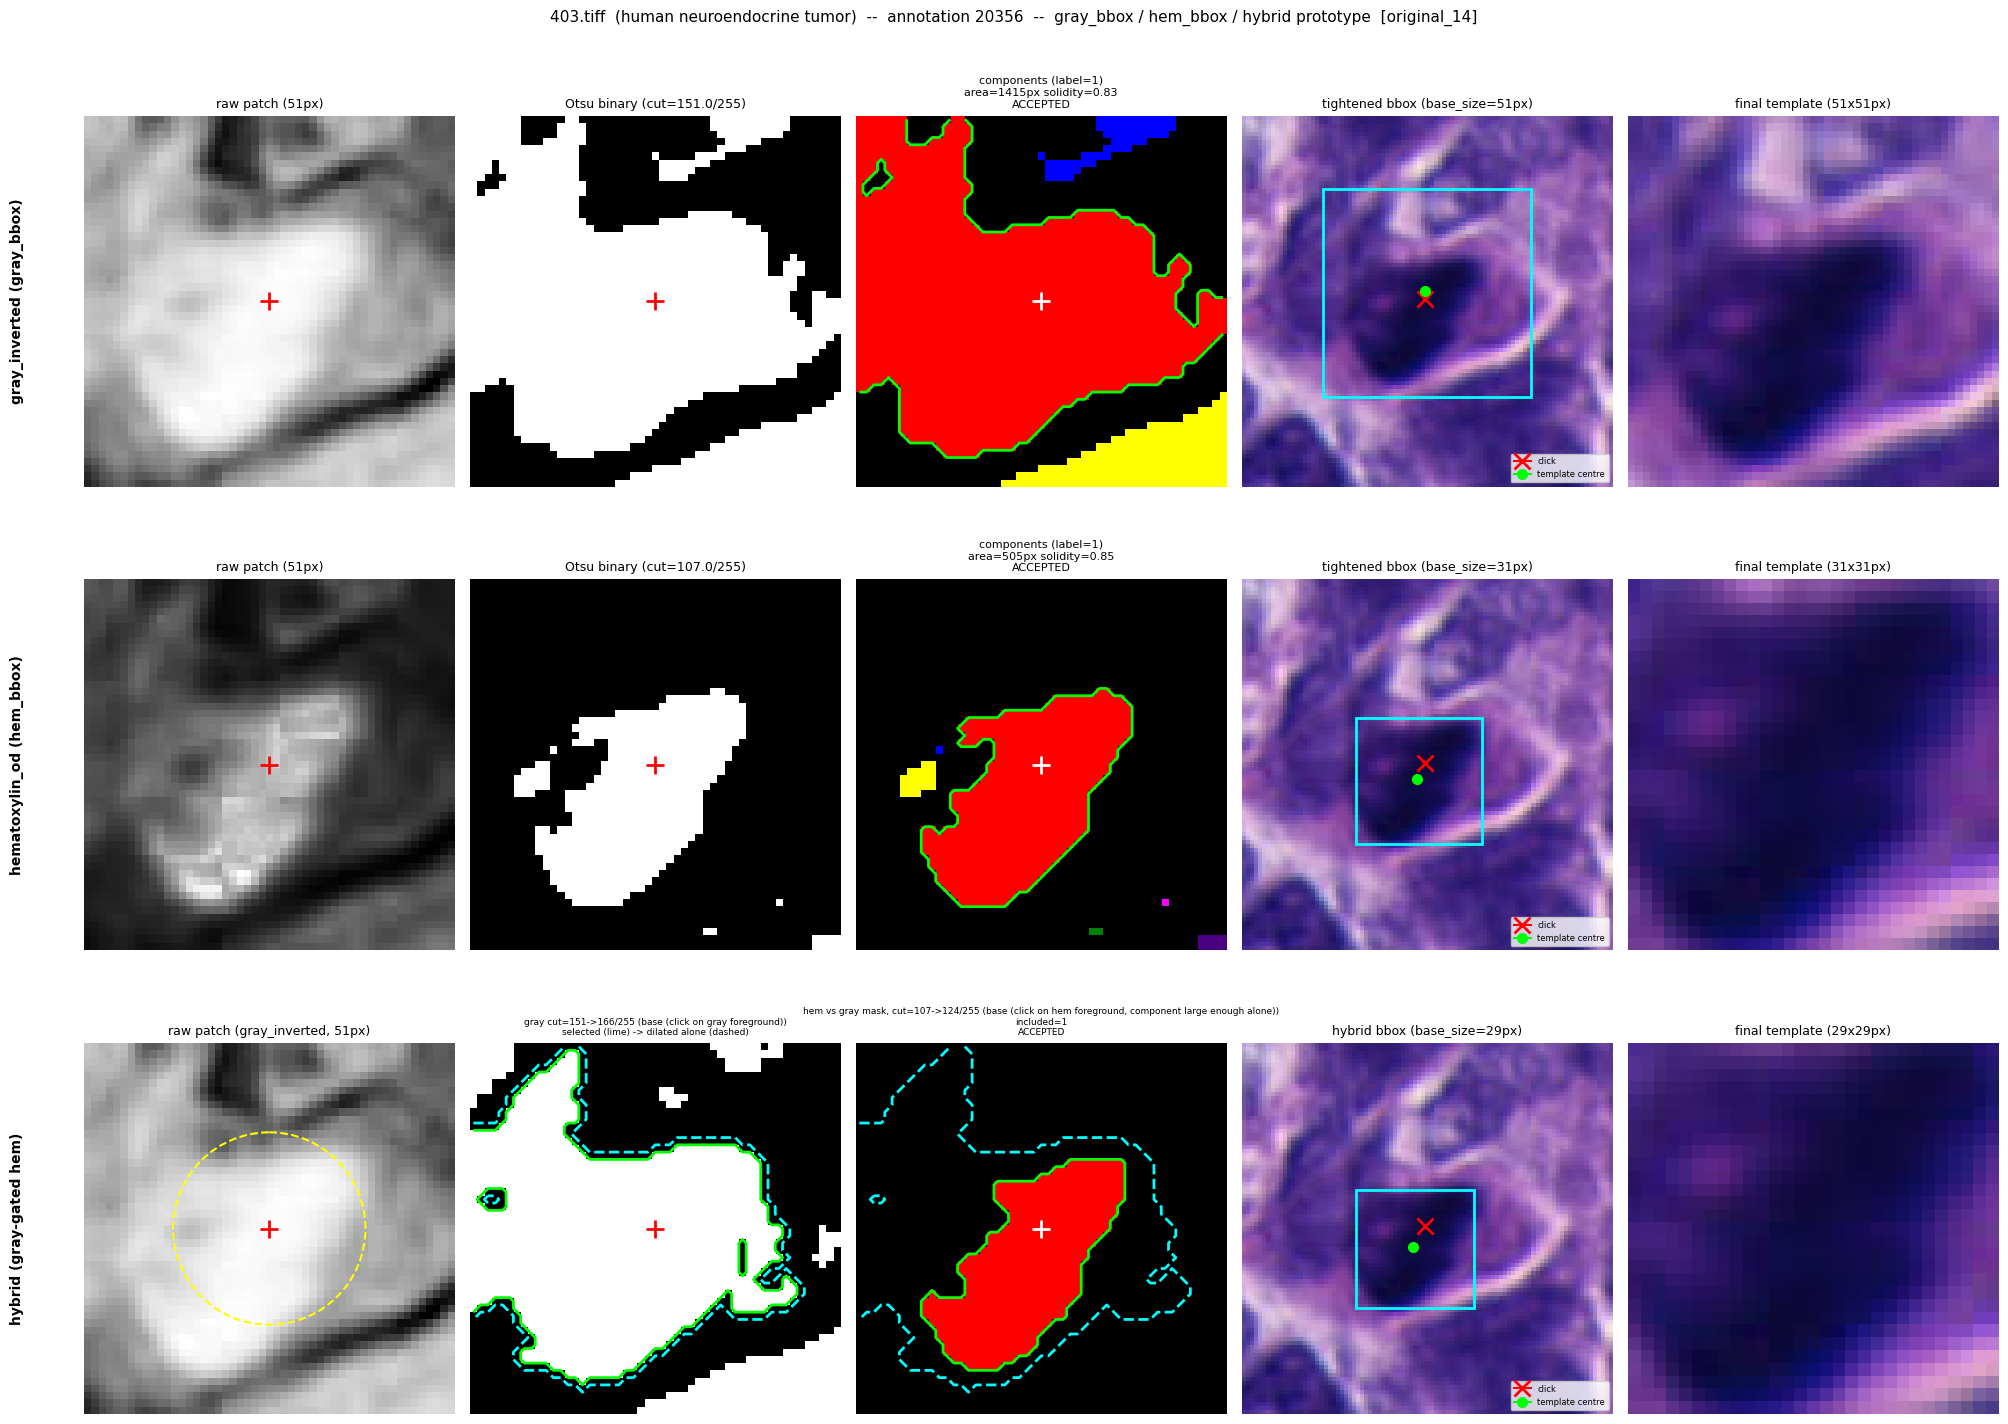

accepted on both channels (gray_bbox/hem_bbox), original 14: 14/14 ROIs (28/28 (ROI, channel) renders)
accepted on both channels, Step 1b additions: 15/20 (not asserted -- refusals expected/normal here, matching tightening_process_hem_vs_gray.ipynb)
[('300.tiff', 14581, 'hematoxylin_od', 'click lands on background at this Otsu cut'), ('245.tiff', 6274, 'hematoxylin_od', 'click lands on background at this Otsu cut'), ('013.tiff', 243, 'gray_inverted', 'click lands on background at this Otsu cut'), ('013.tiff', 243, 'hematoxylin_od', 'click lands on background at this Otsu cut'), ('013.tiff', 254, 'hematoxylin_od', 'click lands on background at this Otsu cut')]

cross-check mismatches against ss.tighten_box_otsu / ss.tightened_template_box / cell 7's own recording: 0

hybrid accepted: 24/24 (not asserted -- see markdown above)


In [6]:
SUMMARY_ROWS = []
SUMMARY_HYBRID_ROWS = []
CROSS_CHECK_MISMATCHES = []
NOT_ACCEPTED = []
NOT_ACCEPTED_EXTRA = []
HYBRID_NOT_ACCEPTED = []

order = sorted(CLICKS, key=lambda c: (c['domain'], c['file_name'], c['ann_id']))

for click in order:
    fn, ann_id, cx, cy, domain = click['file_name'], click['ann_id'], click['cx'], click['cy'], click['domain']
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    mpp = ds.roi_mpp(f'{IMAGES_DIR}/{fn}')
    gray_inv = ch.to_channel(rgb, 'gray_inverted')
    hem_chan = ch.to_channel(rgb, 'hematoxylin_od')

    fig, axes = plt.subplots(3, 5, figsize=(20, 14.4))
    for r, (ch_label, ch_key) in enumerate(CHANNELS.items()):
        chan = ch.to_channel(rgb, ch_key)
        res = explore_tightening(chan, cx, cy)

        if not res['accepted']:
            (NOT_ACCEPTED if click['guaranteed_valid'] else NOT_ACCEPTED_EXTRA).append((fn, ann_id, ch_key, res['reason']))

        # cross-check against the real functions -- not just a visual approximation of them
        official_bbox = ss.tighten_box_otsu(res['patch']) if res['patch'] is not None else None
        if (official_bbox is None) != (not res['accepted']):
            CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'accept/refuse disagrees'))
        elif res['accepted'] and official_bbox != res['bbox']:
            CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'bbox disagrees'))
        if res['patch'] is not None:
            official_tpl = ss.tightened_template_box(chan, cx, cy)
            if (official_tpl is None) != (not res['accepted']):
                CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'tightened_template_box accept/refuse disagrees'))
            elif res['accepted']:
                obs, ocx, ocy = official_tpl
                if obs != res['base_size'] or abs(ocx - res['center_xy'][0]) > 1e-9 or abs(ocy - res['center_xy'][1]) > 1e-9:
                    CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'tightened_template_box result disagrees'))

        # second cross-check, Step 1 clicks only: does this render agree with the seed-draw
        # step's own recording (cell 7, r_by_condition) -- two different code paths, same click
        if click['source'] == 'original_14':
            condition = 'hem_bbox' if ch_key == 'hematoxylin_od' else 'gray_bbox'
            seed_base, seed_cx, seed_cy = seeds[fn]['r_by_condition'][condition]
            if res['accepted'] and (seed_base != res['base_size']
                                    or abs(seed_cx - res['center_xy'][0]) > 1e-9
                                    or abs(seed_cy - res['center_xy'][1]) > 1e-9):
                CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'disagrees with cell 7\'s own draw_joint_valid_seed recording'))

        plot_channel_row(axes[r], ch_label, res, rgb, cx, cy)

        area = int(res['region'].area) if res['region'] is not None else None
        solidity = round(float(res['region'].solidity), 4) if res['region'] is not None else None
        bbox_h = res['bbox'][1] - res['bbox'][0] if res['bbox'] is not None else None
        bbox_w = res['bbox'][3] - res['bbox'][2] if res['bbox'] is not None else None
        right_censored = bool(res['bbox'] is not None and (bbox_h == OTSU_WINDOW or bbox_w == OTSU_WINDOW))
        offset_px = (float(np.hypot(res['center_xy'][0] - cx, res['center_xy'][1] - cy))
                    if res['center_xy'] is not None else None)

        SUMMARY_ROWS.append(dict(source=click['source'], domain=domain, file_name=fn, ann_id=ann_id,
                                 channel=ch_key, condition=('hem_bbox' if ch_key == 'hematoxylin_od' else 'gray_bbox'),
                                 accepted=res['accepted'], base_size=res['base_size'], area=area,
                                 solidity=solidity, bbox_h=bbox_h, bbox_w=bbox_w, right_censored=right_censored,
                                 offset_from_click_px=round(offset_px, 3) if offset_px is not None else None,
                                 reason=None if res['accepted'] else res['reason']))

    hybrid_res = explore_hybrid_tightening(gray_inv, hem_chan, cx, cy, mpp)
    if not hybrid_res['accepted']:
        HYBRID_NOT_ACCEPTED.append((fn, ann_id, hybrid_res['reason']))
    plot_hybrid_row(axes[2], hybrid_res, rgb, cx, cy)

    gray_dilated_area = int(hybrid_res['gray_mask'].sum()) if hybrid_res['gray_mask'] is not None else None
    n_gray_selected = len(hybrid_res['gray_selected_labels'])
    n_hem_candidates = len(hybrid_res['hem_candidates'])
    n_hem_included = len(hybrid_res['included_hem_labels'])
    hy_bbox_h = hybrid_res['bbox'][1] - hybrid_res['bbox'][0] if hybrid_res['bbox'] is not None else None
    hy_bbox_w = hybrid_res['bbox'][3] - hybrid_res['bbox'][2] if hybrid_res['bbox'] is not None else None
    hy_right_censored = bool(hybrid_res['bbox'] is not None and (hy_bbox_h == OTSU_WINDOW or hy_bbox_w == OTSU_WINDOW))
    hy_offset_px = (float(np.hypot(hybrid_res['center_xy'][0] - cx, hybrid_res['center_xy'][1] - cy))
                   if hybrid_res['center_xy'] is not None else None)
    SUMMARY_HYBRID_ROWS.append(dict(source=click['source'], domain=domain, file_name=fn, ann_id=ann_id,
                                    accepted=hybrid_res['accepted'], base_size=hybrid_res['base_size'],
                                    gray_mode=hybrid_res['gray_mode'], n_gray_selected=n_gray_selected,
                                    gray_otsu_thresh=hybrid_res['gray_otsu_thresh'], gray_thresh=hybrid_res['gray_thresh'],
                                    gray_area=hybrid_res['gray_area'], gray_dilated_area=gray_dilated_area,
                                    hem_otsu_thresh=hybrid_res['hem_otsu_thresh'], hem_thresh=hybrid_res['hem_thresh'],
                                    hem_mode=hybrid_res['hem_mode'], n_hem_candidates=n_hem_candidates,
                                    n_hem_included=n_hem_included, union_area=hybrid_res['union_area'],
                                    bbox_h=hy_bbox_h, bbox_w=hy_bbox_w, right_censored=hy_right_censored,
                                    offset_from_click_px=round(hy_offset_px, 3) if hy_offset_px is not None else None,
                                    reason=None if hybrid_res['accepted'] else hybrid_res['reason']))

    fig.suptitle(f'{fn}  ({domain})  --  annotation {ann_id}  --  gray_bbox / hem_bbox / hybrid prototype  [{click["source"]}]',
                fontsize=11, y=1.01)
    fig.tight_layout(h_pad=3.0)
    fig.savefig(f'{OUT_PREFIX}_{fn.replace(".tiff","")}_{ann_id}.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print(f'accepted on both channels (gray_bbox/hem_bbox), original 14: {14 - len(NOT_ACCEPTED)}/14 ROIs '
     f'({28 - len(NOT_ACCEPTED)}/28 (ROI, channel) renders)')
if NOT_ACCEPTED:
    print('NOT ACCEPTED (unexpected for a joint-valid click):', NOT_ACCEPTED)
assert not NOT_ACCEPTED, ('a joint-valid click was refused when re-rendered here -- the '
                          'visualization or the draw diverged from tightened_template_box; see above')

n_extra_clicks = len(order) - 14
print(f'accepted on both channels, Step 1b additions: {n_extra_clicks * 2 - len(NOT_ACCEPTED_EXTRA)}/{n_extra_clicks * 2} '
     f'(not asserted -- refusals expected/normal here, matching tightening_process_hem_vs_gray.ipynb)')
if NOT_ACCEPTED_EXTRA:
    print(NOT_ACCEPTED_EXTRA)

print(f'\ncross-check mismatches against ss.tighten_box_otsu / ss.tightened_template_box / '
     f"cell 7's own recording: {len(CROSS_CHECK_MISMATCHES)}")
if CROSS_CHECK_MISMATCHES:
    print(CROSS_CHECK_MISMATCHES)
assert not CROSS_CHECK_MISMATCHES, 'the visualization diverged from the real tightening functions -- see above'

print(f'\nhybrid accepted: {len(order) - len(HYBRID_NOT_ACCEPTED)}/{len(order)} (not asserted -- see markdown above)')
if HYBRID_NOT_ACCEPTED:
    print('hybrid refusals:', HYBRID_NOT_ACCEPTED)

## Step 3 -- comparison table

One row per click (24), `base_gray` / `base_hem` / `base_hybrid` side by side (`NaN` where that
method refused), plus enough of the hybrid's own intermediates (`gray_mode`/`n_gray_selected`,
`hem_mode`/`n_hem_candidates`/`n_hem_included`, `hem_otsu_thresh` vs `hem_thresh` (the dynamic
bump's actual effect on each window), `gray_area` (the selected region, undilated) vs
`gray_dilated_area` (after its own isolated dilation), `union_area`) to see *why* it landed where
it did.

In [7]:
SUMMARY = pd.DataFrame(SUMMARY_ROWS)
SUMMARY.to_csv(f'{OUT_PREFIX}_summary.csv', index=False)
SUMMARY_HYBRID = pd.DataFrame(SUMMARY_HYBRID_ROWS)
SUMMARY_HYBRID.to_csv(f'{OUT_PREFIX}_hybrid_summary.csv', index=False)
print(f'-> {OUT_PREFIX}_summary.csv  ({len(SUMMARY)} rows = {len(order)} clicks x 2 channels)')
print(f'-> {OUT_PREFIX}_hybrid_summary.csv  ({len(SUMMARY_HYBRID)} rows = {len(order)} clicks)')
print(f"hybrid accepted: {int(SUMMARY_HYBRID['accepted'].sum())}/{len(SUMMARY_HYBRID)}")
if (~SUMMARY_HYBRID['accepted']).any():
    print('hybrid refusals:')
    print(SUMMARY_HYBRID[~SUMMARY_HYBRID['accepted']][['file_name', 'ann_id', 'reason']].to_string(index=False))

hem = SUMMARY[SUMMARY['condition'] == 'hem_bbox'].set_index(['file_name', 'ann_id'])
gray = SUMMARY[SUMMARY['condition'] == 'gray_bbox'].set_index(['file_name', 'ann_id'])
hybrid = SUMMARY_HYBRID.set_index(['file_name', 'ann_id'])

COMPARISON = pd.DataFrame({
    'source': hybrid['source'],
    'domain': hybrid['domain'],
    'base_gray': gray['base_size'],
    'base_hem': hem['base_size'],
    'base_hybrid': hybrid['base_size'],
    'hybrid_accepted': hybrid['accepted'],
    'hybrid_reason': hybrid['reason'],
    'gray_mode': hybrid['gray_mode'],
    'n_gray_selected': hybrid['n_gray_selected'],
    'hem_mode': hybrid['hem_mode'],
    'n_hem_included': hybrid['n_hem_included'],
    'n_hem_candidates': hybrid['n_hem_candidates'],
    'hem_otsu_thresh': hybrid['hem_otsu_thresh'],
    'hem_thresh': hybrid['hem_thresh'],
    'gray_otsu_thresh': hybrid['gray_otsu_thresh'],
    'gray_thresh': hybrid['gray_thresh'],
    'gray_area': hybrid['gray_area'],
    'gray_dilated_area': hybrid['gray_dilated_area'],
    'area_gray': gray['area'],
    'area_hem': hem['area'],
    'union_area': hybrid['union_area'],
}).sort_values('base_hybrid')
COMPARISON.to_csv(f'{OUT_PREFIX}_comparison.csv')
print(f'-> {OUT_PREFIX}_comparison.csv  ({len(COMPARISON)} rows = {len(order)} clicks)')
COMPARISON

-> seedrefine14hybrid_summary.csv  (48 rows = 24 clicks x 2 channels)
-> seedrefine14hybrid_hybrid_summary.csv  (24 rows = 24 clicks)
hybrid accepted: 24/24
-> seedrefine14hybrid_comparison.csv  (24 rows = 24 clicks)


,,source,domain,base_gray,base_hem,base_hybrid,hybrid_accepted,hybrid_reason,gray_mode,n_gray_selected,hem_mode,n_hem_included,n_hem_candidates,hem_otsu_thresh,hem_thresh,gray_otsu_thresh,gray_thresh,gray_area,gray_dilated_area,area_gray,area_hem,union_area
file_name,ann_id,,,,,,,,,,,,,,,,,,,,,
245.tiff,6317,original_14,canine lymphosarcoma,51.0,23.0,21,True,None,base (click on gray foreground),1,"base (click on hem foreground, component large...",1,1,84.0,101.825778,156.0,167.616582,1088,1314,1418.0,296.0,216
300.tiff,14499,original_14,canine cutaneous mast cell tumor,49.0,25.0,23,True,None,base (click on gray foreground),1,"base (click on hem foreground, component large...",1,1,92.0,113.812462,113.0,133.619733,424,518,1069.0,244.0,215
402.tiff,20254,original_14,human neuroendocrine tumor,29.0,25.0,23,True,None,base (click on gray foreground),1,"base (click on hem foreground, component large...",1,1,28.0,34.540495,147.0,162.818760,530,610,565.0,397.0,351
094.tiff,2512,original_14,human breast cancer,25.0,23.0,23,True,None,base (click on gray foreground),1,"base (click on hem foreground, component large...",1,1,80.0,99.763531,126.0,143.199106,365,437,399.0,318.0,277
233.tiff,5761,original_14,canine lung cancer,25.0,23.0,23,True,None,base (click on gray foreground),1,"base (click on hem foreground, component large...",1,1,110.0,124.906697,160.0,174.028898,411,484,429.0,376.0,354
246.tiff,6548,original_14,canine lymphosarcoma,41.0,27.0,25,True,None,base (click on gray foreground),1,"base (click on hem foreground, component large...",1,1,87.0,106.525122,155.0,168.597803,352,433,495.0,265.0,224
548.tiff,25804,original_14,human melanoma,29.0,27.0,27,True,None,base (click on gray foreground),1,"base (click on hem foreground, component large...",1,1,91.0,107.853443,166.0,178.938962,555,638,589.0,497.0,449
529.tiff,24937,tightening_process_hem_vs_gray,human melanoma,41.0,33.0,29,True,None,base (click on gray foreground),1,"base (click on hem foreground, component large...",1,1,92.0,114.717148,132.0,149.738726,418,515,524.0,337.0,219
013.tiff,254,tightening_process_hem_vs_gray,human breast cancer,31.0,NaN,29,True,None,base (click on gray foreground),1,"fallback (click on hem background, 3.0um = 13....",1,1,91.0,108.980397,139.0,153.705697,544,641,582.0,NaN,455


## Closing notes

*(Placeholder -- rewritten below with the actual run's numbers once this notebook is executed.)*

**Caveats, stated plainly, regardless of what the run shows:**
- `DILATE_KERNEL`/`DILATE_ITERATIONS`, `CLICK_RADIUS_UM`, `HEM_MIN_BASE_SIZE_PX`, and `DYNAMIC_K`
  are all first guesses, not tuned -- treat every number below as "what this particular setting
  does," not as a claim about the idea's ceiling.
- The dynamic threshold (now on both channels) is untested at this sample size for the *opposite*
  failure mode -- over-trimming a real, single, undivided nucleus into something smaller than it
  should be. Worth checking whether any accepted `base_hybrid` looks implausibly small relative to
  `base_hem`, and whether `gray_area` shrinking ever changes which hem components pass containment
  (it didn't on the two clicks checked directly before this run, but wasn't tested more broadly
  until now).
- This prototype has **no analogue of `tighten_box_otsu`'s solidity gate** on a multi-component
  fallback union -- a scattered set of small, barely-overlapping hem fragments can all pass the
  full-containment test and get unioned together in a way a single low-solidity component would
  be refused elsewhere.
- Nothing here has been run through the actual pipeline (precision@K, NMS, matching) -- this is
  purely "what does the geometry look like," the same scope `production_seed_tightening_detail_14roi.ipynb`
  has for the two existing methods.